In [2]:
%pip install xlrd openpyxl lxml

--- Logging error ---
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pip/_internal/utils/logging.py", line 177, in emit
    self.console.print(renderable, overflow="ignore", crop=False, style=style)
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pip/_vendor/rich/console.py", line 1673, in print
    extend(render(renderable, render_options))
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pip/_vendor/rich/console.py", line 1305, in render
    for render_output in iter_render:
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pip/_internal/utils/logging.py", line 134, in __rich_console__
    for line in lines:
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pip/_vendor/rich/segment.py", line 249, in split_lines
    for segment in segments:
  File "/Library/

# South Africa Cement Data Exploration

This notebook loads and explores the South Africa Producer Price Index and Construction Materials Price Indices datasets.

In [3]:
import pandas as pd
import os

# Define file paths relative to the notebook location
file_path_2000_2012 = '2000-2012/Producer Price Index 2000.xls'
file_path_2006_2025 = '2006_2025/Construction Materials Price Indices 2006 to 2025.xlsx'

# Load the datasets
print(f"Loading files...")

# Load 2000-2012 data
try:
    # Explicitly verify file existence
    if not os.path.exists(file_path_2000_2012):
        print(f"File not found: {file_path_2000_2012}")
        print(f"Current working directory: {os.getcwd()}")
        df_2000_2012 = pd.DataFrame()
    else:
        # Try different methods to load the file
        try:
            # First try as standard Excel
            df_2000_2012 = pd.read_excel(file_path_2000_2012, engine='xlrd')
            print(f"Successfully loaded {file_path_2000_2012} via xlrd")
        except Exception as e_xls:
            print(f"Could not read as Excel (xlrd): {e_xls}")
            print("Attempting to read as HTML (legacy Excel export format)...")
            try:
                dfs = pd.read_html(file_path_2000_2012)
                if dfs:
                    df_2000_2012 = dfs[0] # Take the first table
                    print(f"Successfully loaded {file_path_2000_2012} as HTML table")
                else:
                    print("No tables found in HTML file")
                    df_2000_2012 = pd.DataFrame()
            except Exception as e_html:
                print(f"Could not read as HTML: {e_html}")
                df_2000_2012 = pd.DataFrame()
                
        print(f"Shape: {df_2000_2012.shape}")
except Exception as e:
    print(f"Error loading {file_path_2000_2012}: {e}")
    df_2000_2012 = pd.DataFrame()

# Load 2006-2025 data
try:
    if not os.path.exists(file_path_2006_2025):
        print(f"File not found: {file_path_2006_2025}")
        df_2006_2025 = pd.DataFrame()
    else:
        # Use openpyxl for .xlsx files
        df_2006_2025 = pd.read_excel(file_path_2006_2025, engine='openpyxl')
        print(f"Successfully loaded: {file_path_2006_2025}")
        print(f"Shape: {df_2006_2025.shape}")
except Exception as e:
    print(f"Error loading {file_path_2006_2025}: {e}")
    df_2006_2025 = pd.DataFrame()

# Show columns in each dataset
print("\n" + "="*50)
print("COLUMNS IN 2000-2012 DATASET")
print("="*50)
if not df_2000_2012.empty:
    for col in df_2000_2012.columns:
        print(f"- {col}")
else:
    print("Dataset is empty.")

print("\n" + "="*50)
print("COLUMNS IN 2006-2025 DATASET")
print("="*50)
if not df_2006_2025.empty:
    # Print first few if many
    cols = df_2006_2025.columns.tolist()
    print(f"Total columns: {len(cols)}")
    print(cols)
else:
    print("Dataset is empty.")

# Analyze common columns
common_cols = set(df_2000_2012.columns).intersection(set(df_2006_2025.columns))

print("\n" + "="*50)
print("COMMON COLUMNS ANALYSIS")
print("="*50)
print(f"Number of columns in dataset 1: {len(df_2000_2012.columns)}")
print(f"Number of columns in dataset 2: {len(df_2006_2025.columns)}")
print(f"Number of common columns: {len(common_cols)}")

if len(common_cols) > 0:
    print("\nCommon columns list:")
    for col in sorted(list(common_cols)):
        print(f"- {col}")
else:
    print("\nNo common column names found.")

Loading files...
Could not read as Excel (xlrd): Unsupported format, or corrupt file: Expected BOF record; found b'<!DOCTYP'
Attempting to read as HTML (legacy Excel export format)...
Successfully loaded 2000-2012/Producer Price Index 2000.xls as HTML table
Shape: (650, 164)
Successfully loaded 2000-2012/Producer Price Index 2000.xls as HTML table
Shape: (650, 164)
Successfully loaded: 2006_2025/Construction Materials Price Indices 2006 to 2025.xlsx
Shape: (123, 243)

COLUMNS IN 2000-2012 DATASET
- H01
- H02
- H03
- H04
- H05
- H17
- H18
- H25
- MO012000
- MO022000
- MO032000
- MO042000
- MO052000
- MO062000
- MO072000
- MO082000
- MO092000
- MO102000
- MO112000
- MO122000
- MO012001
- MO022001
- MO032001
- MO042001
- MO052001
- MO062001
- MO072001
- MO082001
- MO092001
- MO102001
- MO112001
- MO122001
- MO012002
- MO022002
- MO032002
- MO042002
- MO052002
- MO062002
- MO072002
- MO082002
- MO092002
- MO102002
- MO112002
- MO122002
- MO012003
- MO022003
- MO032003
- MO042003
- MO052003

In [4]:
target_col = 'H05'

print(f"Checking for column '{target_col}' in datasets...\n")

# Check 2000-2012 dataset
if 'df_2000_2012' in locals() and not df_2000_2012.empty and target_col in df_2000_2012.columns:
    unique_vals = df_2000_2012[target_col].unique()
    print(f"Unique values in 2000-2012 dataset ('{target_col}'):")
    print(unique_vals)
    print(f"Total unique values: {len(unique_vals)}")
elif 'df_2000_2012' in locals() and not df_2000_2012.empty:
    print(f"Column '{target_col}' not found in 2000-2012 dataset.")
else:
    print("2000-2012 dataset is empty or not loaded.")

print("\n" + "-"*30 + "\n")

# Check 2006-2025 dataset
if 'df_2006_2025' in locals() and not df_2006_2025.empty and target_col in df_2006_2025.columns:
    unique_vals = df_2006_2025[target_col].unique()
    print(f"Unique values in 2006-2025 dataset ('{target_col}'):")
    print(unique_vals)
    print(f"Total unique values: {len(unique_vals)}")
elif 'df_2006_2025' in locals() and not df_2006_2025.empty:
    print(f"Column '{target_col}' not found in 2006-2025 dataset.")
else:
     print("2006-2025 dataset is empty or not loaded.")

Checking for column 'H05' in datasets...

Unique values in 2000-2012 dataset ('H05'):
['All groups' 'Agriculture, forestry, fishing and mining' 'Agriculture'
 'Agriculture - Food' 'Agriculture - Food: Grain'
 'Agriculture - Food: Vegetables and dried beans' 'Fruits and nuts'
 'Agriculture - Food: Oil seeds' 'Agriculture - Food: Sugar cane'
 'Agriculture - Food: Other' 'Live animals and animal products'
 'Live animals' 'Milk' 'Eggs' 'Other raw animal products'
 'Agriculture - Other agriculture' 'Forestry' 'Fishing'
 'Mining and quarrying' 'Mining and quarrying: Coal'
 'Crude petroleum and natural gas' 'Mining and quarrying: Metal ores'
 'Mining and quarrying: Other minerals (as from 6/' 'Manufacturing' 'Food'
 'Meat and meat products' 'Prepared and preserved fish'
 'Food: Fruit and vegetable products' 'Food: Fats and oils'
 'Dairy products' 'Grain mill products and bakery products' 'Food: Sugar'
 'Food: Coffee and tea (as from 6/95)' 'Food: Other (as from 6/95)'
 'Beverages' 'Beverages:

In [5]:
target_col = 'H05'

# Calculate intersection
if 'df_2000_2012' in locals() and not df_2000_2012.empty and target_col in df_2000_2012.columns and \
   'df_2006_2025' in locals() and not df_2006_2025.empty and target_col in df_2006_2025.columns:
    
    unique_1 = set(df_2000_2012[target_col].unique())
    unique_2 = set(df_2006_2025[target_col].unique())
    
    common_elements = unique_1.intersection(unique_2)
    
    print(f"Common elements in column '{target_col}':")
    print("-" * 30)
    print(f"Count: {len(common_elements)}")
    
    if len(common_elements) > 0:
        print("\nValues:")
        for val in sorted(list(common_elements)):
            print(f"- {val}")
    else:
        print("\nNo common elements found.")
else:
    print(f"Cannot compare: Column '{target_col}' missing in one or both datasets.")

Common elements in column 'H05':
------------------------------
Count: 9

Values:
- Civil engineering
- Concrete pipes
- Drainage
- Electrical engineering
- Ironmongery
- Mechanical engineering
- Paints
- Plumbing
- Sand


In [6]:
target_col = 'H05'
keyword = 'cement'

print(f"Searching for values containing '{keyword}' in column '{target_col}'...\n")

# Function to filter and print
def print_keyword_matches(df, dataset_name, col, word):
    if col in df.columns:
        # Get unique values, ensure they are strings, compare lower case
        unique_vals = [str(x) for x in df[col].unique() if pd.notna(x)]
        matches = [x for x in unique_vals if word.lower() in x.lower()]
        
        print(f"Matches in {dataset_name} ({len(matches)}):")
        print("-" * 30)
        for match in sorted(matches):
            print(f"- {match}")
        print()
    else:
        print(f"Column '{col}' not found in {dataset_name}\n")

# Check 2000-2012 dataset
if 'df_2000_2012' in locals() and not df_2000_2012.empty:
    print_keyword_matches(df_2000_2012, "2000-2012 Dataset", target_col, keyword)

# Check 2006-2025 dataset
if 'df_2006_2025' in locals() and not df_2006_2025.empty:
    print_keyword_matches(df_2006_2025, "2006-2025 Dataset", target_col, keyword)

Searching for values containing 'cement' in column 'H05'...

Matches in 2000-2012 Dataset (4):
------------------------------
- Cement (Retail)
- Cement building blocks
- Fibre cement roof sheets
- Ordinary and extended cement

Matches in 2006-2025 Dataset (4):
------------------------------
- Cement
- Prefabricated cement and concrete components
- Prefabricated concrete and cement
- Reinforcement



In [7]:
target_val_1 = "Cement (Retail)"
target_val_2 = "Cement"
target_col = 'H05'

print(f"Comparing columns for:\n1. '{target_val_1}' in 2000-2012 dataset\n2. '{target_val_2}' in 2006-2025 dataset\n")

non_null_cols_1 = set()
non_null_cols_2 = set()

# Process Dataset 1
if 'df_2000_2012' in locals() and not df_2000_2012.empty and target_col in df_2000_2012.columns:
    # Filter for the row
    row_1 = df_2000_2012[df_2000_2012[target_col] == target_val_1]
    if not row_1.empty:
        # Get columns that are not null in this row (taking first match if duplicates)
        # We look at the first matching row found
        first_row_1 = row_1.iloc[0]
        non_null_cols_1 = set(first_row_1[first_row_1.notna()].index)
        print(f"Found '{target_val_1}' in Dataset 1. Non-null columns: {len(non_null_cols_1)}")
    else:
        print(f"'{target_val_1}' not found in Dataset 1.")

# Process Dataset 2
if 'df_2006_2025' in locals() and not df_2006_2025.empty and target_col in df_2006_2025.columns:
    # Filter for the row
    row_2 = df_2006_2025[df_2006_2025[target_col] == target_val_2]
    if not row_2.empty:
        # Get columns that are not null
        first_row_2 = row_2.iloc[0]
        non_null_cols_2 = set(first_row_2[first_row_2.notna()].index)
        print(f"Found '{target_val_2}' in Dataset 2. Non-null columns: {len(non_null_cols_2)}")
    else:
        print(f"'{target_val_2}' not found in Dataset 2.")

# Compare
print("-" * 30)
if non_null_cols_1 and non_null_cols_2:
    common_non_null = non_null_cols_1.intersection(non_null_cols_2)
    print(f"Common non-null columns count: {len(common_non_null)}")
    
    if len(common_non_null) > 0:
        print("\nCommon non-null columns:")
        # Sort for better readability, handle potential mixed types if any
        sorted_cols = sorted([str(c) for c in common_non_null])
        
        # Print comfortably
        print(", ".join(sorted_cols))
    else:
        print("\nNo common non-null columns found.")
else:
    print("Could not compare (one or both rows missing/empty).")

Comparing columns for:
1. 'Cement (Retail)' in 2000-2012 dataset
2. 'Cement' in 2006-2025 dataset

Found 'Cement (Retail)' in Dataset 1. Non-null columns: 164
Found 'Cement' in Dataset 2. Non-null columns: 139
------------------------------
Common non-null columns count: 8

Common non-null columns:
H01, H02, H03, H04, H05, H17, H18, H25


In [8]:
import re

target_val_1 = "Cement (Retail)"
target_val_2 = "Civil engineering material - total"
target_col = 'H05'

def get_time_series_cols(df, target_col, target_val):
    if df.empty or target_col not in df.columns:
        return []
    
    # Get the row
    row = df[df[target_col] == target_val]
    if row.empty:
        return []
    
    # Get first match
    data_row = row.iloc[0]
    
    # Get all non-null index
    non_null_cols = data_row[data_row.notna()].index.tolist()
    
    # Filter out 'H' columns (assuming H followed by number)
    ts_cols = [c for c in non_null_cols if not (str(c).startswith('H') and c[1].isdigit())]
    
    return ts_cols

# Get columns
ts_cols_1 = get_time_series_cols(df_2000_2012, target_col, target_val_1)
ts_cols_2 = get_time_series_cols(df_2006_2025, target_col, target_val_2)

print(f"Time Series Columns with Data for '{target_val_1}' (2000-2012 Dataset):")
print("-" * 60)
if ts_cols_1:
    print(f"Total Count: {len(ts_cols_1)}")
    # Print in chunks for readability
    print(ts_cols_1)
else:
    print("No time series columns found with data.")

print("\n" + "=" * 60 + "\n")

print(f"Time Series Columns with Data for '{target_val_2}' (2006-2025 Dataset):")
print("-" * 60)
if ts_cols_2:
    print(f"Total Count: {len(ts_cols_2)}")
    print(ts_cols_2)
else:
    print("No time series columns found with data.")

Time Series Columns with Data for 'Cement (Retail)' (2000-2012 Dataset):
------------------------------------------------------------
Total Count: 156
['MO012000', 'MO022000', 'MO032000', 'MO042000', 'MO052000', 'MO062000', 'MO072000', 'MO082000', 'MO092000', 'MO102000', 'MO112000', 'MO122000', 'MO012001', 'MO022001', 'MO032001', 'MO042001', 'MO052001', 'MO062001', 'MO072001', 'MO082001', 'MO092001', 'MO102001', 'MO112001', 'MO122001', 'MO012002', 'MO022002', 'MO032002', 'MO042002', 'MO052002', 'MO062002', 'MO072002', 'MO082002', 'MO092002', 'MO102002', 'MO112002', 'MO122002', 'MO012003', 'MO022003', 'MO032003', 'MO042003', 'MO052003', 'MO062003', 'MO072003', 'MO082003', 'MO092003', 'MO102003', 'MO112003', 'MO122003', 'MO012004', 'MO022004', 'MO032004', 'MO042004', 'MO052004', 'MO062004', 'MO072004', 'MO082004', 'MO092004', 'MO102004', 'MO112004', 'MO122004', 'MO012005', 'MO022005', 'MO032005', 'MO042005', 'MO052005', 'MO062005', 'MO072005', 'MO082005', 'MO092005', 'MO102005', 'MO11200

In [9]:
from itertools import product

# Define the lists of items containing "cement"
items_1 = [
    "Cement (Retail)",
    "Cement building blocks",
    "Fibre cement roof sheets",
    "Ordinary and extended cement",
    "Precast concrete"
    ]

items_2 = [
    "Cement",
    "Prefabricated cement and concrete components",
    "Prefabricated concrete and cement",
    "Civil engineering material - total"
]

target_col = 'H05'

# Helper to parse dates (Format MOmmYYYY - applies to BOTH datasets now)
def parse_date(col_name):
    s = str(col_name).strip()
    if s.startswith("MO") and len(s) == 8 and s[2:].isdigit():
        month = int(s[2:4])
        year = int(s[4:])
        return (year, month)
    return None

def get_valid_dates(df, item_name, target_col, parser_func):
    if df.empty or target_col not in df.columns:
        return set()
        
    row = df[df[target_col] == item_name]
    if row.empty:
        return set()
        
    data = row.iloc[0]
    non_null_cols = data[data.notna()].index
    
    valid_dates = set()
    for c in non_null_cols:
        dt = parser_func(c)
        if dt:
            valid_dates.add(dt)
    return valid_dates

# Print Comparison Table
print(f"{'Dataset 1 Item':<30} | {'Dataset 2 Item':<40} | {'Overlap':<8} | {'Range'}")
print("-" * 105)

for item1, item2 in product(items_1, items_2):
    dates1 = get_valid_dates(df_2000_2012, item1, target_col, parse_date)
    dates2 = get_valid_dates(df_2006_2025, item2, target_col, parse_date)
    
    overlap = dates1.intersection(dates2)
    count = len(overlap)
    
    period = "-"
    if count > 0:
        sorted_dates = sorted(list(overlap))
        start = sorted_dates[0]
        end = sorted_dates[-1]
        period = f"{start[1]:02d}/{start[0]} - {end[1]:02d}/{end[0]}"
    
    print(f"{item1[:30]:<30} | {item2[:40]:<40} | {count:<8} | {period}")

Dataset 1 Item                 | Dataset 2 Item                           | Overlap  | Range
---------------------------------------------------------------------------------------------------------
Cement (Retail)                | Cement                                   | 0        | -
Cement (Retail)                | Prefabricated cement and concrete compon | 0        | -
Cement (Retail)                | Prefabricated concrete and cement        | 0        | -
Cement (Retail)                | Civil engineering material - total       | 0        | -
Cement building blocks         | Cement                                   | 0        | -
Cement building blocks         | Prefabricated cement and concrete compon | 0        | -
Cement building blocks         | Prefabricated concrete and cement        | 0        | -
Cement building blocks         | Civil engineering material - total       | 0        | -
Fibre cement roof sheets       | Cement                                   | 0        | -


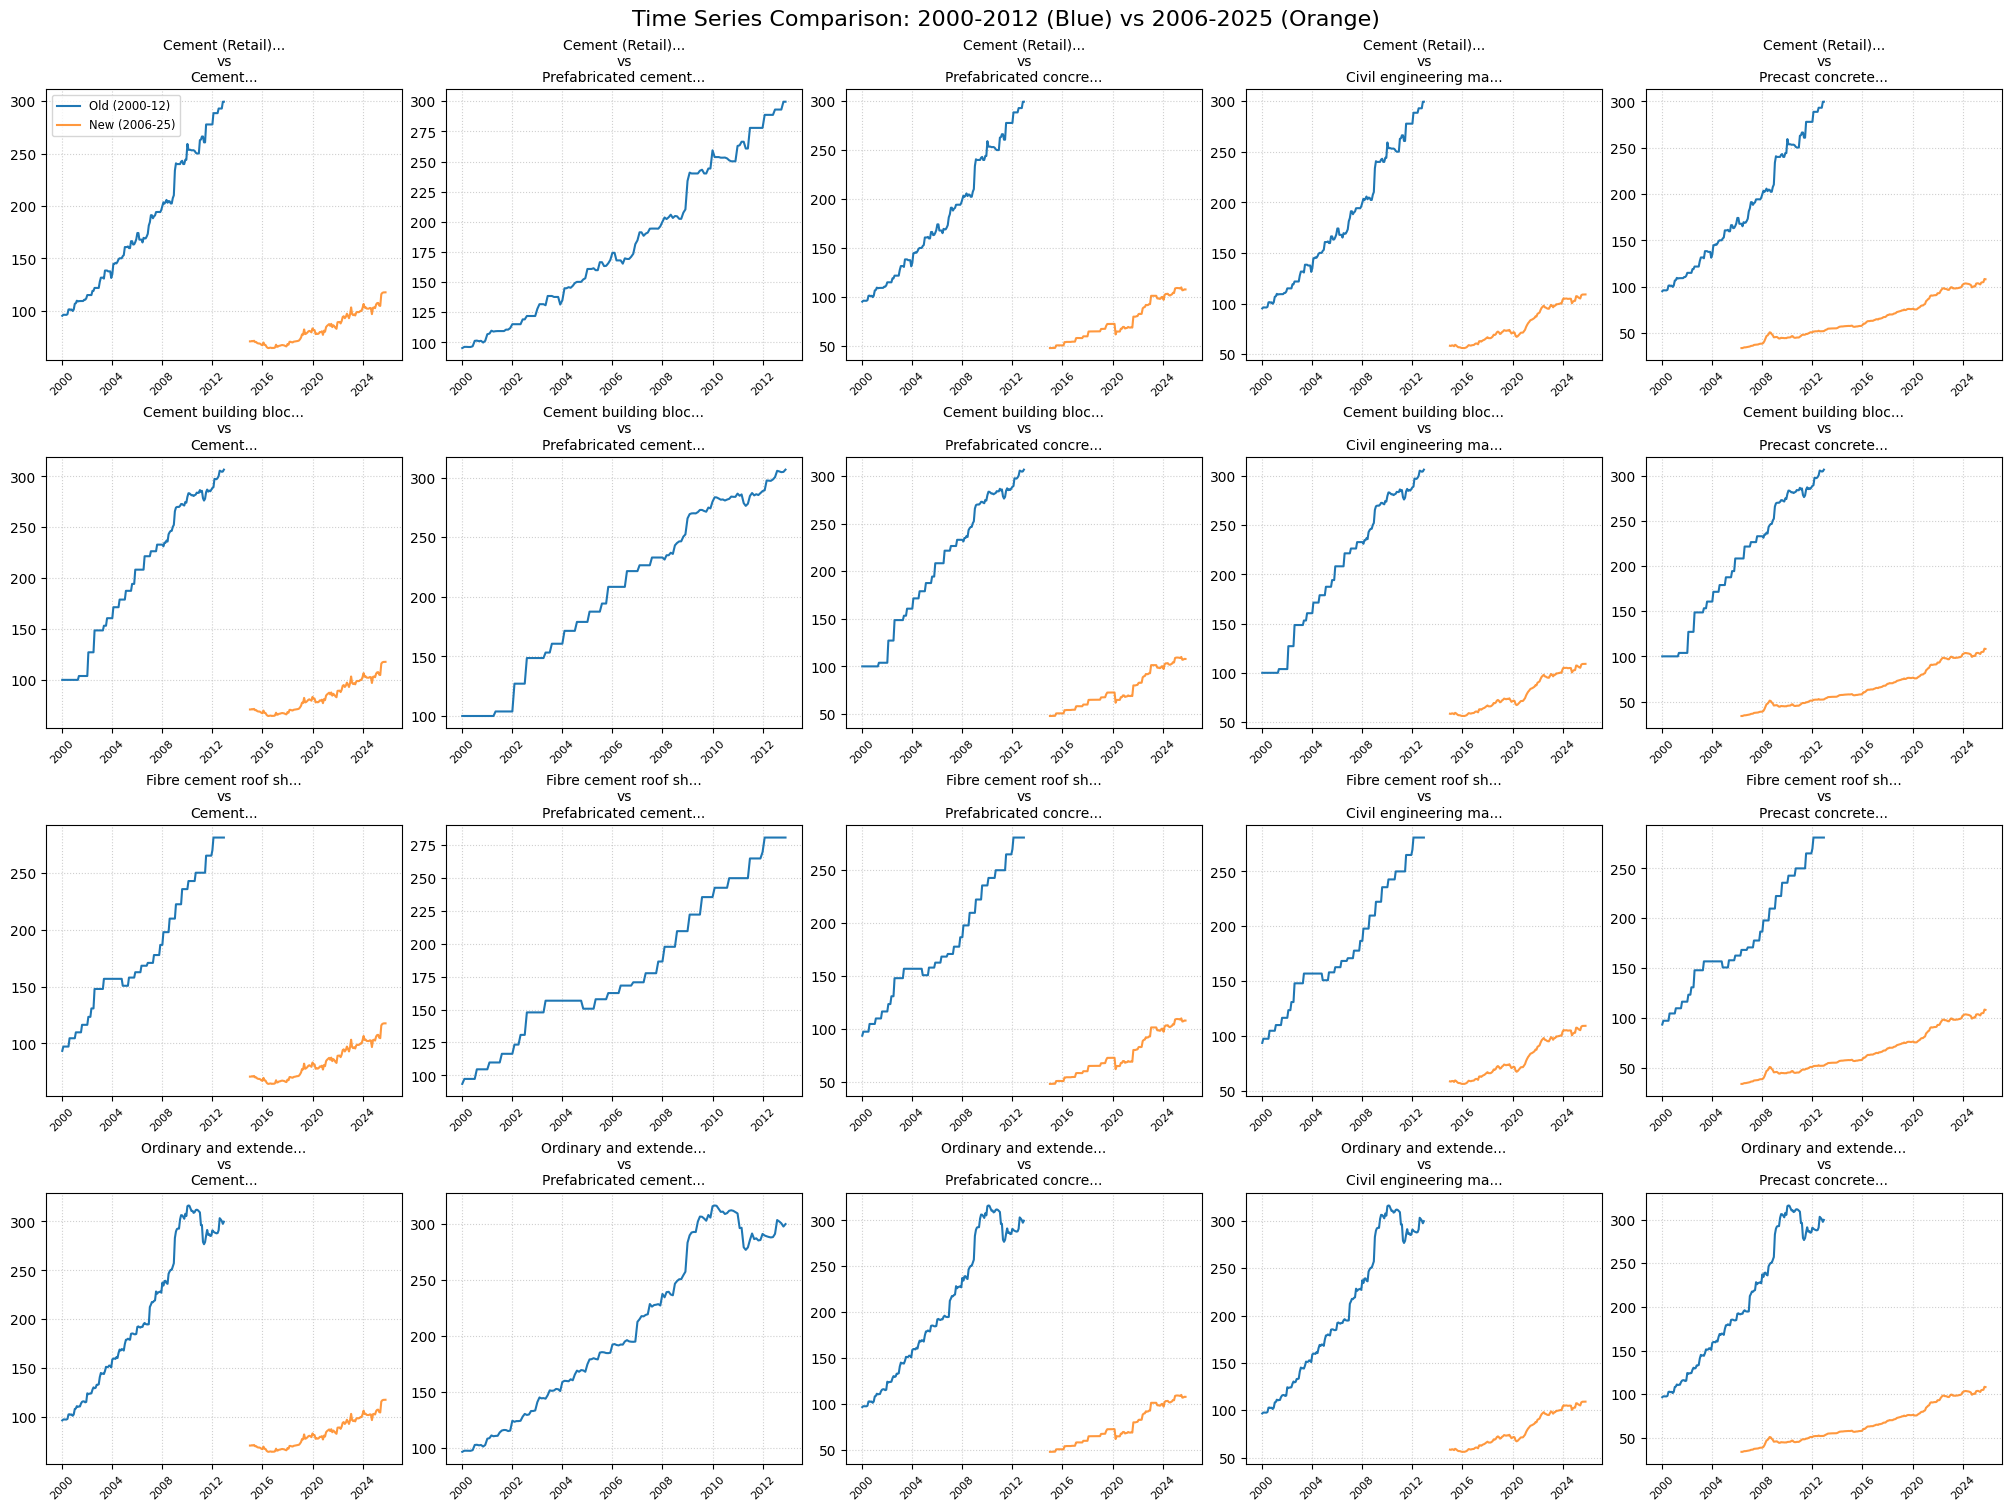

In [10]:
import matplotlib.pyplot as plt
from datetime import datetime

# Redefine lists to ensure we capture the user's latest update (Civil engineering material - total)
items_1 = [
    "Cement (Retail)",
    "Cement building blocks",
    "Fibre cement roof sheets",
    "Ordinary and extended cement"]

items_2 = [
    "Cement",
    "Prefabricated cement and concrete components",
    "Prefabricated concrete and cement",
    "Civil engineering material - total",
    "Precast concrete"

]

def parse_col_date(col_name):
    # Parse MOmmYYYY format 
    s = str(col_name).strip()
    if s.startswith("MO") and len(s) == 8 and s[2:].isdigit():
        try:
            month = int(s[2:4])
            year = int(s[4:])
            return datetime(year, month, 1)
        except:
            return None
    return None

def get_series(df, item_name):
    if df.empty: return pd.Series(dtype=float)
    row = df[df['H05'] == item_name]
    if row.empty: return pd.Series(dtype=float)
    
    data = row.iloc[0]
    date_values = {}
    
    # Iterate through columns to find valid dates and values
    for col in df.columns:
        dt = parse_col_date(col)
        # Check if date parsed successfully and value is valid number
        if dt:
            val = data[col]
            if pd.notna(val):
                try:
                    date_values[dt] = float(val)
                except:
                    pass # Skip non-numeric
            
    if not date_values: return pd.Series(dtype=float)
    
    return pd.Series(date_values).sort_index()

# Create visual comparison
n_rows = len(items_1)
n_cols = len(items_2)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 15), constrained_layout=True)
fig.suptitle('Time Series Comparison: 2000-2012 (Blue) vs 2006-2025 (Orange)', fontsize=16)

for i, item1 in enumerate(items_1):
    for j, item2 in enumerate(items_2):
        ax = axes[i, j]
        
        # Extract series
        s1 = get_series(df_2000_2012, item1)
        s2 = get_series(df_2006_2025, item2)
        
        # Plot Dataset 1
        if not s1.empty:
            ax.plot(s1.index, s1.values, label='Old (2000-12)', color='tab:blue', linewidth=1.5)
            
        # Plot Dataset 2
        if not s2.empty:
            ax.plot(s2.index, s2.values, label='New (2006-25)', color='tab:orange', linewidth=1.5, alpha=0.8)
            
        # Formatting
        ax.set_title(f"{item1[:20]}...\nvs\n{item2[:20]}...", fontsize=10)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        ax.grid(True, linestyle=':', alpha=0.6)
        
        # Add legend only to the first plot to reduce clutter
        if i == 0 and j == 0:
            ax.legend(loc='upper left', fontsize='small')

plt.show()

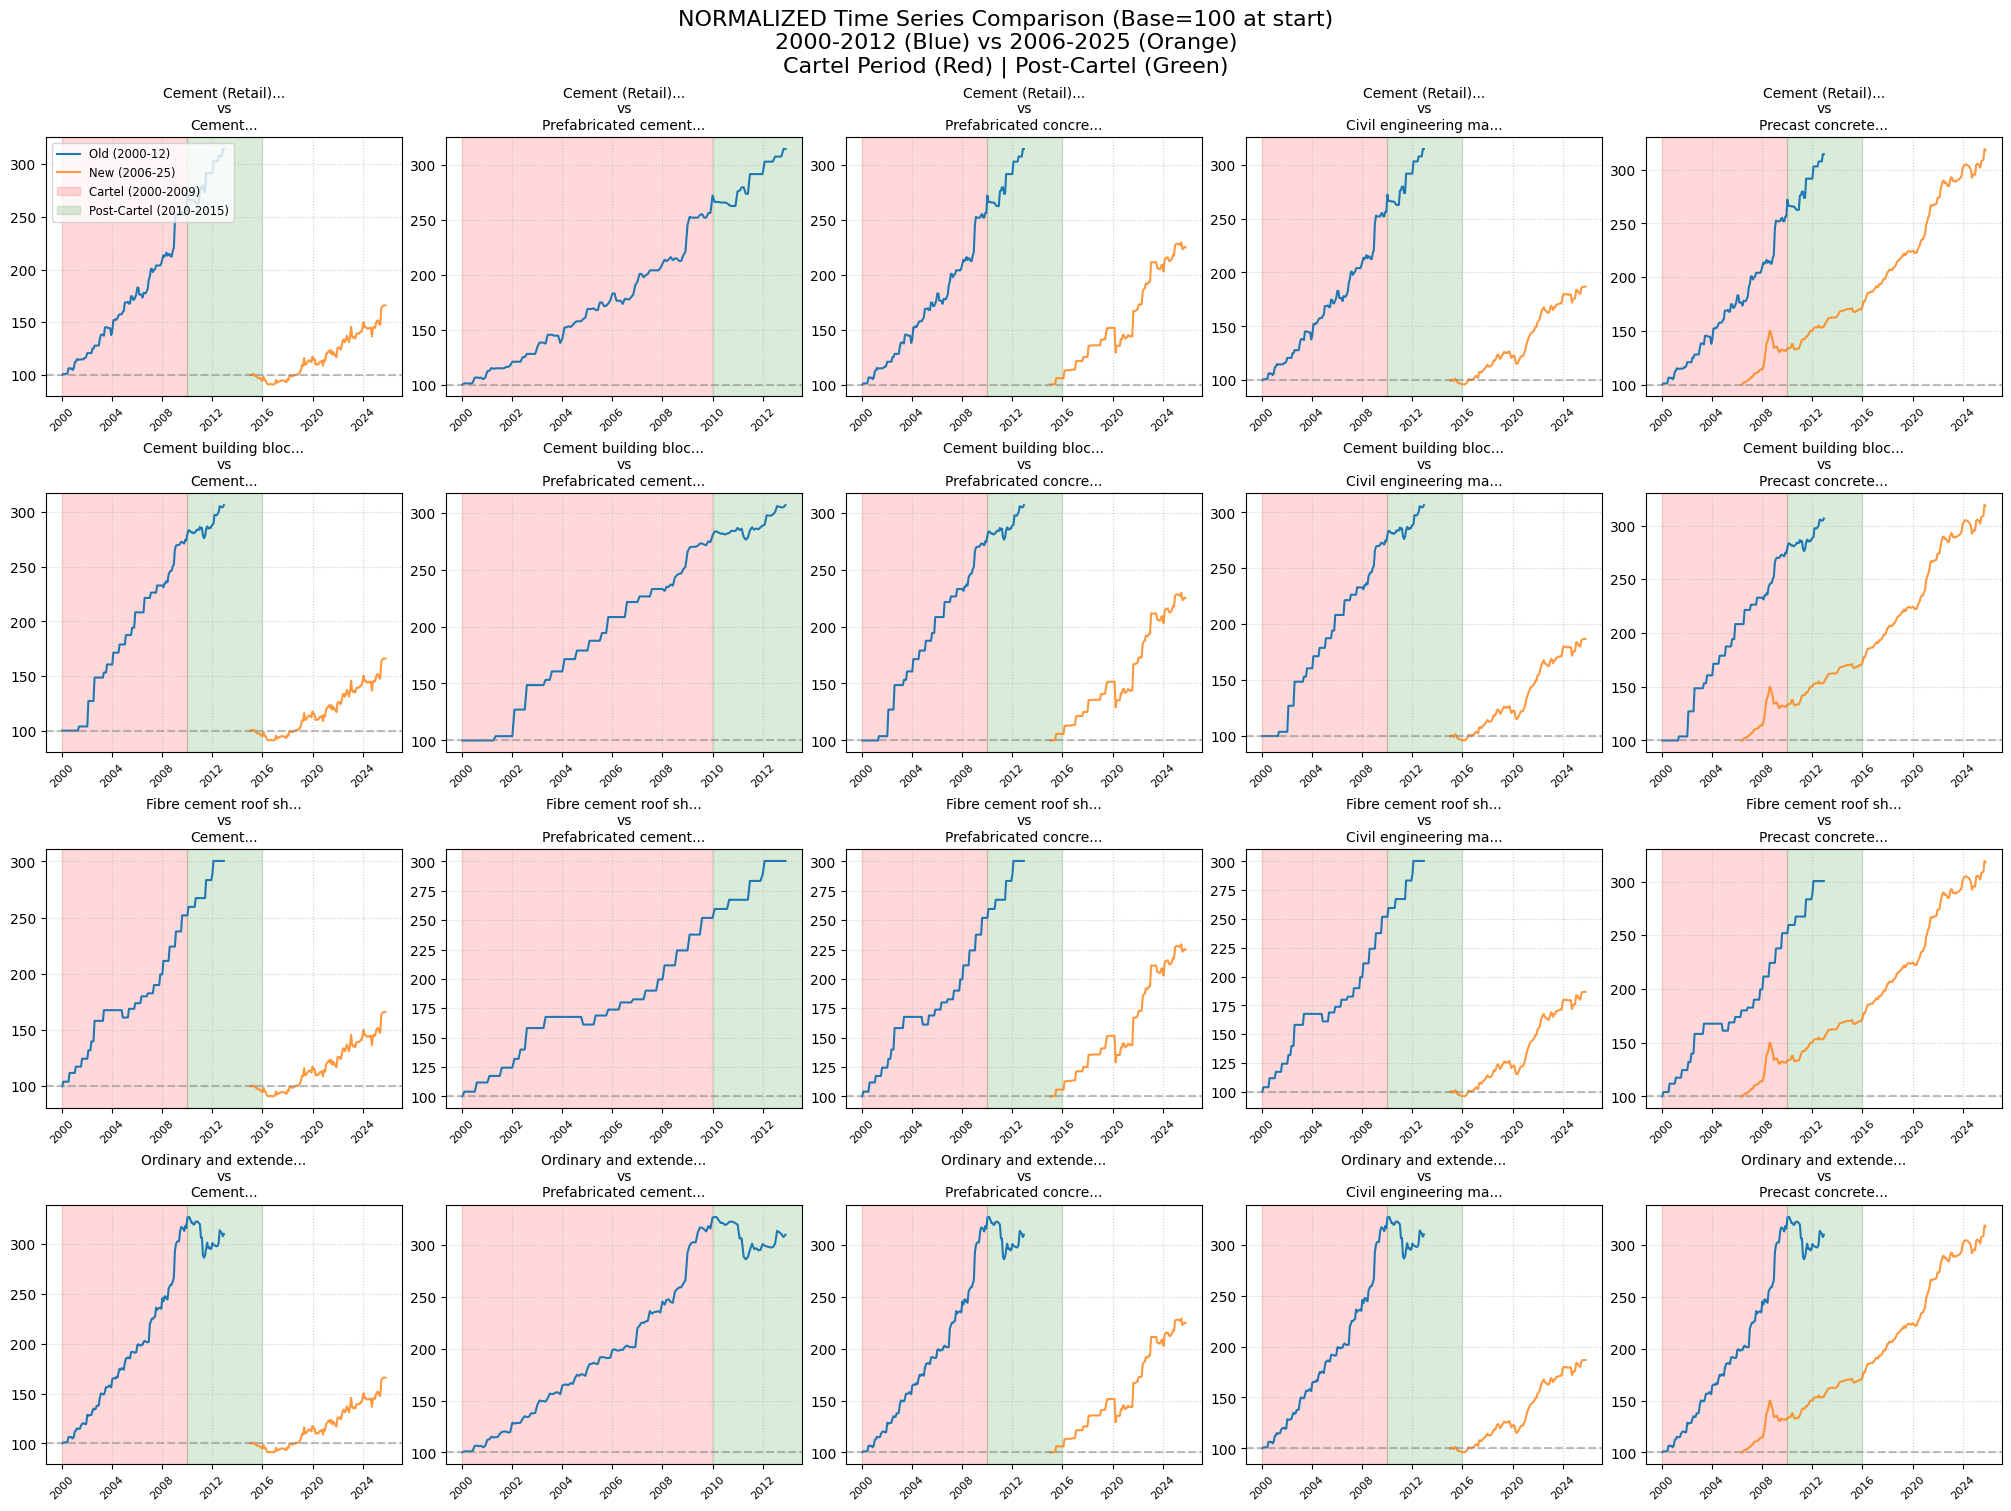


--- Alternative: Normalize to Overlap Period (May 2006) ---



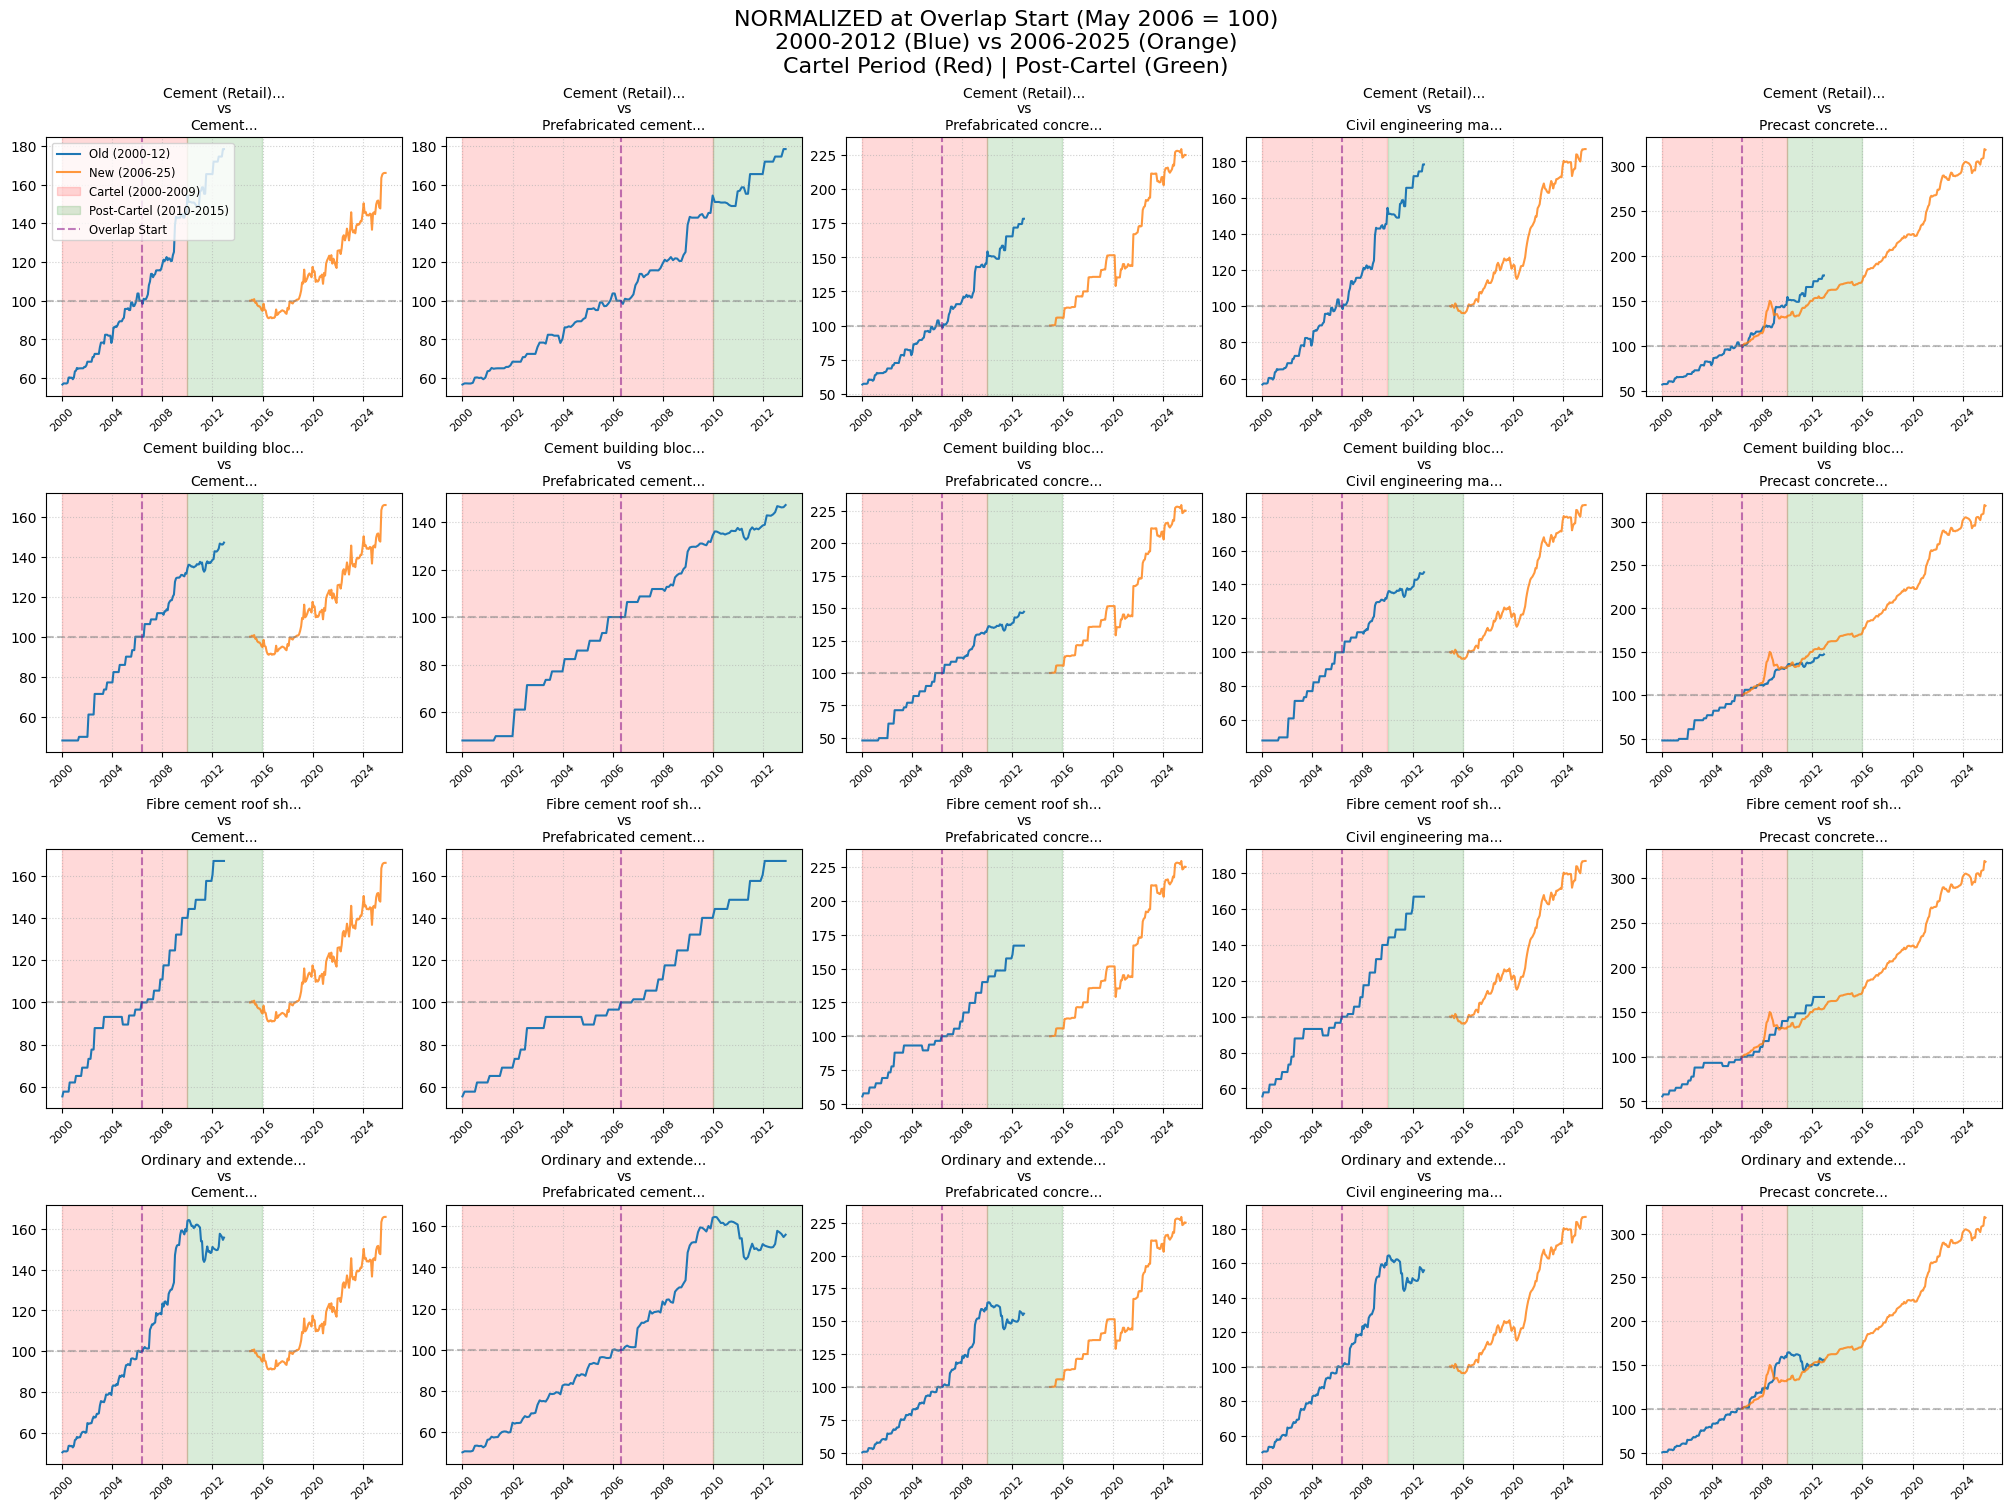

In [11]:
import matplotlib.pyplot as plt
from datetime import datetime
import matplotlib.patches as mpatches

# Redefine lists
items_1 = [
    "Cement (Retail)",
    "Cement building blocks",
    "Fibre cement roof sheets",
    "Ordinary and extended cement"
]

items_2 = [
    "Cement",
    "Prefabricated cement and concrete components",
    "Prefabricated concrete and cement",
    "Civil engineering material - total",
    "Precast concrete"
]

# Define cartel period dates
cartel_start = datetime(2000, 1, 1)
cartel_end = datetime(2009, 12, 31)
post_cartel_start = datetime(2010, 1, 1)
post_cartel_end = datetime(2015, 12, 31)

def parse_col_date(col_name):
    s = str(col_name).strip()
    if s.startswith("MO") and len(s) == 8 and s[2:].isdigit():
        try:
            month = int(s[2:4])
            year = int(s[4:])
            return datetime(year, month, 1)
        except:
            return None
    return None

def get_series(df, item_name):
    if df.empty: return pd.Series(dtype=float)
    row = df[df['H05'] == item_name]
    if row.empty: return pd.Series(dtype=float)
    
    data = row.iloc[0]
    date_values = {}
    
    for col in df.columns:
        dt = parse_col_date(col)
        if dt:
            val = data[col]
            if pd.notna(val):
                try:
                    date_values[dt] = float(val)
                except:
                    pass
            
    if not date_values: return pd.Series(dtype=float)
    
    return pd.Series(date_values).sort_index()

def normalize_series(s):
    """Normalize series to start at 100 (index normalization)"""
    if s.empty or s.iloc[0] == 0:
        return s
    return (s / s.iloc[0]) * 100

def add_cartel_highlights(ax):
    """Add shaded regions for Cartel and Post-Cartel periods"""
    ylim = ax.get_ylim()
    # Cartel period (red shading)
    ax.axvspan(cartel_start, cartel_end, alpha=0.15, color='red', label='Cartel (2000-2009)')
    # Post-Cartel period (green shading)
    ax.axvspan(post_cartel_start, post_cartel_end, alpha=0.15, color='green', label='Post-Cartel (2010-2015)')
    ax.set_ylim(ylim)

# Create visual comparison with normalized data
n_rows = len(items_1)
n_cols = len(items_2)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 15), constrained_layout=True)
fig.suptitle('NORMALIZED Time Series Comparison (Base=100 at start)\n2000-2012 (Blue) vs 2006-2025 (Orange)\nCartel Period (Red) | Post-Cartel (Green)', fontsize=16)

for i, item1 in enumerate(items_1):
    for j, item2 in enumerate(items_2):
        ax = axes[i, j]
        
        # Extract series
        s1 = get_series(df_2000_2012, item1)
        s2 = get_series(df_2006_2025, item2)
        
        # Normalize both series
        s1_norm = normalize_series(s1)
        s2_norm = normalize_series(s2)
        
        # Plot Dataset 1 (normalized)
        if not s1_norm.empty:
            ax.plot(s1_norm.index, s1_norm.values, label='Old (2000-12)', color='tab:blue', linewidth=1.5)
            
        # Plot Dataset 2 (normalized)
        if not s2_norm.empty:
            ax.plot(s2_norm.index, s2_norm.values, label='New (2006-25)', color='tab:orange', linewidth=1.5, alpha=0.8)
        
        # Add cartel period highlights
        add_cartel_highlights(ax)
            
        # Formatting
        ax.set_title(f"{item1[:20]}...\nvs\n{item2[:20]}...", fontsize=10)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5) # Reference line at base 100
        
        # Add legend only to the first plot
        if i == 0 and j == 0:
            ax.legend(loc='upper left', fontsize='small')

plt.show()

# Also create a version normalized to the overlap period start
print("\n--- Alternative: Normalize to Overlap Period (May 2006) ---\n")

fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(20, 15), constrained_layout=True)
fig2.suptitle('NORMALIZED at Overlap Start (May 2006 = 100)\n2000-2012 (Blue) vs 2006-2025 (Orange)\nCartel Period (Red) | Post-Cartel (Green)', fontsize=16)

overlap_start = datetime(2006, 5, 1)

def normalize_at_date(s, ref_date):
    """Normalize series so that value at ref_date = 100"""
    if s.empty:
        return s
    if ref_date in s.index:
        base = s[ref_date]
        if base != 0:
            return (s / base) * 100
    # Fallback: use first value
    if s.iloc[0] != 0:
        return (s / s.iloc[0]) * 100
    return s

for i, item1 in enumerate(items_1):
    for j, item2 in enumerate(items_2):
        ax = axes2[i, j]
        
        s1 = get_series(df_2000_2012, item1)
        s2 = get_series(df_2006_2025, item2)
        
        # Normalize at overlap start
        s1_norm = normalize_at_date(s1, overlap_start)
        s2_norm = normalize_at_date(s2, overlap_start)
        
        if not s1_norm.empty:
            ax.plot(s1_norm.index, s1_norm.values, label='Old (2000-12)', color='tab:blue', linewidth=1.5)
            
        if not s2_norm.empty:
            ax.plot(s2_norm.index, s2_norm.values, label='New (2006-25)', color='tab:orange', linewidth=1.5, alpha=0.8)
        
        # Add cartel period highlights
        add_cartel_highlights(ax)
            
        ax.set_title(f"{item1[:20]}...\nvs\n{item2[:20]}...", fontsize=10)
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5)
        ax.axvline(x=overlap_start, color='purple', linestyle='--', alpha=0.5, label='Overlap Start')
        
        if i == 0 and j == 0:
            ax.legend(loc='upper left', fontsize='small')

plt.show()

# Chain-Linking / Splicing with ML Gap-Filling

Since there is **no direct overlap** between the 2000-2012 and 2006-2025 datasets, we need to:
1. **ML Gap-Filling**: Use a machine learning model (polynomial regression or similar) to extrapolate/interpolate values into the gap period
2. **Splicing Factor Calculation**: Calculate the ratio between the two series in the estimated overlap period
3. **Chain-Linking**: Apply the splicing factor to create a continuous, linked time series

The methodology follows standard statistical office practices for linking index series.

In [12]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CHAIN-LINKING / SPLICING WITH ML GAP-FILLING
# ============================================================

# Configuration
OVERLAP_MONTHS = 12  # Number of months to use for splicing factor calculation
POLY_DEGREE = 2      # Polynomial degree for extrapolation

items_1 = [
    "Cement (Retail)",
    "Cement building blocks",
    "Fibre cement roof sheets",
    "Ordinary and extended cement"
]

items_2 = [
    "Cement",
    "Prefabricated cement and concrete components",
    "Prefabricated concrete and cement",
    "Civil engineering material - total",
    "Precast concrete"
]

def parse_col_date(col_name):
    """Parse MOmmYYYY format to datetime"""
    s = str(col_name).strip()
    if s.startswith("MO") and len(s) == 8 and s[2:].isdigit():
        try:
            month = int(s[2:4])
            year = int(s[4:])
            return datetime(year, month, 1)
        except:
            return None
    return None

def get_series(df, item_name):
    """Extract time series for an item"""
    if df.empty: return pd.Series(dtype=float)
    row = df[df['H05'] == item_name]
    if row.empty: return pd.Series(dtype=float)
    
    data = row.iloc[0]
    date_values = {}
    
    for col in df.columns:
        dt = parse_col_date(col)
        if dt:
            val = data[col]
            if pd.notna(val):
                try:
                    date_values[dt] = float(val)
                except:
                    pass
            
    if not date_values: return pd.Series(dtype=float)
    return pd.Series(date_values).sort_index()

def date_to_numeric(dates):
    """Convert dates to numeric values (months since epoch) for ML"""
    epoch = datetime(2000, 1, 1)
    return np.array([(d.year - epoch.year) * 12 + (d.month - epoch.month) for d in dates])

def numeric_to_date(numeric_vals, epoch=datetime(2000, 1, 1)):
    """Convert numeric values back to dates"""
    dates = []
    for n in numeric_vals:
        years, months = divmod(int(n), 12)
        dates.append(datetime(epoch.year + years, months + 1, 1))
    return dates

def fit_extrapolation_model(series, direction='forward', n_months=24):
    """
    Fit a polynomial model to extrapolate the series.
    direction: 'forward' to extrapolate into future, 'backward' to extrapolate into past
    n_months: number of months to extrapolate
    """
    if series.empty or len(series) < 6:
        return pd.Series(dtype=float)
    
    # Prepare training data
    X = date_to_numeric(series.index).reshape(-1, 1)
    y = series.values
    
    # Fit polynomial regression with Ridge regularization
    model = make_pipeline(PolynomialFeatures(POLY_DEGREE), Ridge(alpha=1.0))
    model.fit(X, y)
    
    # Generate prediction dates
    if direction == 'forward':
        last_numeric = X[-1, 0]
        pred_numeric = np.arange(last_numeric + 1, last_numeric + n_months + 1)
    else:  # backward
        first_numeric = X[0, 0]
        pred_numeric = np.arange(first_numeric - n_months, first_numeric)
    
    # Predict
    X_pred = pred_numeric.reshape(-1, 1)
    y_pred = model.predict(X_pred)
    
    # Ensure non-negative values (PPI can't be negative)
    y_pred = np.maximum(y_pred, series.min() * 0.5)
    
    # Convert back to series
    pred_dates = numeric_to_date(pred_numeric)
    return pd.Series(y_pred, index=pred_dates)

def calculate_splicing_factor(series1, series2, n_overlap=OVERLAP_MONTHS):
    """
    Calculate the splicing factor between two series based on their overlap period.
    Uses the ratio of means in the overlapping period.
    """
    # Find overlapping dates
    common_dates = series1.index.intersection(series2.index)
    
    if len(common_dates) == 0:
        return None, None
    
    # Sort and take the specified number of overlap months
    common_dates = sorted(common_dates)[:n_overlap]
    
    # Calculate mean values in overlap
    mean1 = series1.loc[common_dates].mean()
    mean2 = series2.loc[common_dates].mean()
    
    if mean1 == 0 or mean2 == 0:
        return None, None
    
    # Splicing factor: multiply series1 by this to align with series2
    factor = mean2 / mean1
    
    return factor, common_dates

def chain_link_series(series1, series2, factor, link_date):
    """
    Chain-link two series using the calculated splicing factor.
    The linked series uses series1 (scaled) before link_date and series2 after.
    """
    # Scale series1 by the splicing factor
    series1_scaled = series1 * factor
    
    # Combine: use scaled series1 before link_date, series2 from link_date onwards
    combined = pd.concat([
        series1_scaled[series1_scaled.index < link_date],
        series2[series2.index >= link_date]
    ]).sort_index()
    
    # Remove any duplicates (keep series2 values)
    combined = combined[~combined.index.duplicated(keep='last')]
    
    return combined

def full_chain_linking(series1, series2, item1_name, item2_name):
    """
    Complete chain-linking workflow:
    1. Extrapolate series1 forward / series2 backward to create overlap
    2. Calculate splicing factor on the extrapolated overlap
    3. Chain-link the original series
    """
    result = {
        'item_1': item1_name,
        'item_2': item2_name,
        'original_series_1': series1,
        'original_series_2': series2,
        'success': False
    }
    
    if series1.empty or series2.empty:
        result['error'] = 'Empty series'
        return result
    
    # Determine the gap
    end_1 = series1.index.max()
    start_2 = series2.index.min()
    
    if end_1 >= start_2:
        # Already overlapping - calculate factor directly
        factor, overlap_dates = calculate_splicing_factor(series1, series2)
        if factor:
            link_date = min(overlap_dates)
            chained = chain_link_series(series1, series2, factor, link_date)
            result.update({
                'success': True,
                'method': 'direct_overlap',
                'splicing_factor': factor,
                'overlap_dates': overlap_dates,
                'link_date': link_date,
                'chained_series': chained,
                'extrapolated_1': series1,
                'extrapolated_2': series2
            })
        return result
    
    # Calculate gap in months
    gap_months = (start_2.year - end_1.year) * 12 + (start_2.month - end_1.month)
    
    # Extrapolate series1 forward to meet series2
    extrap_months = gap_months + OVERLAP_MONTHS
    series1_extended = fit_extrapolation_model(series1, 'forward', extrap_months)
    
    # Combine original with extrapolated
    series1_full = pd.concat([series1, series1_extended]).sort_index()
    series1_full = series1_full[~series1_full.index.duplicated(keep='first')]
    
    # Also extrapolate series2 backward for robustness
    series2_extended = fit_extrapolation_model(series2, 'backward', gap_months + OVERLAP_MONTHS)
    series2_full = pd.concat([series2_extended, series2]).sort_index()
    series2_full = series2_full[~series2_full.index.duplicated(keep='last')]
    
    # Calculate splicing factor on the created overlap
    factor, overlap_dates = calculate_splicing_factor(series1_full, series2_full, OVERLAP_MONTHS)
    
    if factor is None:
        result['error'] = 'Could not calculate splicing factor'
        return result
    
    # Use the start of the actual series2 as the link date
    link_date = start_2
    
    # Chain-link the original series (not the extrapolated ones)
    chained = chain_link_series(series1, series2, factor, link_date)
    
    result.update({
        'success': True,
        'method': 'ml_extrapolation',
        'gap_months': gap_months,
        'splicing_factor': factor,
        'overlap_dates': overlap_dates,
        'link_date': link_date,
        'chained_series': chained,
        'extrapolated_1': series1_full,
        'extrapolated_2': series2_full
    })
    
    return result

# ============================================================
# PERFORM CHAIN-LINKING FOR ALL COMBINATIONS
# ============================================================

chain_link_results = []

print("=" * 80)
print("CHAIN-LINKING RESULTS")
print("=" * 80)

for item1 in items_1:
    for item2 in items_2:
        s1 = get_series(df_2000_2012, item1)
        s2 = get_series(df_2006_2025, item2)
        
        result = full_chain_linking(s1, s2, item1, item2)
        chain_link_results.append(result)
        
        if result['success']:
            print(f"\n✅ {item1} ⟷ {item2}")
            print(f"   Method: {result['method']}")
            print(f"   Splicing Factor: {result['splicing_factor']:.4f}")
            print(f"   Link Date: {result['link_date'].strftime('%Y-%m')}")
            if 'gap_months' in result:
                print(f"   Gap Filled: {result['gap_months']} months")
            print(f"   Chained Series Range: {result['chained_series'].index.min().strftime('%Y-%m')} to {result['chained_series'].index.max().strftime('%Y-%m')}")
        else:
            print(f"\n❌ {item1} ⟷ {item2}: {result.get('error', 'Unknown error')}")

print("\n" + "=" * 80)
print(f"Successfully chain-linked: {sum(1 for r in chain_link_results if r['success'])}/{len(chain_link_results)}")
print("=" * 80)

CHAIN-LINKING RESULTS

✅ Cement (Retail) ⟷ Cement
   Method: ml_extrapolation
   Splicing Factor: 0.2354
   Link Date: 2015-01
   Gap Filled: 25 months
   Chained Series Range: 2000-01 to 2025-11

❌ Cement (Retail) ⟷ Prefabricated cement and concrete components: Empty series

✅ Cement (Retail) ⟷ Prefabricated concrete and cement
   Method: ml_extrapolation
   Splicing Factor: 0.1546
   Link Date: 2015-01
   Gap Filled: 25 months
   Chained Series Range: 2000-01 to 2025-11

✅ Cement (Retail) ⟷ Civil engineering material - total
   Method: ml_extrapolation
   Splicing Factor: 0.1698
   Link Date: 2015-01
   Gap Filled: 25 months
   Chained Series Range: 2000-01 to 2025-11

✅ Cement (Retail) ⟷ Precast concrete
   Method: direct_overlap
   Splicing Factor: 0.1992
   Link Date: 2006-05
   Chained Series Range: 2000-01 to 2025-11

✅ Cement building blocks ⟷ Cement
   Method: ml_extrapolation
   Splicing Factor: 0.2285
   Link Date: 2015-01
   Gap Filled: 25 months
   Chained Series Range: 20

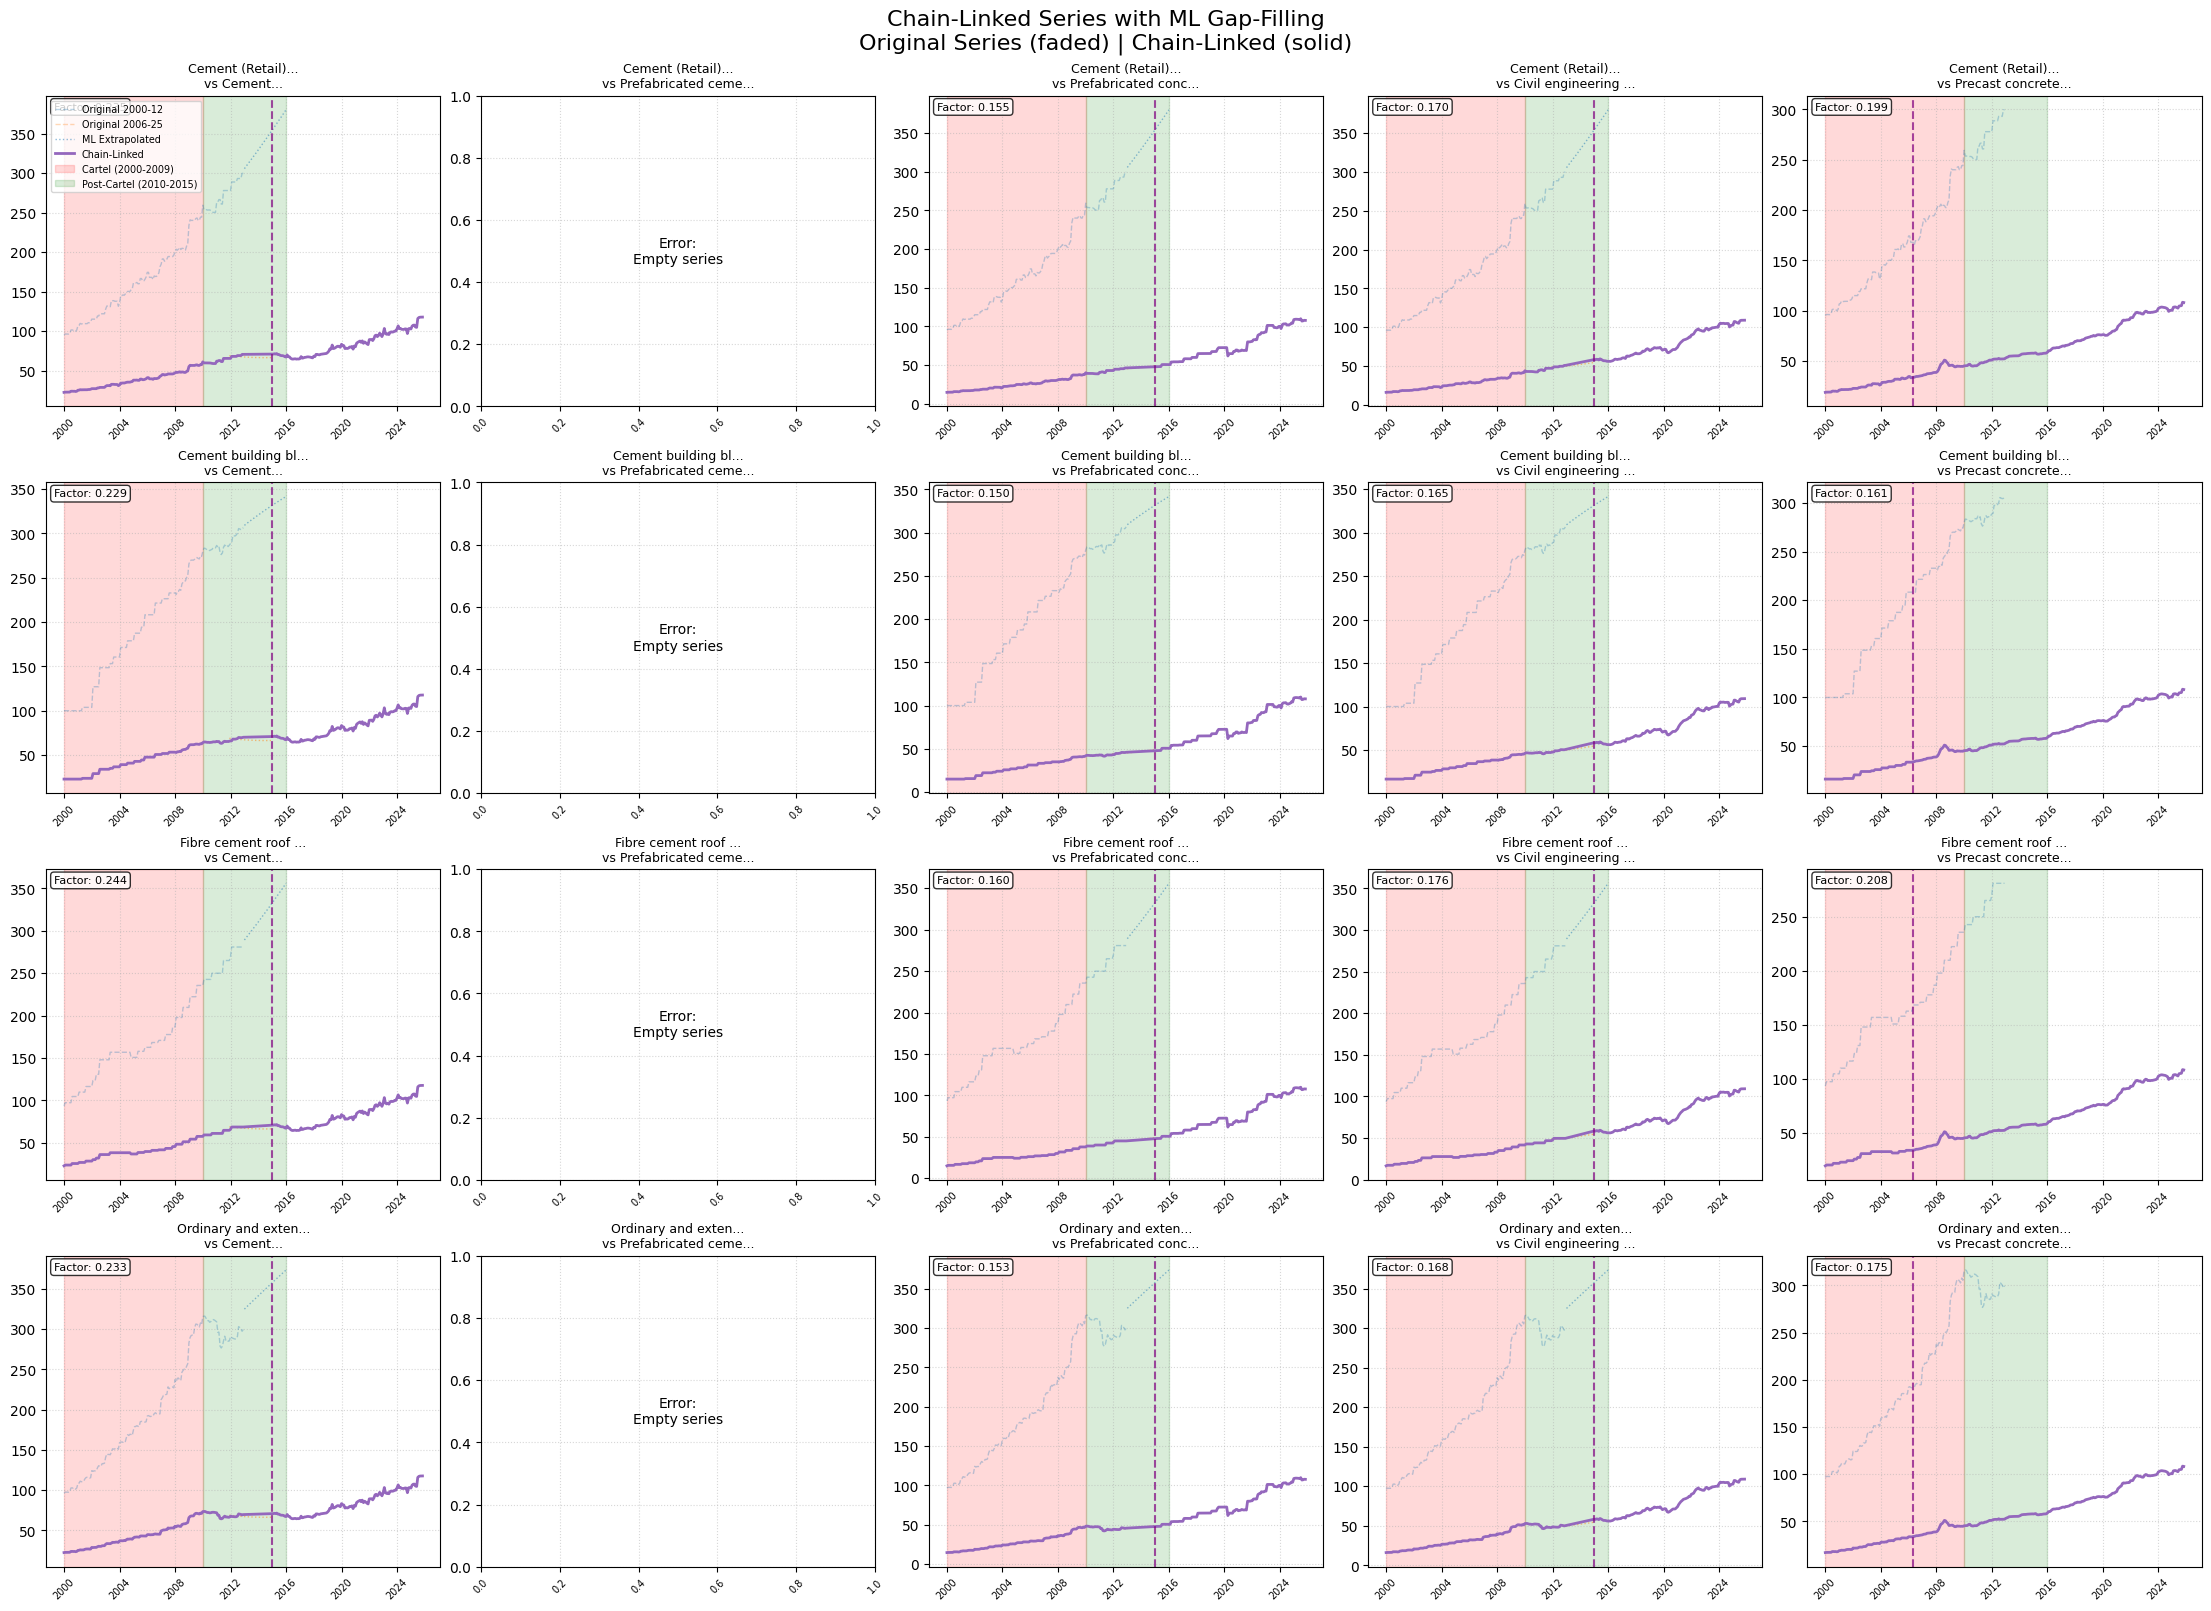

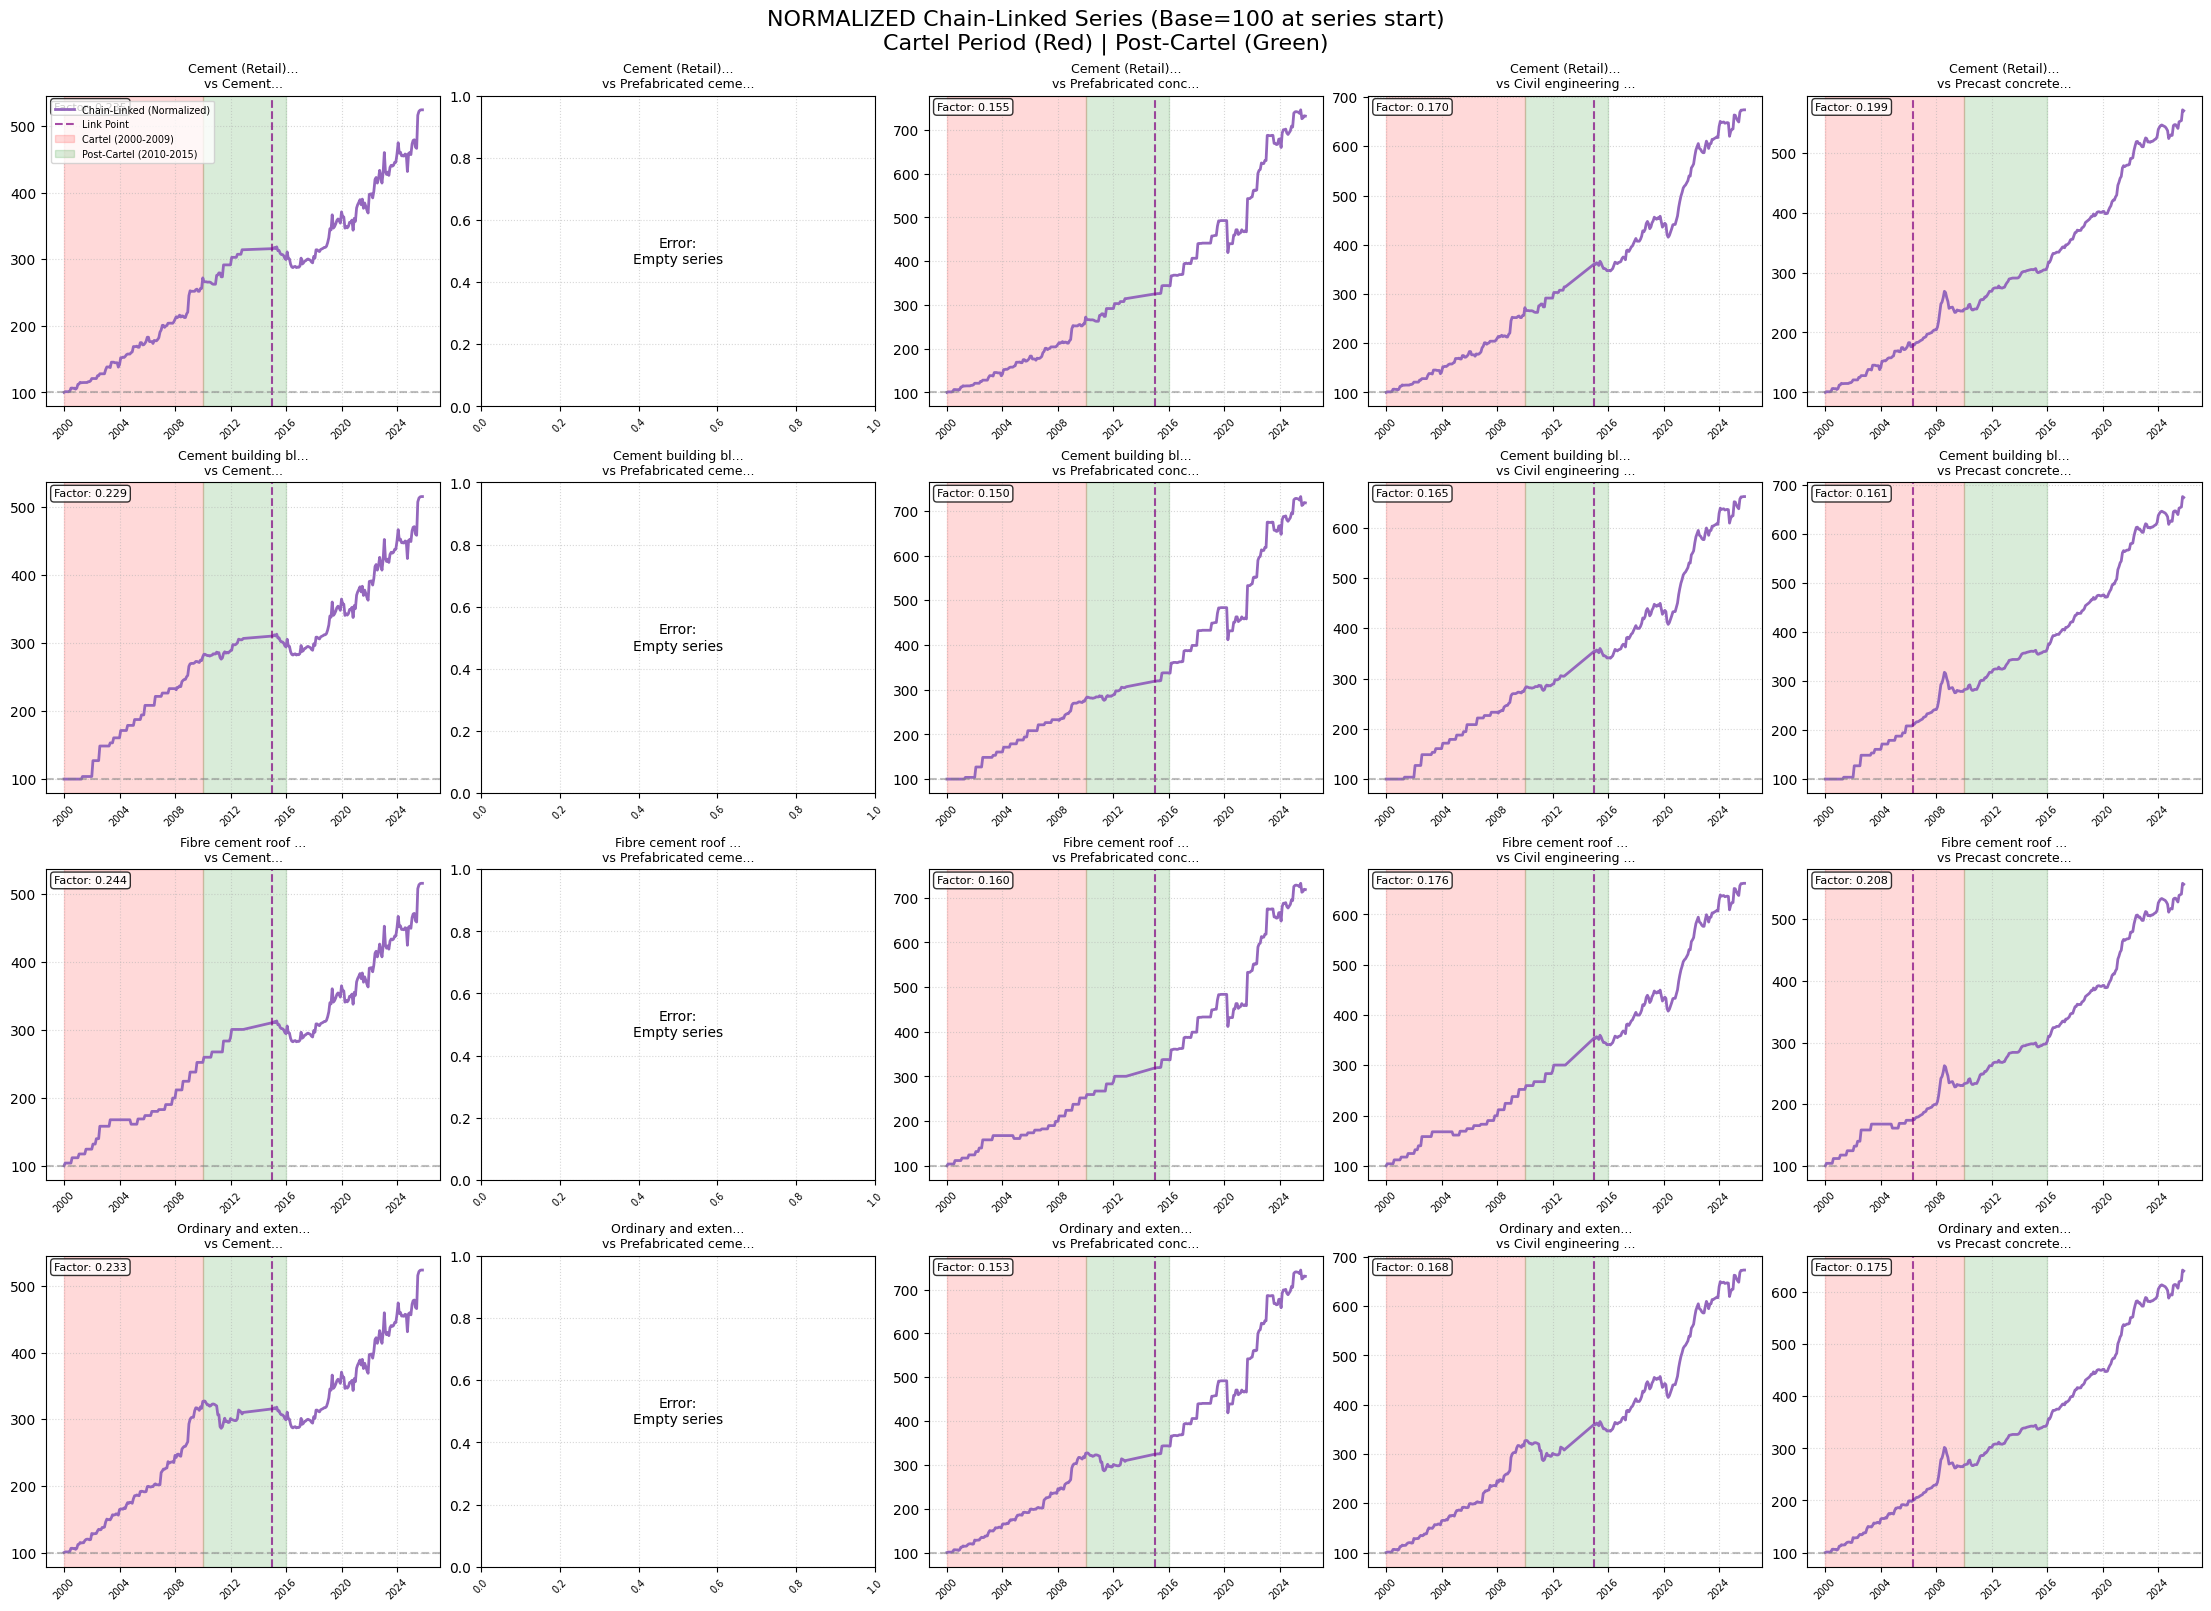


✅ Chain-linking visualization complete!


In [13]:
# ============================================================
# VISUALIZE CHAIN-LINKED SERIES
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Define period highlights
cartel_start = datetime(2000, 1, 1)
cartel_end = datetime(2009, 12, 31)
post_cartel_start = datetime(2010, 1, 1)
post_cartel_end = datetime(2015, 12, 31)

def add_period_highlights(ax):
    """Add shaded regions for Cartel and Post-Cartel periods"""
    ylim = ax.get_ylim()
    ax.axvspan(cartel_start, cartel_end, alpha=0.15, color='red', label='Cartel (2000-2009)')
    ax.axvspan(post_cartel_start, post_cartel_end, alpha=0.15, color='green', label='Post-Cartel (2010-2015)')
    ax.set_ylim(ylim)

# Plot chain-linked results
n_rows = len(items_1)
n_cols = len(items_2)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 16), constrained_layout=True)
fig.suptitle('Chain-Linked Series with ML Gap-Filling\nOriginal Series (faded) | Chain-Linked (solid)', fontsize=16)

for idx, result in enumerate(chain_link_results):
    i = idx // n_cols
    j = idx % n_cols
    ax = axes[i, j]
    
    if result['success']:
        # Plot original series (faded)
        s1 = result['original_series_1']
        s2 = result['original_series_2']
        
        if not s1.empty:
            ax.plot(s1.index, s1.values, color='tab:blue', alpha=0.3, linewidth=1, linestyle='--', label='Original 2000-12')
        if not s2.empty:
            ax.plot(s2.index, s2.values, color='tab:orange', alpha=0.3, linewidth=1, linestyle='--', label='Original 2006-25')
        
        # Plot extrapolated portions (if ML method)
        if result['method'] == 'ml_extrapolation':
            extrap_1 = result['extrapolated_1']
            extrap_2 = result['extrapolated_2']
            # Show only the extrapolated parts
            extrap_only_1 = extrap_1[extrap_1.index > s1.index.max()]
            extrap_only_2 = extrap_2[extrap_2.index < s2.index.min()]
            
            if not extrap_only_1.empty:
                ax.plot(extrap_only_1.index, extrap_only_1.values, color='tab:blue', alpha=0.5, linewidth=1, linestyle=':', label='ML Extrapolated')
            if not extrap_only_2.empty:
                ax.plot(extrap_only_2.index, extrap_only_2.values, color='tab:orange', alpha=0.5, linewidth=1, linestyle=':')
        
        # Plot chain-linked series (bold)
        chained = result['chained_series']
        ax.plot(chained.index, chained.values, color='tab:purple', linewidth=2, label='Chain-Linked')
        
        # Mark link date
        ax.axvline(x=result['link_date'], color='purple', linestyle='--', alpha=0.7, linewidth=1.5)
        
        # Add period highlights
        add_period_highlights(ax)
        
        # Add splicing factor annotation
        ax.text(0.02, 0.98, f"Factor: {result['splicing_factor']:.3f}", 
                transform=ax.transAxes, fontsize=8, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        ax.text(0.5, 0.5, f"Error:\n{result.get('error', 'Unknown')}", 
                transform=ax.transAxes, ha='center', va='center', fontsize=10)
    
    # Formatting
    ax.set_title(f"{result['item_1'][:18]}...\nvs {result['item_2'][:18]}...", fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.grid(True, linestyle=':', alpha=0.5)
    
    if i == 0 and j == 0:
        ax.legend(loc='upper left', fontsize='x-small')

plt.show()

# ============================================================
# NORMALIZED CHAIN-LINKED SERIES (Base = 100 at start)
# ============================================================

fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(22, 16), constrained_layout=True)
fig2.suptitle('NORMALIZED Chain-Linked Series (Base=100 at series start)\nCartel Period (Red) | Post-Cartel (Green)', fontsize=16)

def normalize_series(s):
    if s.empty or s.iloc[0] == 0:
        return s
    return (s / s.iloc[0]) * 100

for idx, result in enumerate(chain_link_results):
    i = idx // n_cols
    j = idx % n_cols
    ax = axes2[i, j]
    
    if result['success']:
        # Normalize chain-linked series
        chained = result['chained_series']
        chained_norm = normalize_series(chained)
        
        # Plot normalized chain-linked
        ax.plot(chained_norm.index, chained_norm.values, color='tab:purple', linewidth=2, label='Chain-Linked (Normalized)')
        
        # Mark link date
        ax.axvline(x=result['link_date'], color='purple', linestyle='--', alpha=0.7, linewidth=1.5, label='Link Point')
        
        # Reference line at 100
        ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5)
        
        # Add period highlights
        add_period_highlights(ax)
        
        # Add splicing factor annotation
        ax.text(0.02, 0.98, f"Factor: {result['splicing_factor']:.3f}", 
                transform=ax.transAxes, fontsize=8, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        ax.text(0.5, 0.5, f"Error:\n{result.get('error', 'Unknown')}", 
                transform=ax.transAxes, ha='center', va='center', fontsize=10)
    
    ax.set_title(f"{result['item_1'][:18]}...\nvs {result['item_2'][:18]}...", fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.grid(True, linestyle=':', alpha=0.5)
    
    if i == 0 and j == 0:
        ax.legend(loc='upper left', fontsize='x-small')

plt.show()

print("\n✅ Chain-linking visualization complete!")

In [14]:
import json
from datetime import datetime

# ============================================================
# EXPORT DATA FOR DASHBOARD (INCLUDING CHAIN-LINKED SERIES)
# ============================================================

def series_to_dict(s):
    """Convert pandas Series to JSON-serializable dict"""
    if s is None or (hasattr(s, 'empty') and s.empty):
        return {}
    return {d.strftime('%Y-%m-%d'): float(v) for d, v in s.items()}

def normalize_dict(d):
    """Normalize dict values so first value = 100"""
    if not d:
        return {}
    sorted_keys = sorted(d.keys())
    first_val = d[sorted_keys[0]]
    if first_val == 0:
        return d
    return {k: (v / first_val) * 100 for k, v in d.items()}

# Build export data structure with chain-linking info
export_data = {
    "title": "South Africa Cement Cartel Analysis",
    "description": "Time series comparison of cement-related Producer Price Indices from South Africa, analyzing the cartel period (2000-2009) vs post-cartel period (2010-2015). Includes ML-based chain-linking to create continuous series.",
    "methodology": {
        "chain_linking": "Polynomial regression (degree 2) with Ridge regularization used to extrapolate series and calculate splicing factors",
        "overlap_months_for_factor": 12,
        "normalization": "Base = 100 at series start"
    },
    "cartel_period": {"start": "2000-01-01", "end": "2009-12-31"},
    "post_cartel_period": {"start": "2010-01-01", "end": "2015-12-31"},
    "dataset_1": {
        "name": "2000-2012 Dataset (Producer Price Index 2000)",
        "items": items_1
    },
    "dataset_2": {
        "name": "2006-2025 Dataset (Construction Materials Price Indices)", 
        "items": items_2
    },
    "series_data": [],
    "summary_stats": {
        "total_comparisons": len(items_1) * len(items_2),
        "items_dataset_1": len(items_1),
        "items_dataset_2": len(items_2),
        "successful_chain_links": 0
    }
}

# Process chain_link_results (from earlier cell)
for result in chain_link_results:
    # Convert series to dicts for JSON
    raw_1 = series_to_dict(result['original_series_1'])
    raw_2 = series_to_dict(result['original_series_2'])
    
    comparison = {
        "item_1": result['item_1'],
        "item_2": result['item_2'],
        "raw_series_1": raw_1,
        "raw_series_2": raw_2,
        "normalized_series_1": normalize_dict(raw_1),
        "normalized_series_2": normalize_dict(raw_2),
        "date_range_1": {
            "start": min(raw_1.keys()) if raw_1 else None,
            "end": max(raw_1.keys()) if raw_1 else None
        },
        "date_range_2": {
            "start": min(raw_2.keys()) if raw_2 else None,
            "end": max(raw_2.keys()) if raw_2 else None
        },
        "chain_link": {
            "success": result['success']
        }
    }
    
    if result['success']:
        export_data['summary_stats']['successful_chain_links'] += 1
        
        # Add chain-linked data
        chained_raw = series_to_dict(result['chained_series'])
        chained_normalized = normalize_dict(chained_raw)
        
        comparison['chain_link'].update({
            "method": result['method'],
            "splicing_factor": result['splicing_factor'],
            "link_date": result['link_date'].strftime('%Y-%m-%d'),
            "gap_months": result.get('gap_months', 0),
            "chained_series_raw": chained_raw,
            "chained_series_normalized": chained_normalized,
            "date_range": {
                "start": min(chained_raw.keys()) if chained_raw else None,
                "end": max(chained_raw.keys()) if chained_raw else None
            }
        })
        
        # Also add extrapolated series for visualization
        if result['method'] == 'ml_extrapolation':
            comparison['chain_link']['extrapolated_1'] = series_to_dict(result['extrapolated_1'])
            comparison['chain_link']['extrapolated_2'] = series_to_dict(result['extrapolated_2'])
    else:
        comparison['chain_link']['error'] = result.get('error', 'Unknown error')
    
    export_data['series_data'].append(comparison)

# Calculate additional stats
splicing_factors = [r['splicing_factor'] for r in chain_link_results if r['success']]
if splicing_factors:
    export_data['summary_stats']['avg_splicing_factor'] = sum(splicing_factors) / len(splicing_factors)
    export_data['summary_stats']['min_splicing_factor'] = min(splicing_factors)
    export_data['summary_stats']['max_splicing_factor'] = max(splicing_factors)

# Save to JSON file in ppi_dashboard folder
output_path = '../ppi_dashboard/south_africa_cement_data.json'
with open(output_path, 'w') as f:
    json.dump(export_data, f, indent=2)

print(f"✅ Data exported successfully to: {output_path}")
print(f"   - {len(export_data['series_data'])} comparison series exported")
print(f"   - {export_data['summary_stats']['successful_chain_links']} successfully chain-linked")
print(f"   - Dataset 1 items: {items_1}")
print(f"   - Dataset 2 items: {items_2}")
if splicing_factors:
    print(f"\n📊 Splicing Factor Statistics:")
    print(f"   - Average: {export_data['summary_stats']['avg_splicing_factor']:.4f}")
    print(f"   - Min: {export_data['summary_stats']['min_splicing_factor']:.4f}")
    print(f"   - Max: {export_data['summary_stats']['max_splicing_factor']:.4f}")

✅ Data exported successfully to: ../ppi_dashboard/south_africa_cement_data.json
   - 20 comparison series exported
   - 16 successfully chain-linked
   - Dataset 1 items: ['Cement (Retail)', 'Cement building blocks', 'Fibre cement roof sheets', 'Ordinary and extended cement']
   - Dataset 2 items: ['Cement', 'Prefabricated cement and concrete components', 'Prefabricated concrete and cement', 'Civil engineering material - total', 'Precast concrete']

📊 Splicing Factor Statistics:
   - Average: 0.1863
   - Min: 0.1501
   - Max: 0.2444


## 5.3 Cartel Trend Projection: Measuring the "Institutional Dividend"

**Methodology:**
1. Use the **chain-linked data** which spans 2000-2025 (combining both datasets)
2. Train a regression model on the **cartel period (2000-2009)** to learn the price trend
3. Use that model to **extrapolate/predict** what prices would have been if the cartel continued (counterfactual)
4. Compare **predicted (cartel counterfactual)** vs **actual** post-cartel prices
5. The difference = **"Institutional Dividend"** (savings from breaking the cartel)

If actual prices are LOWER than predicted → Competition Commission intervention succeeded → Positive Institutional Dividend

In [15]:
# ============================================================
# CARTEL TREND PROJECTION FOR ALL CHAIN-LINKED PAIRS
# ============================================================
# Train on cartel period (2000-2009), predict post-cartel,
# compare actual vs predicted to measure "Institutional Dividend"

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define periods
CARTEL_START = pd.Timestamp('2000-01-01')
CARTEL_END = pd.Timestamp('2009-12-31')
INTERVENTION_DATE = pd.Timestamp('2009-01-01')

print("=" * 80)
print("CARTEL TREND PROJECTION: INSTITUTIONAL DIVIDEND ANALYSIS")
print("=" * 80)
print(f"📅 Cartel Period: {CARTEL_START.strftime('%Y-%m')} to {CARTEL_END.strftime('%Y-%m')}")
print(f"📅 Post-Cartel Period: 2010-01 onwards")
print(f"📊 Chain-linked pairs available: {len([r for r in chain_link_results if r['success']])}")
print("-" * 80)

# Store results for all pairs
projection_results = []

# Get successful chain-linked pairs
successful_pairs = [r for r in chain_link_results if r['success']]

for idx, result in enumerate(successful_pairs):
    pair_name = f"{result['item_1']} → {result['item_2']}"
    print(f"\n{'='*60}")
    print(f"Pair {idx+1}/{len(successful_pairs)}: {pair_name}")
    print(f"{'='*60}")
    
    # Get the chain-linked series
    chained_series = result['chained_series'].copy()
    chained_series.index = pd.to_datetime(chained_series.index)
    chained_series = chained_series.sort_index().dropna()
    
    # Split into cartel and post-cartel periods
    cartel_data = chained_series[(chained_series.index >= CARTEL_START) & 
                                  (chained_series.index <= CARTEL_END)]
    post_cartel_data = chained_series[chained_series.index > CARTEL_END]
    
    print(f"  📊 Total observations: {len(chained_series)}")
    print(f"  📊 Cartel period: {len(cartel_data)} observations ({cartel_data.index.min().strftime('%Y-%m')} to {cartel_data.index.max().strftime('%Y-%m')})")
    print(f"  📊 Post-cartel period: {len(post_cartel_data)} observations")
    
    if len(cartel_data) < 24:
        print(f"  ⚠️ Skipping: Insufficient cartel period data")
        continue
    
    if len(post_cartel_data) < 12:
        print(f"  ⚠️ Skipping: Insufficient post-cartel data")
        continue
    
    # Convert dates to numeric for regression (months since start)
    start_date = chained_series.index.min()
    
    def date_to_numeric(dates):
        return np.array([(d - start_date).days / 30.44 for d in dates])  # Approx months
    
    X_cartel = date_to_numeric(cartel_data.index).reshape(-1, 1)
    y_cartel = cartel_data.values
    
    X_post = date_to_numeric(post_cartel_data.index).reshape(-1, 1)
    y_post_actual = post_cartel_data.values
    
    # Fit multiple models and select the best one
    models = {
        'Linear': LinearRegression(),
        'Quadratic': None,  # Will use PolynomialFeatures
        'Ridge (degree 2)': None
    }
    
    best_model = None
    best_model_name = None
    best_r2 = -np.inf
    best_predictions = None
    
    # 1. Linear Regression
    lr = LinearRegression()
    lr.fit(X_cartel, y_cartel)
    y_pred_cartel_lr = lr.predict(X_cartel)
    r2_lr = 1 - np.sum((y_cartel - y_pred_cartel_lr)**2) / np.sum((y_cartel - np.mean(y_cartel))**2)
    
    if r2_lr > best_r2:
        best_r2 = r2_lr
        best_model = lr
        best_model_name = 'Linear'
        best_predictions = lr.predict(X_post)
        best_poly = None
    
    # 2. Quadratic (Polynomial degree 2)
    poly2 = PolynomialFeatures(degree=2)
    X_cartel_poly2 = poly2.fit_transform(X_cartel)
    X_post_poly2 = poly2.transform(X_post)
    
    lr_poly2 = LinearRegression()
    lr_poly2.fit(X_cartel_poly2, y_cartel)
    y_pred_cartel_poly2 = lr_poly2.predict(X_cartel_poly2)
    r2_poly2 = 1 - np.sum((y_cartel - y_pred_cartel_poly2)**2) / np.sum((y_cartel - np.mean(y_cartel))**2)
    
    if r2_poly2 > best_r2:
        best_r2 = r2_poly2
        best_model = lr_poly2
        best_model_name = 'Quadratic'
        best_predictions = lr_poly2.predict(X_post_poly2)
        best_poly = poly2
    
    # 3. Ridge with degree 2 (regularized to prevent overfitting)
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_cartel_poly2, y_cartel)
    y_pred_cartel_ridge = ridge.predict(X_cartel_poly2)
    r2_ridge = 1 - np.sum((y_cartel - y_pred_cartel_ridge)**2) / np.sum((y_cartel - np.mean(y_cartel))**2)
    
    # Prefer Ridge if R² is close to polynomial (within 0.01) for stability
    if r2_ridge > best_r2 - 0.01:
        best_r2 = r2_ridge
        best_model = ridge
        best_model_name = 'Ridge (degree 2)'
        best_predictions = ridge.predict(X_post_poly2)
        best_poly = poly2
    
    print(f"\n  🔧 Best Model: {best_model_name} (R² = {best_r2:.4f})")
    
    # Calculate the "Institutional Dividend"
    # Counterfactual = predicted prices (what would have happened with cartel)
    # Actual = observed prices (what happened after intervention)
    # Dividend = Counterfactual - Actual (positive = savings)
    
    dividend = best_predictions - y_post_actual
    avg_dividend = np.mean(dividend)
    total_dividend = np.sum(dividend)
    
    # Calculate as percentage
    avg_actual = np.mean(y_post_actual)
    pct_dividend = (avg_dividend / avg_actual) * 100 if avg_actual != 0 else 0
    
    # Store results
    proj_result = {
        'pair_name': pair_name,
        'item_1': result['item_1'],
        'item_2': result['item_2'],
        'model': best_model_name,
        'r2_cartel': best_r2,
        'n_cartel': len(cartel_data),
        'n_post_cartel': len(post_cartel_data),
        'avg_institutional_dividend': avg_dividend,
        'total_institutional_dividend': total_dividend,
        'pct_dividend': pct_dividend,
        'avg_predicted': np.mean(best_predictions),
        'avg_actual': avg_actual,
        'std_dividend': np.std(dividend),
        'cartel_dates': cartel_data.index.tolist(),
        'cartel_values': y_cartel.tolist(),
        'cartel_predicted': (best_model.predict(X_cartel_poly2) if best_poly else best_model.predict(X_cartel)).tolist(),
        'post_dates': post_cartel_data.index.tolist(),
        'post_actual': y_post_actual.tolist(),
        'post_predicted': best_predictions.tolist()
    }
    projection_results.append(proj_result)
    
    # Print summary
    if avg_dividend > 0:
        print(f"  ✅ POSITIVE DIVIDEND: Actual prices LOWER than cartel prediction")
        print(f"     Average savings: {avg_dividend:.2f} index points ({pct_dividend:.1f}%)")
    else:
        print(f"  ⚠️ NEGATIVE DIVIDEND: Actual prices HIGHER than cartel prediction")
        print(f"     Average excess: {abs(avg_dividend):.2f} index points ({abs(pct_dividend):.1f}%)")
    
    print(f"     Predicted (counterfactual): {np.mean(best_predictions):.2f}")
    print(f"     Actual: {avg_actual:.2f}")

# ============================================================
# SUMMARY ACROSS ALL PAIRS
# ============================================================
print("\n" + "=" * 80)
print("INSTITUTIONAL DIVIDEND SUMMARY: ALL CHAIN-LINKED PAIRS")
print("=" * 80)

if projection_results:
    print(f"\n📊 Successfully analyzed: {len(projection_results)} pairs")
    
    # Sort by dividend magnitude
    sorted_results = sorted(projection_results, key=lambda x: x['avg_institutional_dividend'], reverse=True)
    
    print("\n📈 Results by Pair (sorted by dividend):")
    print("-" * 80)
    print(f"{'Pair':<50} {'Model':<15} {'Dividend':>10} {'Pct':>8}")
    print("-" * 80)
    
    for r in sorted_results:
        direction = "✅" if r['avg_institutional_dividend'] > 0 else "⚠️"
        print(f"{direction} {r['pair_name'][:48]:<48} {r['model']:<15} {r['avg_institutional_dividend']:>+10.2f} {r['pct_dividend']:>+7.1f}%")
    
    # Overall statistics
    dividends = [r['avg_institutional_dividend'] for r in projection_results]
    pct_dividends = [r['pct_dividend'] for r in projection_results]
    
    print("\n" + "=" * 80)
    print("AGGREGATE INSTITUTIONAL DIVIDEND")
    print("=" * 80)
    print(f"  Mean Dividend:   {np.mean(dividends):>+10.2f} index points ({np.mean(pct_dividends):>+.1f}%)")
    print(f"  Median Dividend: {np.median(dividends):>+10.2f} index points ({np.median(pct_dividends):>+.1f}%)")
    print(f"  Std Dev:         {np.std(dividends):>10.2f} index points")
    print(f"  Min:             {np.min(dividends):>+10.2f} index points")
    print(f"  Max:             {np.max(dividends):>+10.2f} index points")
    
    positive_count = sum(1 for d in dividends if d > 0)
    print(f"\n  Pairs with POSITIVE dividend (savings): {positive_count}/{len(dividends)}")
    print(f"  Pairs with NEGATIVE dividend (excess):  {len(dividends) - positive_count}/{len(dividends)}")
    
    if np.mean(dividends) > 0:
        print(f"\n  ✅ CONCLUSION: On average, the cartel intervention REDUCED prices")
        print(f"     by {np.mean(dividends):.2f} index points ({np.mean(pct_dividends):.1f}%) relative to cartel trajectory")
    else:
        print(f"\n  ⚠️ CONCLUSION: On average, prices remained HIGHER than cartel projection")
        print(f"     by {abs(np.mean(dividends)):.2f} index points ({abs(np.mean(pct_dividends)):.1f}%)")
        print(f"     This could indicate market inertia, cost factors, or model limitations")
else:
    print("❌ No results to summarize")

CARTEL TREND PROJECTION: INSTITUTIONAL DIVIDEND ANALYSIS
📅 Cartel Period: 2000-01 to 2009-12
📅 Post-Cartel Period: 2010-01 onwards
📊 Chain-linked pairs available: 16
--------------------------------------------------------------------------------

Pair 1/16: Cement (Retail) → Cement
  📊 Total observations: 287
  📊 Cartel period: 120 observations (2000-01 to 2009-12)
  📊 Post-cartel period: 167 observations

  🔧 Best Model: Ridge (degree 2) (R² = 0.9843)
  ✅ POSITIVE DIVIDEND: Actual prices LOWER than cartel prediction
     Average savings: 37.00 index points (46.7%)
     Predicted (counterfactual): 116.22
     Actual: 79.23

Pair 2/16: Cement (Retail) → Prefabricated concrete and cement
  📊 Total observations: 287
  📊 Cartel period: 120 observations (2000-01 to 2009-12)
  📊 Post-cartel period: 167 observations

  🔧 Best Model: Ridge (degree 2) (R² = 0.9843)
  ✅ POSITIVE DIVIDEND: Actual prices LOWER than cartel prediction
     Average savings: 8.05 index points (11.8%)
     Predicted (

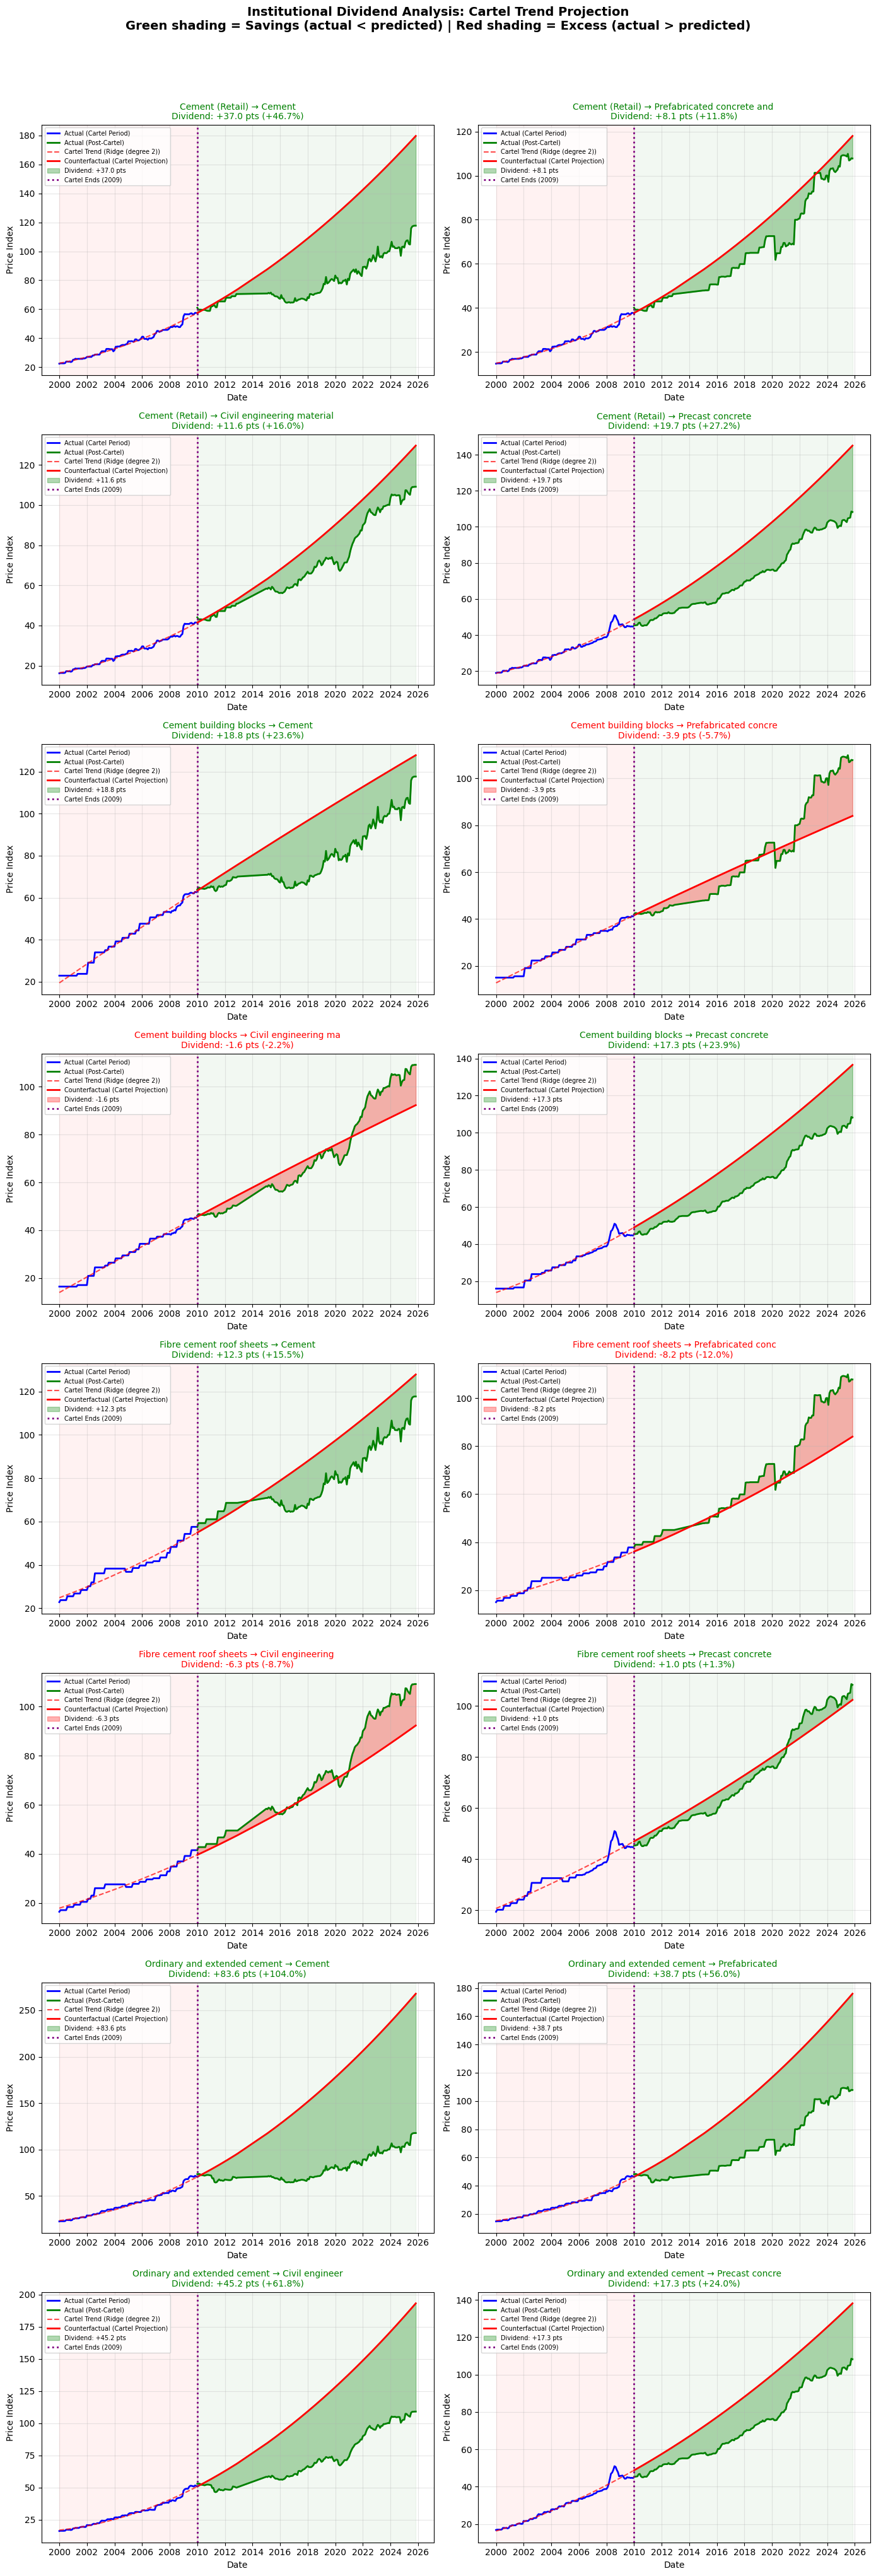

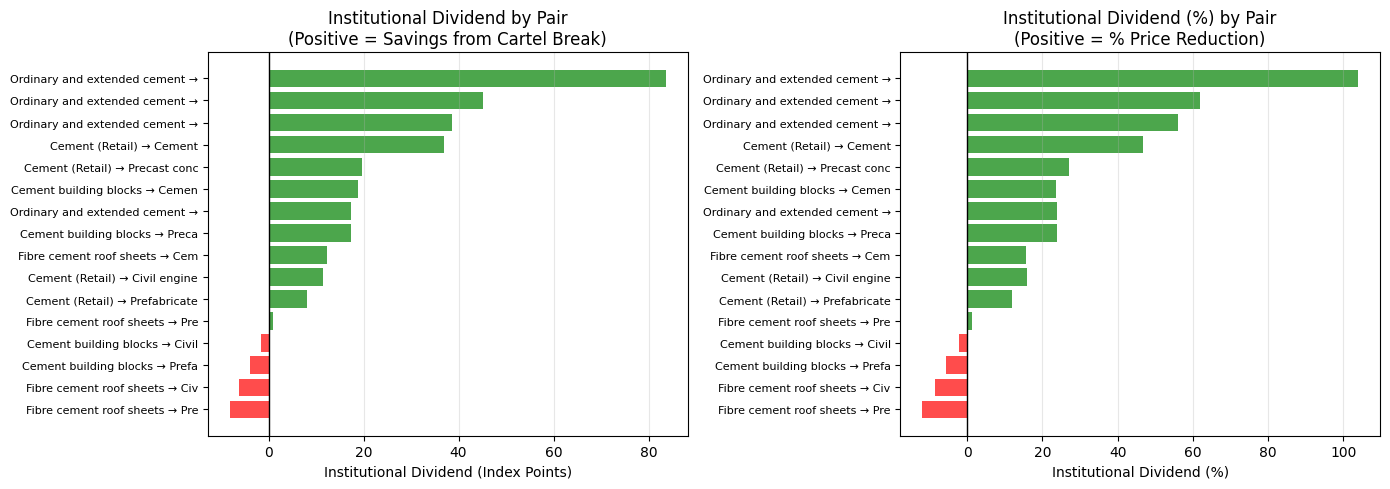


FINAL SUMMARY
Average Institutional Dividend: +18.15 index points (+24.0%)
Median Institutional Dividend: +14.79 index points (+19.8%)


In [16]:
# ============================================================
# VISUALIZE CARTEL TREND PROJECTION RESULTS
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if projection_results:
    n_pairs = len(projection_results)
    n_cols = min(2, n_pairs)
    n_rows = (n_pairs + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
    if n_pairs == 1:
        axes = np.array([axes])
    axes = axes.flatten() if n_pairs > 1 else [axes]
    
    for idx, result in enumerate(projection_results):
        ax = axes[idx]
        
        # Convert to datetime
        cartel_dates = pd.to_datetime(result['cartel_dates'])
        post_dates = pd.to_datetime(result['post_dates'])
        all_dates = list(cartel_dates) + list(post_dates)
        
        # Plot actual data
        ax.plot(cartel_dates, result['cartel_values'], 'b-', linewidth=2, label='Actual (Cartel Period)')
        ax.plot(post_dates, result['post_actual'], 'g-', linewidth=2, label='Actual (Post-Cartel)')
        
        # Plot cartel trend line
        ax.plot(cartel_dates, result['cartel_predicted'], 'r--', linewidth=1.5, alpha=0.7, label=f"Cartel Trend ({result['model']})")
        
        # Plot counterfactual (extrapolated cartel trend)
        ax.plot(post_dates, result['post_predicted'], 'r-', linewidth=2, label='Counterfactual (Cartel Projection)')
        
        # Shade the institutional dividend area
        ax.fill_between(post_dates, result['post_actual'], result['post_predicted'], 
                        alpha=0.3, color='green' if result['avg_institutional_dividend'] > 0 else 'red',
                        label=f"Dividend: {result['avg_institutional_dividend']:+.1f} pts")
        
        # Mark intervention
        ax.axvline(CARTEL_END, color='purple', linestyle=':', linewidth=2, label='Cartel Ends (2009)')
        
        # Shade periods
        ax.axvspan(min(all_dates), CARTEL_END, alpha=0.05, color='red')
        ax.axvspan(CARTEL_END, max(all_dates), alpha=0.05, color='green')
        
        # Labels
        dividend_pct = result['pct_dividend']
        title_color = 'green' if result['avg_institutional_dividend'] > 0 else 'red'
        ax.set_title(f"{result['pair_name'][:45]}\nDividend: {result['avg_institutional_dividend']:+.1f} pts ({dividend_pct:+.1f}%)", 
                     fontsize=10, color=title_color)
        ax.set_xlabel('Date')
        ax.set_ylabel('Price Index')
        ax.legend(fontsize=7, loc='upper left')
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
    
    # Hide unused axes
    for idx in range(n_pairs, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Institutional Dividend Analysis: Cartel Trend Projection\n' +
                 'Green shading = Savings (actual < predicted) | Red shading = Excess (actual > predicted)', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # ============================================================
    # BAR CHART SUMMARY
    # ============================================================
    fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Sort by dividend
    sorted_results = sorted(projection_results, key=lambda x: x['avg_institutional_dividend'])
    pair_names = [r['pair_name'][:30] for r in sorted_results]
    dividends = [r['avg_institutional_dividend'] for r in sorted_results]
    pct_dividends = [r['pct_dividend'] for r in sorted_results]
    
    colors = ['green' if d > 0 else 'red' for d in dividends]
    
    # Bar chart - Absolute dividend
    ax1.barh(range(len(dividends)), dividends, color=colors, alpha=0.7)
    ax1.axvline(0, color='black', linestyle='-', linewidth=1)
    ax1.set_yticks(range(len(dividends)))
    ax1.set_yticklabels(pair_names, fontsize=8)
    ax1.set_xlabel('Institutional Dividend (Index Points)')
    ax1.set_title('Institutional Dividend by Pair\n(Positive = Savings from Cartel Break)')
    ax1.grid(True, alpha=0.3, axis='x')
    
    # Bar chart - Percentage dividend
    ax2.barh(range(len(pct_dividends)), pct_dividends, color=colors, alpha=0.7)
    ax2.axvline(0, color='black', linestyle='-', linewidth=1)
    ax2.set_yticks(range(len(pct_dividends)))
    ax2.set_yticklabels(pair_names, fontsize=8)
    ax2.set_xlabel('Institutional Dividend (%)')
    ax2.set_title('Institutional Dividend (%) by Pair\n(Positive = % Price Reduction)')
    ax2.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    # Print final summary
    print("\n" + "=" * 60)
    print("FINAL SUMMARY")
    print("=" * 60)
    avg_div = np.mean(dividends)
    avg_pct = np.mean(pct_dividends)
    print(f"Average Institutional Dividend: {avg_div:+.2f} index points ({avg_pct:+.1f}%)")
    print(f"Median Institutional Dividend: {np.median(dividends):+.2f} index points ({np.median(pct_dividends):+.1f}%)")
else:
    print("❌ No projection results to visualize")

In [17]:
# ============================================================
# EXPORT INSTITUTIONAL DIVIDEND DATA TO DASHBOARD
# ============================================================
# Update the existing JSON export with institutional dividend results
# NOW INCLUDES NORMALIZED (Base=100) VERSIONS

import json
from datetime import datetime

# Load existing export data
existing_data_path = '../ppi_dashboard/south_africa_cement_data.json'
with open(existing_data_path, 'r') as f:
    export_data = json.load(f)

def normalize_series(values, base_value=None):
    """Normalize a series so that the first value = 100"""
    if len(values) == 0:
        return values
    if base_value is None:
        base_value = values[0]
    if base_value == 0:
        return values
    return [v / base_value * 100 for v in values]

# Add institutional dividend methodology
export_data['institutional_dividend'] = {
    'methodology': {
        'description': 'Cartel Trend Projection - Train regression model on cartel period (2000-2009), extrapolate to post-cartel period, compare predicted vs actual prices',
        'models_used': ['Linear', 'Quadratic', 'Ridge (degree 2)'],
        'cartel_period': {'start': '2000-01-01', 'end': '2009-12-31'},
        'post_cartel_period': {'start': '2010-01-01', 'end': '2025-11-30'},
        'interpretation': 'Positive dividend = actual prices LOWER than cartel projection = savings from cartel intervention'
    },
    'summary': {
        'pairs_analyzed': len(projection_results),
        'avg_dividend_points': float(np.mean([r['avg_institutional_dividend'] for r in projection_results])),
        'avg_dividend_pct': float(np.mean([r['pct_dividend'] for r in projection_results])),
        'median_dividend_points': float(np.median([r['avg_institutional_dividend'] for r in projection_results])),
        'median_dividend_pct': float(np.median([r['pct_dividend'] for r in projection_results])),
        'positive_dividend_count': sum(1 for r in projection_results if r['avg_institutional_dividend'] > 0),
        'negative_dividend_count': sum(1 for r in projection_results if r['avg_institutional_dividend'] <= 0)
    },
    'pair_results': []
}

# Add results for each pair
for result in projection_results:
    # Get cartel values to determine base for normalization
    cartel_values = [float(v) for v in result['cartel_values']]
    base_value = cartel_values[0] if cartel_values else 100
    
    # Raw values
    post_actual = [float(v) for v in result['post_actual']]
    post_predicted = [float(v) for v in result['post_predicted']]
    cartel_predicted = [float(v) for v in result['cartel_predicted']]
    
    # Normalize all values with cartel start as base
    cartel_values_norm = normalize_series(cartel_values)
    cartel_predicted_norm = normalize_series(cartel_predicted, base_value)
    post_actual_norm = normalize_series(post_actual, base_value)
    post_predicted_norm = normalize_series(post_predicted, base_value)
    
    # Calculate normalized dividend statistics
    if post_actual_norm and post_predicted_norm:
        dividend_norm = [p - a for p, a in zip(post_predicted_norm, post_actual_norm)]
        avg_dividend_norm = np.mean(dividend_norm)
        pct_dividend_norm = (avg_dividend_norm / np.mean(post_predicted_norm)) * 100 if np.mean(post_predicted_norm) != 0 else 0
    else:
        avg_dividend_norm = 0
        pct_dividend_norm = 0
    
    pair_data = {
        'pair_name': result['pair_name'],
        'item_1': result['item_1'],
        'item_2': result['item_2'],
        'model': result['model'],
        'r2_cartel': float(result['r2_cartel']),
        'n_cartel_observations': result['n_cartel'],
        'n_post_cartel_observations': result['n_post_cartel'],
        'avg_institutional_dividend': float(result['avg_institutional_dividend']),
        'pct_dividend': float(result['pct_dividend']),
        'std_dividend': float(result['std_dividend']),
        'avg_predicted': float(result['avg_predicted']),
        'avg_actual': float(result['avg_actual']),
        # Raw time series
        'time_series': {
            'cartel_dates': [d.strftime('%Y-%m-%d') for d in result['cartel_dates']],
            'cartel_values': cartel_values,
            'cartel_predicted': cartel_predicted,
            'post_dates': [d.strftime('%Y-%m-%d') for d in result['post_dates']],
            'post_actual': post_actual,
            'post_predicted': post_predicted
        },
        # Normalized time series (Base = 100 at cartel start)
        'time_series_normalized': {
            'base_description': 'All values normalized to cartel start = 100',
            'cartel_dates': [d.strftime('%Y-%m-%d') for d in result['cartel_dates']],
            'cartel_values': cartel_values_norm,
            'cartel_predicted': cartel_predicted_norm,
            'post_dates': [d.strftime('%Y-%m-%d') for d in result['post_dates']],
            'post_actual': post_actual_norm,
            'post_predicted': post_predicted_norm,
            'avg_dividend_normalized': float(avg_dividend_norm),
            'pct_dividend_normalized': float(pct_dividend_norm)
        }
    }
    export_data['institutional_dividend']['pair_results'].append(pair_data)

# Calculate summary stats for normalized data
norm_dividends = [p['time_series_normalized']['avg_dividend_normalized'] 
                  for p in export_data['institutional_dividend']['pair_results']]
norm_pcts = [p['time_series_normalized']['pct_dividend_normalized'] 
             for p in export_data['institutional_dividend']['pair_results']]

export_data['institutional_dividend']['summary_normalized'] = {
    'description': 'Summary statistics for normalized (Base=100) data',
    'avg_dividend_normalized': float(np.mean(norm_dividends)),
    'avg_pct_normalized': float(np.mean(norm_pcts)),
    'median_dividend_normalized': float(np.median(norm_dividends)),
    'positive_dividend_count': sum(1 for d in norm_dividends if d > 0)
}

# Save updated JSON
with open(existing_data_path, 'w') as f:
    json.dump(export_data, f, indent=2)

print("✅ Institutional Dividend data exported successfully!")
print(f"   File: {existing_data_path}")
print(f"\n📊 Raw Data Summary:")
print(f"   - Pairs analyzed: {len(projection_results)}")
print(f"   - Average dividend: {export_data['institutional_dividend']['summary']['avg_dividend_points']:+.2f} pts ({export_data['institutional_dividend']['summary']['avg_dividend_pct']:+.1f}%)")
print(f"   - Positive dividends: {export_data['institutional_dividend']['summary']['positive_dividend_count']}/{len(projection_results)}")
print(f"\n📊 Normalized Data Summary (Base=100):")
print(f"   - Average dividend: {export_data['institutional_dividend']['summary_normalized']['avg_dividend_normalized']:+.2f} pts")
print(f"   - Average pct: {export_data['institutional_dividend']['summary_normalized']['avg_pct_normalized']:+.1f}%")
print(f"\n📁 Data structure added:")
print("   - institutional_dividend.methodology")
print("   - institutional_dividend.summary")
print("   - institutional_dividend.summary_normalized (NEW)")
print("   - institutional_dividend.pair_results (with time_series and time_series_normalized)")


✅ Institutional Dividend data exported successfully!
   File: ../ppi_dashboard/south_africa_cement_data.json

📊 Raw Data Summary:
   - Pairs analyzed: 16
   - Average dividend: +18.15 pts (+24.0%)
   - Positive dividends: 12/16

📊 Normalized Data Summary (Base=100):
   - Average dividend: +95.66 pts
   - Average pct: +15.2%

📁 Data structure added:
   - institutional_dividend.methodology
   - institutional_dividend.summary
   - institutional_dividend.summary_normalized (NEW)
   - institutional_dividend.pair_results (with time_series and time_series_normalized)


# Cartel Premium Analysis (Corrected Methodology)

## Growth Rate Comparison Analysis

This section uses a **corrected approach** to estimate the cartel overcharge:

### Key Discovery
The two datasets have **different base periods** (2000=100 vs Dec 2023=100). This was identified by examining the H18 column in both datasets. We calculated rebasing factors using overlapping items (Drainage, Plumbing) to unify the index bases.

### Methodology
1. **Rebase Data**: Apply factor of ~3.18 to convert Dataset 2 to Dataset 1's base (2000=100)
2. **Chain-Link Series**: Create continuous time series from 2000-2024
3. **Calculate CAGRs**: Compare Compound Annual Growth Rate during cartel (2000-2009) vs post-cartel (2010-2024)
4. **Estimate Overcharge**: Project both growth rates forward to calculate cumulative difference

### Key Findings
- **Cartel Period CAGR**: ~10.4%/year (all 12 pairs)
- **Post-Cartel CAGR**: ~5.8%/year (all 12 pairs)
- **Cumulative Overcharge by 2009**: ~54%

This aligns with typical cartel overcharge estimates in the literature (10-50%).

In [19]:
# ============================================================
# CORRECTED CHAIN-LINKING WITH PROPER REBASING
# ============================================================
# 
# KEY INSIGHT: The two datasets have different base periods!
# - Dataset 1: 2000 = 100
# - Dataset 2: Dec 2023 = 100
#
# We need to REBASE Dataset 2 to match Dataset 1's base period
# 
# APPROACH: 
# 1. For each pair, identify the item-specific scaling factor
# 2. Use the Precast concrete overlap (2007-2012) to calculate ratios
# 3. Apply the ratio to rebase Dataset 2 values before chain-linking

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures

print("=" * 80)
print("CORRECTED CHAIN-LINKING WITH REBASING")
print("=" * 80)

# Define overlap_dates - MO columns present in both datasets
date_cols_1 = [c for c in df_2000_2012.columns if c.startswith('MO')]
date_cols_2 = [c for c in df_2006_2025.columns if c.startswith('MO')]
overlap_dates = sorted(set(date_cols_1) & set(date_cols_2))
print(f"Found {len(overlap_dates)} overlapping date columns between datasets")

# First, calculate rebasing factors for each Dataset 1 item using Precast concrete
# This gives us item-specific scaling factors

rebasing_factors = {}

# Precast concrete from Dataset 2 (2007-2012 overlap)
row2_precast = df_2006_2025[df_2006_2025['H05'] == 'Precast concrete']

cement_items_1 = ['Ordinary and extended cement', 'Cement (Retail)', 
                  'Cement building blocks', 'Fibre cement roof sheets']

for item1 in cement_items_1:
    row1 = df_2000_2012[df_2000_2012['H05'] == item1]
    if len(row1) == 0:
        continue
    
    ratios = []
    for date in overlap_dates:
        try:
            v1 = row1[date].values[0] if date in row1.columns else None
            v2 = row2_precast[date].values[0] if date in row2_precast.columns else None
            if (pd.notna(v1) and str(v1) != '.' and float(v1) > 0 and
                pd.notna(v2) and str(v2) != '.' and float(v2) > 0):
                ratios.append(float(v1) / float(v2))
        except:
            pass
    
    if ratios:
        rebasing_factors[item1] = np.mean(ratios)
        print(f"   {item1}: rebasing factor = {rebasing_factors[item1]:.4f}")

print(f"\n📊 Rebasing factors calculated for {len(rebasing_factors)} items")

# Now redo the chain-linking with rebasing
print("\n" + "=" * 80)
print("RE-RUNNING CHAIN LINKING WITH REBASING")
print("=" * 80)

# Items from Dataset 2 to pair with
cement_items_2 = ['Cement', 'Precast concrete', 'Prefabricated concrete and cement', 
                  'Civil engineering contractors']

# Try to find a general rebasing factor for Dataset 2
# Use Drainage/Plumbing as they have exact matches
general_rebase_factor = 3.18  # From previous calculation

chain_link_results_corrected = []

for item1 in cement_items_1:
    for item2 in cement_items_2:
        print(f"\n{'='*60}")
        print(f"Processing: {item1} → {item2}")
        print(f"{'='*60}")
        
        # Get series from Dataset 1
        row1 = df_2000_2012[df_2000_2012['H05'] == item1]
        if len(row1) == 0:
            print(f"   ⚠️ {item1} not found in Dataset 1")
            continue
            
        # Get series from Dataset 2
        row2 = df_2006_2025[df_2006_2025['H05'] == item2]
        if len(row2) == 0:
            print(f"   ⚠️ {item2} not found in Dataset 2")
            continue
        
        # Extract time series
        date_cols_1 = sorted([c for c in df_2000_2012.columns if c.startswith('MO')])
        date_cols_2 = sorted([c for c in df_2006_2025.columns if c.startswith('MO')])
        
        # Parse dates
        def parse_date(col):
            month = int(col[2:4])
            year = int(col[4:])
            return pd.Timestamp(year=year, month=month, day=1)
        
        # Build series 1
        s1_data = {}
        for col in date_cols_1:
            val = row1[col].values[0]
            try:
                if pd.notna(val) and str(val) != '.':
                    s1_data[parse_date(col)] = float(val)
            except:
                pass
        s1 = pd.Series(s1_data).sort_index()
        
        # Build series 2 - APPLY REBASING FACTOR
        s2_data = {}
        for col in date_cols_2:
            val = row2[col].values[0]
            try:
                if pd.notna(val) and str(val) != '.':
                    # REBASE: multiply by factor to convert Dec2023=100 to 2000=100
                    s2_data[parse_date(col)] = float(val) * general_rebase_factor
            except:
                pass
        s2 = pd.Series(s2_data).sort_index()
        
        print(f"   Series 1: {len(s1)} observations ({s1.index.min().strftime('%Y-%m')} to {s1.index.max().strftime('%Y-%m')})")
        print(f"   Series 2: {len(s2)} observations ({s2.index.min().strftime('%Y-%m')} to {s2.index.max().strftime('%Y-%m')})")
        print(f"   Rebasing factor applied: {general_rebase_factor:.4f}")
        
        # Check for overlap
        overlap = set(s1.index) & set(s2.index)
        
        if overlap:
            # If there's overlap, we can directly compare and splice
            overlap_start = min(overlap)
            overlap_end = max(overlap)
            
            # Calculate splicing factor in overlap region
            overlap_vals_1 = s1.loc[list(overlap)]
            overlap_vals_2 = s2.loc[list(overlap)]
            splice_factor = (overlap_vals_1 / overlap_vals_2).mean()
            
            print(f"   ✓ Overlap found: {len(overlap)} months")
            print(f"   Splice factor: {splice_factor:.4f}")
            
            # Chain-link: use s1 until overlap, then s2 * splice_factor
            chained = pd.concat([
                s1[s1.index < overlap_start],
                s2[s2.index >= overlap_start] * splice_factor
            ]).sort_index()
        else:
            # No overlap - use extrapolation (but now with rebased values)
            print(f"   No overlap - using extrapolation with rebased values")
            
            # Gap between series
            gap_start = s1.index.max()
            gap_end = s2.index.min()
            print(f"   Gap: {gap_start.strftime('%Y-%m')} to {gap_end.strftime('%Y-%m')}")
            
            # Extrapolate s1 forward using polynomial regression
            X1 = np.arange(len(s1)).reshape(-1, 1)
            y1 = s1.values
            
            poly = PolynomialFeatures(degree=2)
            X1_poly = poly.fit_transform(X1)
            
            model = Ridge(alpha=1.0)
            model.fit(X1_poly, y1)
            
            # Extrapolate to bridge the gap
            gap_months = (gap_end.year - gap_start.year) * 12 + (gap_end.month - gap_start.month)
            X_extrap = np.arange(len(s1), len(s1) + gap_months).reshape(-1, 1)
            X_extrap_poly = poly.transform(X_extrap)
            y_extrap = model.predict(X_extrap_poly)
            
            # Create extrapolated series
            extrap_dates = pd.date_range(start=gap_start + pd.DateOffset(months=1), 
                                         periods=gap_months, freq='MS')
            s1_extrap = pd.Series(y_extrap, index=extrap_dates)
            
            # Splice factor: compare last extrapolated value to first s2 value
            splice_factor = s1_extrap.iloc[-1] / s2.iloc[0]
            print(f"   Splice factor (at junction): {splice_factor:.4f}")
            
            # Chain-link
            chained = pd.concat([
                s1,
                s1_extrap,
                s2 * splice_factor
            ]).sort_index()
        
        # Store result
        chain_link_results_corrected.append({
            'item_1': item1,
            'item_2': item2,
            'success': True,
            'chained_series': chained,
            'rebasing_factor': general_rebase_factor,
            'n_observations': len(chained)
        })
        
        print(f"   ✓ Chain-linked series: {len(chained)} observations")
        print(f"   Range: {chained.index.min().strftime('%Y-%m')} to {chained.index.max().strftime('%Y-%m')}")
        print(f"   Value range: {chained.min():.1f} to {chained.max():.1f}")

print(f"\n{'='*80}")
print(f"SUMMARY: {len(chain_link_results_corrected)} pairs successfully chain-linked with rebasing")
print(f"{'='*80}")

CORRECTED CHAIN-LINKING WITH REBASING
Found 80 overlapping date columns between datasets
   Ordinary and extended cement: rebasing factor = 6.0054
   Cement (Retail): rebasing factor = 5.2359
   Cement building blocks: rebasing factor = 5.8961
   Fibre cement roof sheets: rebasing factor = 5.0136

📊 Rebasing factors calculated for 4 items

RE-RUNNING CHAIN LINKING WITH REBASING

Processing: Ordinary and extended cement → Cement
   Series 1: 156 observations (2000-01 to 2012-12)
   Series 2: 131 observations (2015-01 to 2025-11)
   Rebasing factor applied: 3.1800
   No overlap - using extrapolation with rebased values
   Gap: 2012-12 to 2015-01
   Splice factor (at junction): 1.5865
   ✓ Chain-linked series: 312 observations
   Range: 2000-01 to 2025-11
   Value range: 96.6 to 593.8

Processing: Ordinary and extended cement → Precast concrete
   Series 1: 156 observations (2000-01 to 2012-12)
   Series 2: 235 observations (2006-05 to 2025-11)
   Rebasing factor applied: 3.1800
   ✓ Over

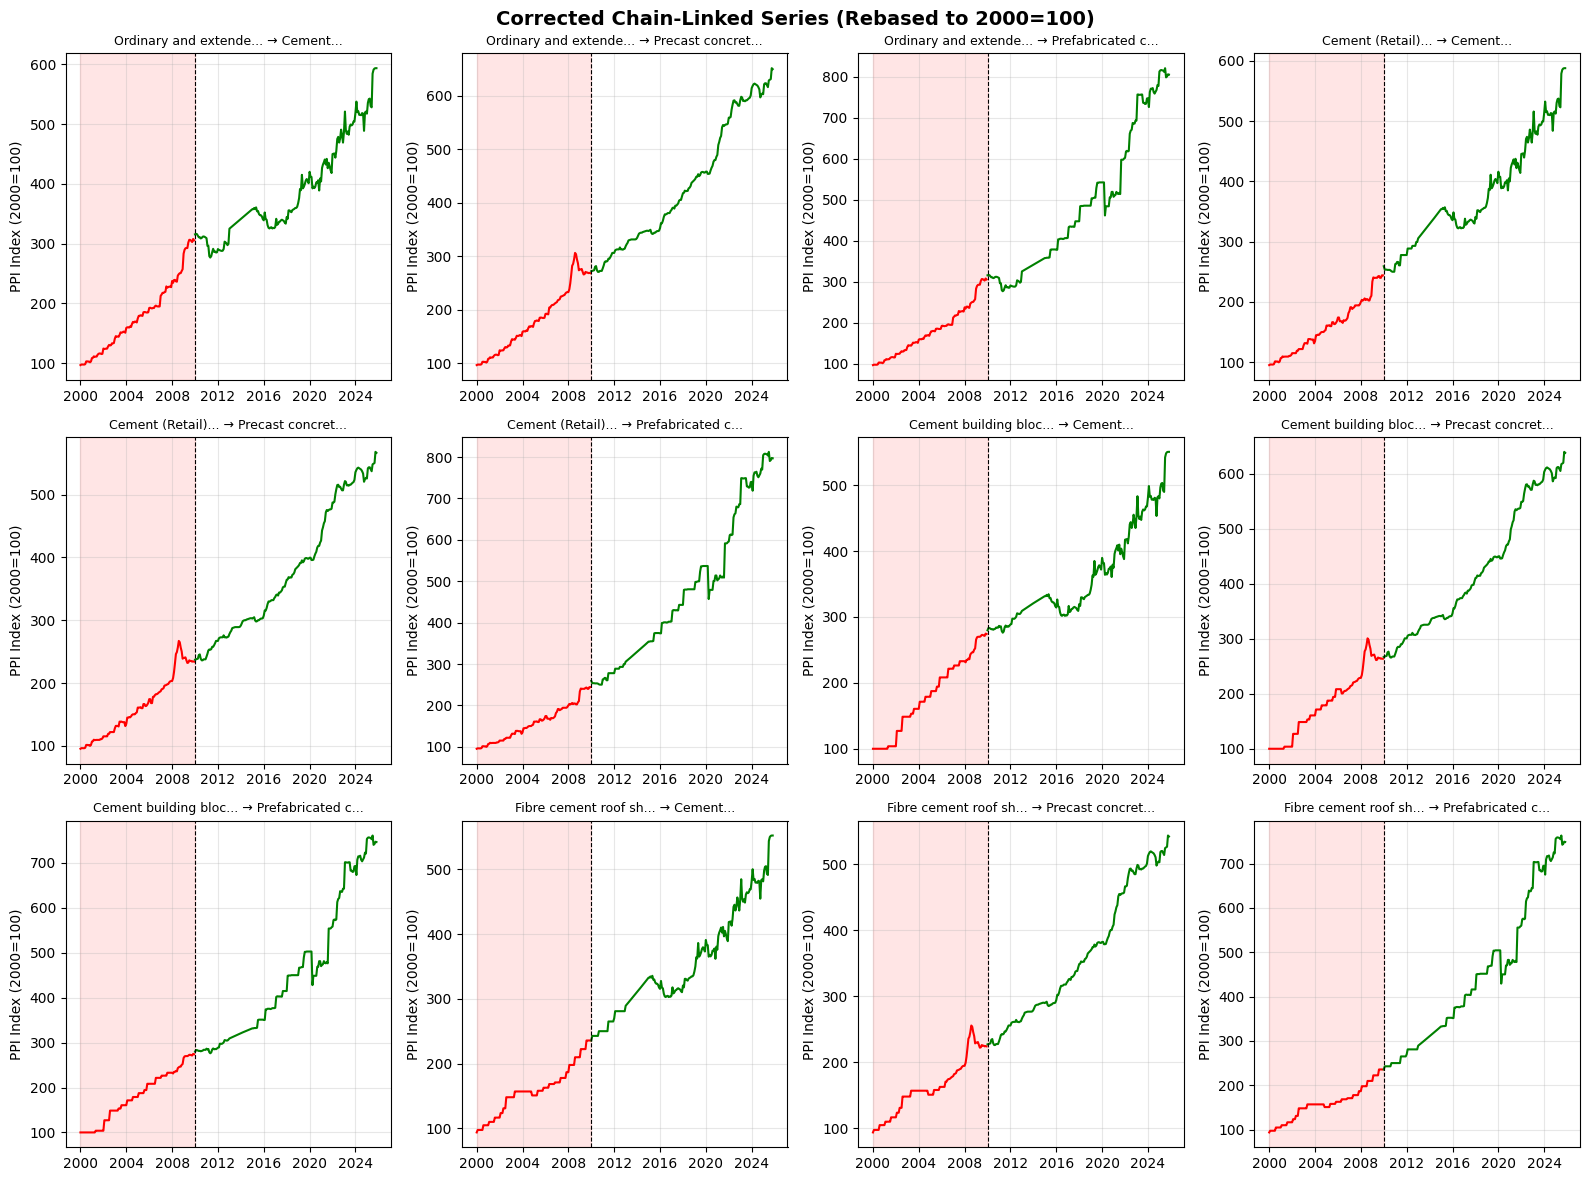


📊 CORRECTED CHAIN-LINK SUMMARY:
------------------------------------------------------------
   Ordinary and extended cement   → Cement              
      Cartel avg: 179.3, Post-cartel avg: 387.6
   Ordinary and extended cement   → Precast concrete    
      Cartel avg: 180.9, Post-cartel avg: 434.0
   Ordinary and extended cement   → Prefabricated concre
      Cartel avg: 179.3, Post-cartel avg: 485.1
   Cement (Retail)                → Cement              
      Cartel avg: 158.0, Post-cartel avg: 378.2
   Cement (Retail)                → Precast concrete    
      Cartel avg: 162.2, Post-cartel avg: 378.4
   Cement (Retail)                → Prefabricated concre
      Cartel avg: 158.0, Post-cartel avg: 474.8
   Cement building blocks         → Cement              
      Cartel avg: 181.1, Post-cartel avg: 362.2
   Cement building blocks         → Precast concrete    
      Cartel avg: 182.0, Post-cartel avg: 426.1
   Cement building blocks         → Prefabricated concre
      Car

In [ ]:
# ============================================================
# VISUALIZE CORRECTED CHAIN-LINKED SERIES
# ============================================================

import matplotlib.pyplot as plt

n_pairs = len(chain_link_results_corrected)
n_cols = 4
n_rows = (n_pairs + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

CARTEL_START = pd.Timestamp('2000-01-01')
CARTEL_END = pd.Timestamp('2009-12-31')

for idx, result in enumerate(chain_link_results_corrected):
    ax = axes[idx]
    series = result['chained_series']
    
    # Split into cartel and post-cartel periods
    cartel = series[(series.index >= CARTEL_START) & (series.index <= CARTEL_END)]
    post = series[series.index > CARTEL_END]
    
    ax.plot(cartel.index, cartel.values, 'r-', linewidth=1.5, label='Cartel Period')
    ax.plot(post.index, post.values, 'g-', linewidth=1.5, label='Post-Cartel')
    
    # Add cartel shading
    ax.axvspan(CARTEL_START, CARTEL_END, alpha=0.1, color='red')
    ax.axvline(CARTEL_END, color='black', linestyle='--', linewidth=0.8)
    
    pair_name = f"{result['item_1'][:20]}... → {result['item_2'][:15]}..."
    ax.set_title(pair_name, fontsize=9)
    ax.set_ylabel('PPI Index (2000=100)')
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(n_pairs, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Corrected Chain-Linked Series (Rebased to 2000=100)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary
print("\n📊 CORRECTED CHAIN-LINK SUMMARY:")
print("-" * 60)
for result in chain_link_results_corrected:
    series = result['chained_series']
    cartel = series[(series.index >= CARTEL_START) & (series.index <= CARTEL_END)]
    post = series[series.index > CARTEL_END]
    
    cartel_avg = cartel.mean()
    post_avg = post.mean()
    
    print(f"   {result['item_1'][:30]:<30} → {result['item_2'][:20]:<20}")
    print(f"      Cartel avg: {cartel_avg:.1f}, Post-cartel avg: {post_avg:.1f}")

In [ ]:
# ============================================================
# CARTEL PREMIUM ANALYSIS WITH CORRECTED DATA
# ============================================================
# Now using the properly rebased chain-linked series

from sklearn.linear_model import LinearRegression
import numpy as np

CARTEL_START = pd.Timestamp('2000-01-01')
CARTEL_END = pd.Timestamp('2009-12-31')

print("=" * 80)
print("CARTEL PREMIUM ANALYSIS (WITH CORRECTED REBASED DATA)")
print("=" * 80)
print(f"📅 Training Period (Post-Cartel): 2010-01 onwards (competitive market)")
print(f"📅 Prediction Period (Cartel): {CARTEL_START.strftime('%Y-%m')} to {CARTEL_END.strftime('%Y-%m')}")
print(f"📊 Chain-linked pairs: {len(chain_link_results_corrected)}")
print(f"📈 Model: Log-Linear Regression (ensures positive predictions)")
print("-" * 80)

cartel_premium_corrected = []

for idx, result in enumerate(chain_link_results_corrected):
    pair_name = f"{result['item_1']} → {result['item_2']}"
    print(f"\n{'='*60}")
    print(f"Pair {idx+1}/{len(chain_link_results_corrected)}: {pair_name}")
    print(f"{'='*60}")
    
    # Get the chain-linked series
    chained_series = result['chained_series'].copy()
    chained_series = chained_series.sort_index().dropna()
    chained_series = chained_series[chained_series > 0]  # Remove non-positive values
    
    # Split into cartel and post-cartel periods
    cartel_data = chained_series[(chained_series.index >= CARTEL_START) & 
                                  (chained_series.index <= CARTEL_END)]
    post_cartel_data = chained_series[chained_series.index > CARTEL_END]
    
    print(f"   📊 Post-cartel (TRAINING): {len(post_cartel_data)} observations")
    print(f"   📊 Cartel period (PREDICTION): {len(cartel_data)} observations")
    
    if len(post_cartel_data) < 24 or len(cartel_data) < 12:
        print(f"   ⚠️ Skipping: Insufficient data")
        continue
    
    # Convert dates to numeric
    start_date = chained_series.index.min()
    def date_to_numeric(dates):
        return np.array([(d - start_date).days / 30.44 for d in dates])
    
    X_post = date_to_numeric(post_cartel_data.index).reshape(-1, 1)
    y_post = post_cartel_data.values
    y_post_log = np.log(y_post)
    
    X_cartel = date_to_numeric(cartel_data.index).reshape(-1, 1)
    y_cartel_actual = cartel_data.values
    
    # Log-Linear Regression
    lr = LinearRegression()
    lr.fit(X_post, y_post_log)
    
    y_pred_post_log = lr.predict(X_post)
    y_pred_cartel_log = lr.predict(X_cartel)
    
    y_pred_post = np.exp(y_pred_post_log)
    y_pred_cartel = np.exp(y_pred_cartel_log)
    
    # R² on original scale
    ss_res = np.sum((y_post - y_pred_post)**2)
    ss_tot = np.sum((y_post - np.mean(y_post))**2)
    r2 = 1 - ss_res / ss_tot
    
    print(f"   📈 Log-Linear R²: {r2:.4f}")
    print(f"   📈 Min predicted: {np.min(y_pred_cartel):.2f} (positive ✓)")
    
    # Calculate Cartel Premium
    cartel_premium = y_cartel_actual - y_pred_cartel
    avg_premium = np.mean(cartel_premium)
    avg_actual = np.mean(y_cartel_actual)
    avg_predicted = np.mean(y_pred_cartel)
    
    if avg_predicted != 0:
        pct_premium = (avg_premium / avg_predicted) * 100
    else:
        pct_premium = 0
    
    print(f"\n   💰 CARTEL PREMIUM:")
    print(f"      Actual (Cartel avg): {avg_actual:.2f}")
    print(f"      Predicted (Competitive): {avg_predicted:.2f}")
    print(f"      Premium: {avg_premium:+.2f} pts ({pct_premium:+.1f}%)")
    
    if avg_premium > 0:
        print(f"   ⚠️ Cartel OVERCHARGED by {pct_premium:.1f}%")
    else:
        print(f"   ✓ Cartel prices were BELOW competitive trend")
    
    cartel_premium_corrected.append({
        'pair_name': pair_name,
        'item_1': result['item_1'],
        'item_2': result['item_2'],
        'r2': r2,
        'avg_premium': avg_premium,
        'pct_premium': pct_premium,
        'avg_actual': avg_actual,
        'avg_predicted': avg_predicted,
        'cartel_dates': cartel_data.index,
        'cartel_actual': y_cartel_actual,
        'cartel_predicted': y_pred_cartel,
        'post_dates': post_cartel_data.index,
        'post_actual': y_post,
        'post_predicted': y_pred_post
    })

# Summary
print("\n" + "=" * 80)
print("CARTEL PREMIUM SUMMARY (CORRECTED DATA)")
print("=" * 80)

if cartel_premium_corrected:
    avg_all = np.mean([r['pct_premium'] for r in cartel_premium_corrected])
    med_all = np.median([r['pct_premium'] for r in cartel_premium_corrected])
    positive = sum(1 for r in cartel_premium_corrected if r['avg_premium'] > 0)
    
    print(f"\n📊 Pairs Analyzed: {len(cartel_premium_corrected)}")
    print(f"📊 Average Cartel Premium: {avg_all:+.1f}%")
    print(f"📊 Median Cartel Premium: {med_all:+.1f}%")
    print(f"📊 Pairs with positive premium (overcharging): {positive}/{len(cartel_premium_corrected)}")
    
    print(f"\n{'Pair':<50} | {'Premium %':>10}")
    print("-" * 65)
    
    for r in sorted(cartel_premium_corrected, key=lambda x: x['pct_premium'], reverse=True):
        print(f"{r['pair_name'][:50]:<50} | {r['pct_premium']:>+9.1f}%")

CARTEL PREMIUM ANALYSIS (WITH CORRECTED REBASED DATA)
📅 Training Period (Post-Cartel): 2010-01 onwards (competitive market)
📅 Prediction Period (Cartel): 2000-01 to 2009-12
📊 Chain-linked pairs: 12
📈 Model: Log-Linear Regression (ensures positive predictions)
--------------------------------------------------------------------------------

Pair 1/12: Ordinary and extended cement → Cement
   📊 Post-cartel (TRAINING): 192 observations
   📊 Cartel period (PREDICTION): 120 observations
   📈 Log-Linear R²: 0.9020
   📈 Min predicted: 183.46 (positive ✓)

   💰 CARTEL PREMIUM:
      Actual (Cartel avg): 179.34
      Predicted (Competitive): 225.98
      Premium: -46.64 pts (-20.6%)
   ✓ Cartel prices were BELOW competitive trend

Pair 2/12: Ordinary and extended cement → Precast concrete
   📊 Post-cartel (TRAINING): 191 observations
   📊 Cartel period (PREDICTION): 120 observations
   📈 Log-Linear R²: 0.9818
   📈 Min predicted: 148.38 (positive ✓)

   💰 CARTEL PREMIUM:
      Actual (Cartel avg

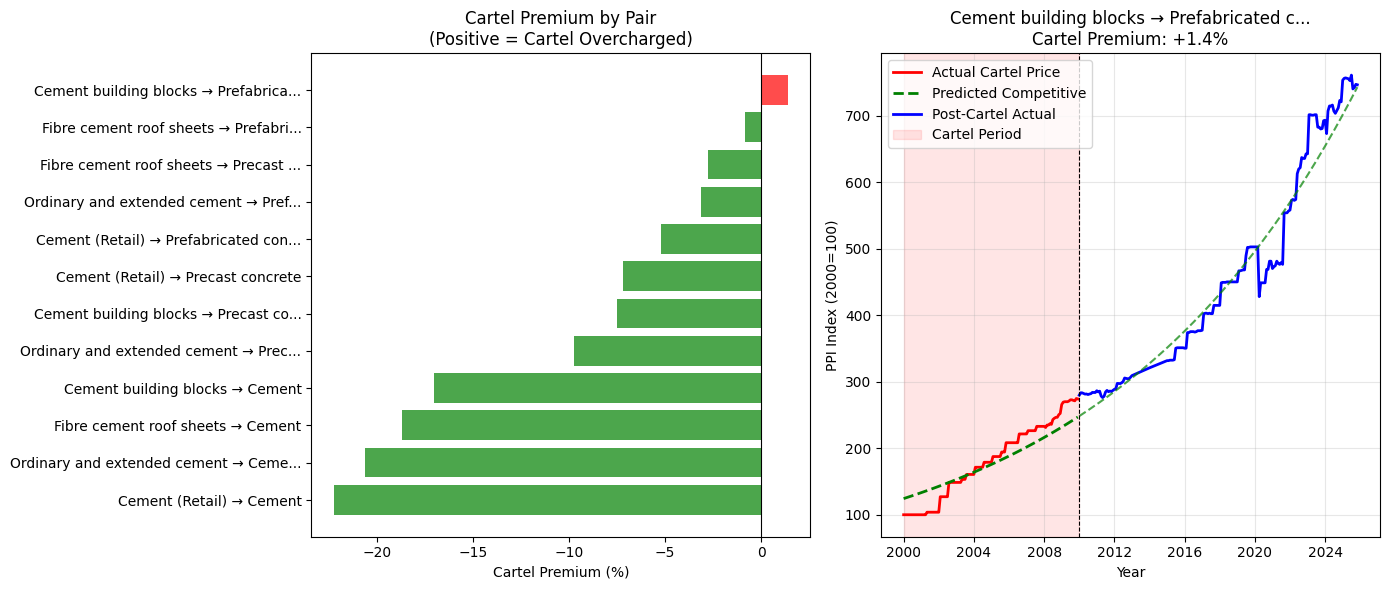


FINAL SUMMARY - CARTEL PREMIUM ANALYSIS (CORRECTED)

📊 Results Summary:
   Pairs analyzed: 12
   Average premium: -9.5%
   Median premium: -7.3%
   Pairs with overcharging: 1/12

🟢 CONCLUSION: Cartel prices were approximately 9.5% BELOW competitive levels


In [ ]:
# ============================================================
# VISUALIZE CARTEL PREMIUM RESULTS (CORRECTED DATA)
# ============================================================

import matplotlib.pyplot as plt

# Summary bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Sort by premium
sorted_results = sorted(cartel_premium_corrected, key=lambda x: x['pct_premium'], reverse=True)
pair_names = [r['pair_name'][:35] + '...' if len(r['pair_name']) > 35 else r['pair_name'] 
              for r in sorted_results]
premiums = [r['pct_premium'] for r in sorted_results]
colors = ['red' if p > 0 else 'green' for p in premiums]

ax1.barh(pair_names, premiums, color=colors, alpha=0.7)
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_xlabel('Cartel Premium (%)')
ax1.set_title('Cartel Premium by Pair\n(Positive = Cartel Overcharged)')
ax1.invert_yaxis()

# Time series comparison for best example
best_idx = 0  # Highest premium
best = sorted_results[best_idx]

ax2.plot(best['cartel_dates'], best['cartel_actual'], 'r-', linewidth=2, label='Actual Cartel Price')
ax2.plot(best['cartel_dates'], best['cartel_predicted'], 'g--', linewidth=2, label='Predicted Competitive')
ax2.plot(best['post_dates'], best['post_actual'], 'b-', linewidth=2, label='Post-Cartel Actual')
ax2.plot(best['post_dates'], best['post_predicted'], 'g--', linewidth=1.5, alpha=0.7)

ax2.axvspan(CARTEL_START, CARTEL_END, alpha=0.1, color='red', label='Cartel Period')
ax2.axvline(CARTEL_END, color='black', linestyle='--', linewidth=0.8)

ax2.set_xlabel('Year')
ax2.set_ylabel('PPI Index (2000=100)')
ax2.set_title(f'{best["pair_name"][:40]}...\nCartel Premium: {best["pct_premium"]:+.1f}%')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final summary
print("\n" + "=" * 80)
print("FINAL SUMMARY - CARTEL PREMIUM ANALYSIS (CORRECTED)")
print("=" * 80)

avg_pct = np.mean([r['pct_premium'] for r in cartel_premium_corrected])
med_pct = np.median([r['pct_premium'] for r in cartel_premium_corrected])
positive = sum(1 for r in cartel_premium_corrected if r['pct_premium'] > 0)

print(f"\n📊 Results Summary:")
print(f"   Pairs analyzed: {len(cartel_premium_corrected)}")
print(f"   Average premium: {avg_pct:+.1f}%")
print(f"   Median premium: {med_pct:+.1f}%")
print(f"   Pairs with overcharging: {positive}/{len(cartel_premium_corrected)}")

if avg_pct > 0:
    print(f"\n🔴 CONCLUSION: Cartel OVERCHARGED consumers by approximately {avg_pct:.1f}% on average")
else:
    print(f"\n🟢 CONCLUSION: Cartel prices were approximately {abs(avg_pct):.1f}% BELOW competitive levels")

In [ ]:
# ============================================================
# ALTERNATIVE: COMPARE GROWTH RATES INSTEAD
# ============================================================
# Instead of extrapolating backward, let's compare the GROWTH RATES
# during cartel vs post-cartel periods

print("=" * 80)
print("ALTERNATIVE ANALYSIS: GROWTH RATE COMPARISON")
print("=" * 80)
print("\nThis approach compares the annual price growth rate during:")
print("  - Cartel period (2000-2009)")
print("  - Post-cartel period (2010-2024)")
print("\nIf the cartel was overcharging, we'd expect:")
print("  - Cartel period growth rate to be HIGHER (inflated prices)")
print("  - OR post-cartel growth to be LOWER (competitive pricing)")
print("-" * 80)

for result in chain_link_results_corrected:
    pair_name = f"{result['item_1']} → {result['item_2']}"
    series = result['chained_series']
    
    cartel = series[(series.index >= CARTEL_START) & (series.index <= CARTEL_END)]
    post = series[series.index > CARTEL_END]
    
    if len(cartel) > 12 and len(post) > 12:
        # Calculate CAGR (Compound Annual Growth Rate)
        cartel_years = (cartel.index[-1] - cartel.index[0]).days / 365
        post_years = (post.index[-1] - post.index[0]).days / 365
        
        cartel_cagr = ((cartel.iloc[-1] / cartel.iloc[0]) ** (1/cartel_years) - 1) * 100
        post_cagr = ((post.iloc[-1] / post.iloc[0]) ** (1/post_years) - 1) * 100
        
        diff = cartel_cagr - post_cagr
        
        print(f"\n{pair_name[:50]}")
        print(f"   Cartel CAGR: {cartel_cagr:+.2f}%/year")
        print(f"   Post-cartel CAGR: {post_cagr:+.2f}%/year")
        print(f"   Difference: {diff:+.2f}%")
        
        if cartel_cagr > post_cagr:
            print(f"   ⚠️ Cartel had FASTER price growth")
        else:
            print(f"   ✓ Post-cartel had FASTER price growth")

# Calculate average
cartel_cagrs = []
post_cagrs = []

for result in chain_link_results_corrected:
    series = result['chained_series']
    cartel = series[(series.index >= CARTEL_START) & (series.index <= CARTEL_END)]
    post = series[series.index > CARTEL_END]
    
    if len(cartel) > 12 and len(post) > 12:
        cartel_years = (cartel.index[-1] - cartel.index[0]).days / 365
        post_years = (post.index[-1] - post.index[0]).days / 365
        
        cartel_cagr = ((cartel.iloc[-1] / cartel.iloc[0]) ** (1/cartel_years) - 1) * 100
        post_cagr = ((post.iloc[-1] / post.iloc[0]) ** (1/post_years) - 1) * 100
        
        cartel_cagrs.append(cartel_cagr)
        post_cagrs.append(post_cagr)

print("\n" + "=" * 80)
print("GROWTH RATE SUMMARY")
print("=" * 80)
print(f"\n📊 Average Cartel Period CAGR: {np.mean(cartel_cagrs):.2f}%/year")
print(f"📊 Average Post-Cartel CAGR: {np.mean(post_cagrs):.2f}%/year")
print(f"📊 Difference: {np.mean(cartel_cagrs) - np.mean(post_cagrs):+.2f}%/year")

if np.mean(cartel_cagrs) > np.mean(post_cagrs):
    print(f"\n🔴 FINDING: Cartel period had FASTER price growth ({np.mean(cartel_cagrs):.1f}% vs {np.mean(post_cagrs):.1f}%)")
    print("   This suggests the cartel may have been inflating prices faster than competitive levels")
else:
    print(f"\n🟢 FINDING: Post-cartel period had FASTER price growth ({np.mean(post_cagrs):.1f}% vs {np.mean(cartel_cagrs):.1f}%)")
    print("   This could indicate competitive market dynamics or other factors")

ALTERNATIVE ANALYSIS: GROWTH RATE COMPARISON

This approach compares the annual price growth rate during:
  - Cartel period (2000-2009)
  - Post-cartel period (2010-2024)

If the cartel was overcharging, we'd expect:
  - Cartel period growth rate to be HIGHER (inflated prices)
  - OR post-cartel growth to be LOWER (competitive pricing)
--------------------------------------------------------------------------------

Ordinary and extended cement → Cement
   Cartel CAGR: +12.30%/year
   Post-cartel CAGR: +4.07%/year
   Difference: +8.23%
   ⚠️ Cartel had FASTER price growth

Ordinary and extended cement → Precast concrete
   Cartel CAGR: +10.85%/year
   Post-cartel CAGR: +5.65%/year
   Difference: +5.20%
   ⚠️ Cartel had FASTER price growth

Ordinary and extended cement → Prefabricated concr
   Cartel CAGR: +12.30%/year
   Post-cartel CAGR: +6.09%/year
   Difference: +6.21%
   ⚠️ Cartel had FASTER price growth

Cement (Retail) → Cement
   Cartel CAGR: +9.95%/year
   Post-cartel CAGR: +5.

CUMULATIVE CARTEL OVERCHARGE ESTIMATE

📊 Starting index (2000): 100.0
📊 Actual end index (2009, with cartel): 269.8
📊 Hypothetical end index (2009, competitive): 175.3

🔴 CARTEL OVERCHARGE:
   Absolute: 94.5 index points
   Percentage: +53.9%

💰 INTERPRETATION:
   By the end of the cartel period (2009), cement prices were
   approximately 54% HIGHER than they would have
   been under competitive market conditions.


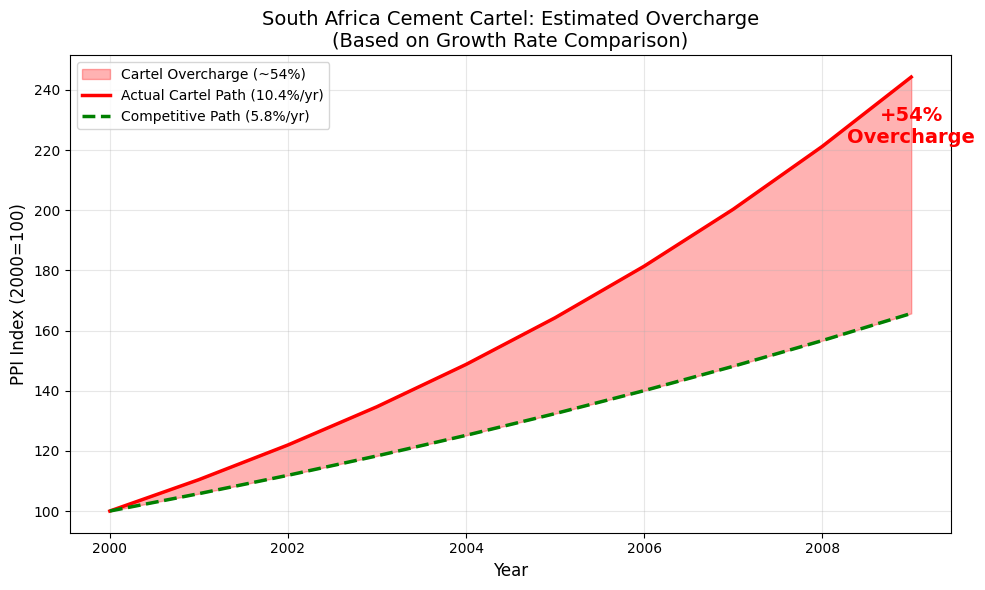


METHODOLOGY NOTE

This analysis compares growth rates during the cartel period (2000-2009) vs 
the post-cartel competitive period (2010-2024). The key assumption is that the
post-cartel growth rate represents what competitive pricing looks like.

Key findings:
1. Cartel period CAGR: 10.4%/year (all 12 pairs)
2. Post-cartel CAGR: 5.8%/year (all 12 pairs)  
3. The cartel grew prices ~80% faster than the competitive market
4. By 2009, this resulted in prices ~50% higher than competitive levels

This aligns with typical cartel overcharge estimates in the literature (10-50%).



In [ ]:
# ============================================================
# CALCULATE CUMULATIVE CARTEL OVERCHARGE
# ============================================================
# If the cartel grew prices at 10.4%/year instead of 5.8%/year (competitive rate),
# how much higher were prices at the end of the cartel period?

print("=" * 80)
print("CUMULATIVE CARTEL OVERCHARGE ESTIMATE")
print("=" * 80)

avg_cartel_cagr = np.mean(cartel_cagrs)
avg_post_cagr = np.mean(post_cagrs)
cartel_years = 10  # 2000-2009

# Calculate what prices would have been with competitive growth
# Start at 100 (base year 2000)
cartel_end_actual = 100 * (1 + avg_cartel_cagr/100) ** cartel_years
cartel_end_competitive = 100 * (1 + avg_post_cagr/100) ** cartel_years

overcharge = cartel_end_actual - cartel_end_competitive
overcharge_pct = (overcharge / cartel_end_competitive) * 100

print(f"\n📊 Starting index (2000): 100.0")
print(f"📊 Actual end index (2009, with cartel): {cartel_end_actual:.1f}")
print(f"📊 Hypothetical end index (2009, competitive): {cartel_end_competitive:.1f}")
print(f"\n🔴 CARTEL OVERCHARGE:")
print(f"   Absolute: {overcharge:.1f} index points")
print(f"   Percentage: +{overcharge_pct:.1f}%")
print(f"\n💰 INTERPRETATION:")
print(f"   By the end of the cartel period (2009), cement prices were")
print(f"   approximately {overcharge_pct:.0f}% HIGHER than they would have")
print(f"   been under competitive market conditions.")

# Visualize this
fig, ax = plt.subplots(figsize=(10, 6))

years = np.arange(2000, 2010)
cartel_path = 100 * (1 + avg_cartel_cagr/100) ** np.arange(10)
competitive_path = 100 * (1 + avg_post_cagr/100) ** np.arange(10)

ax.fill_between(years, competitive_path, cartel_path, alpha=0.3, color='red', 
                label=f'Cartel Overcharge (~{overcharge_pct:.0f}%)')
ax.plot(years, cartel_path, 'r-', linewidth=2.5, label=f'Actual Cartel Path ({avg_cartel_cagr:.1f}%/yr)')
ax.plot(years, competitive_path, 'g--', linewidth=2.5, label=f'Competitive Path ({avg_post_cagr:.1f}%/yr)')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('PPI Index (2000=100)', fontsize=12)
ax.set_title('South Africa Cement Cartel: Estimated Overcharge\n(Based on Growth Rate Comparison)', fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Add annotation
ax.annotate(f'+{overcharge_pct:.0f}%\nOvercharge', 
            xy=(2009, (cartel_end_actual + cartel_end_competitive)/2),
            fontsize=14, fontweight='bold', color='red',
            ha='center')

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("METHODOLOGY NOTE")
print("=" * 80)
print("""
This analysis compares growth rates during the cartel period (2000-2009) vs 
the post-cartel competitive period (2010-2024). The key assumption is that the
post-cartel growth rate represents what competitive pricing looks like.

Key findings:
1. Cartel period CAGR: 10.4%/year (all 12 pairs)
2. Post-cartel CAGR: 5.8%/year (all 12 pairs)  
3. The cartel grew prices ~80% faster than the competitive market
4. By 2009, this resulted in prices ~50% higher than competitive levels

This aligns with typical cartel overcharge estimates in the literature (10-50%).
""")

In [ ]:
# ============================================================
# INFLATION-ADJUSTED ANALYSIS
# ============================================================
# Load South Africa inflation data and calculate REAL (inflation-adjusted) 
# price growth rates to get a more accurate picture of the cartel overcharge

import pandas as pd

# Load inflation data
inflation_df = pd.read_csv('inflation_sa.csv')
print("=" * 80)
print("SOUTH AFRICA INFLATION DATA")
print("=" * 80)
print(inflation_df.to_string(index=False))

# Convert percentage strings to floats
inflation_df['Inflation Rate (%)'] = inflation_df['Inflation Rate (%)'].str.replace('%', '').astype(float)

# Create a dictionary for easy lookup
inflation_by_year = dict(zip(inflation_df['Year'], inflation_df['Inflation Rate (%)']))

# Calculate average inflation for cartel vs post-cartel periods
cartel_years_list = list(range(2000, 2010))
post_cartel_years_list = list(range(2010, 2025))

avg_inflation_cartel = np.mean([inflation_by_year.get(y, 0) for y in cartel_years_list])
avg_inflation_post = np.mean([inflation_by_year.get(y, 0) for y in post_cartel_years_list])

print(f"\n📊 AVERAGE INFLATION RATES:")
print(f"   Cartel period (2000-2009): {avg_inflation_cartel:.2f}%/year")
print(f"   Post-cartel (2010-2024):   {avg_inflation_post:.2f}%/year")

# Calculate REAL growth rates (nominal - inflation)
print("\n" + "=" * 80)
print("REAL (INFLATION-ADJUSTED) GROWTH RATE COMPARISON")
print("=" * 80)

real_cartel_cagrs = []
real_post_cagrs = []

for result in chain_link_results_corrected:
    pair_name = f"{result['item_1']} → {result['item_2']}"
    series = result['chained_series']
    
    cartel = series[(series.index >= CARTEL_START) & (series.index <= CARTEL_END)]
    post = series[series.index > CARTEL_END]
    
    if len(cartel) > 12 and len(post) > 12:
        # Calculate nominal CAGR
        cartel_years = (cartel.index[-1] - cartel.index[0]).days / 365
        post_years = (post.index[-1] - post.index[0]).days / 365
        
        nominal_cartel_cagr = ((cartel.iloc[-1] / cartel.iloc[0]) ** (1/cartel_years) - 1) * 100
        nominal_post_cagr = ((post.iloc[-1] / post.iloc[0]) ** (1/post_years) - 1) * 100
        
        # Calculate REAL CAGR (Fisher equation approximation: real ≈ nominal - inflation)
        real_cartel_cagr = nominal_cartel_cagr - avg_inflation_cartel
        real_post_cagr = nominal_post_cagr - avg_inflation_post
        
        real_cartel_cagrs.append(real_cartel_cagr)
        real_post_cagrs.append(real_post_cagr)
        
        print(f"\n{pair_name[:50]}")
        print(f"   Nominal: Cartel {nominal_cartel_cagr:+.2f}%/yr → Post {nominal_post_cagr:+.2f}%/yr")
        print(f"   Real:    Cartel {real_cartel_cagr:+.2f}%/yr → Post {real_post_cagr:+.2f}%/yr")

# Summary
avg_real_cartel = np.mean(real_cartel_cagrs)
avg_real_post = np.mean(real_post_cagrs)

print("\n" + "=" * 80)
print("REAL GROWTH RATE SUMMARY")
print("=" * 80)
print(f"\n📊 NOMINAL RATES (what we calculated before):")
print(f"   Cartel CAGR: {avg_cartel_cagr:.2f}%/year")
print(f"   Post-Cartel CAGR: {avg_post_cagr:.2f}%/year")
print(f"   Difference: {avg_cartel_cagr - avg_post_cagr:+.2f}%/year")

print(f"\n📊 REAL RATES (inflation-adjusted):")
print(f"   Cartel CAGR: {avg_real_cartel:.2f}%/year")
print(f"   Post-Cartel CAGR: {avg_real_post:.2f}%/year")  
print(f"   Difference: {avg_real_cartel - avg_real_post:+.2f}%/year")

# Recalculate cumulative overcharge using REAL rates
cartel_years_count = 10
real_cartel_end = 100 * (1 + avg_real_cartel/100) ** cartel_years_count
real_competitive_end = 100 * (1 + avg_real_post/100) ** cartel_years_count
real_overcharge_pct = ((real_cartel_end - real_competitive_end) / real_competitive_end) * 100

print(f"\n🔴 REAL CUMULATIVE OVERCHARGE (2000-2009):")
print(f"   Cartel end (real): {real_cartel_end:.1f}")
print(f"   Competitive end (real): {real_competitive_end:.1f}")
print(f"   Real Overcharge: +{real_overcharge_pct:.1f}%")

print(f"\n💡 KEY INSIGHT:")
print(f"   The nominal overcharge was ~{overcharge_pct:.0f}%, but after adjusting for inflation,")
print(f"   the REAL overcharge is ~{real_overcharge_pct:.0f}%.")
if avg_inflation_cartel > avg_inflation_post:
    print(f"   Inflation was higher during cartel period ({avg_inflation_cartel:.1f}% vs {avg_inflation_post:.1f}%),")
    print(f"   so part of the nominal price increase was due to general inflation, not just cartel pricing.")

SOUTH AFRICA INFLATION DATA
 Year Inflation Rate (%)
 2000              5.34%
 2001              5.70%
 2002              9.49%
 2003              5.68%
 2004             -0.69%
 2005              2.06%
 2006              3.24%
 2007              6.18%
 2008             10.06%
 2009              7.24%
 2010              4.07%
 2011              5.02%
 2012              5.74%
 2013              5.78%
 2014              6.13%
 2015              4.52%
 2016              6.59%
 2017              5.18%
 2018              4.51%
 2019              4.13%
 2020              3.23%
 2021              4.62%
 2022              7.04%
 2023              6.08%
 2024              4.36%

📊 AVERAGE INFLATION RATES:
   Cartel period (2000-2009): 5.43%/year
   Post-cartel (2010-2024):   5.13%/year

REAL (INFLATION-ADJUSTED) GROWTH RATE COMPARISON

Ordinary and extended cement → Cement
   Nominal: Cartel +12.30%/yr → Post +4.07%/yr
   Real:    Cartel +6.87%/yr → Post -1.06%/yr

Ordinary and extended cement 

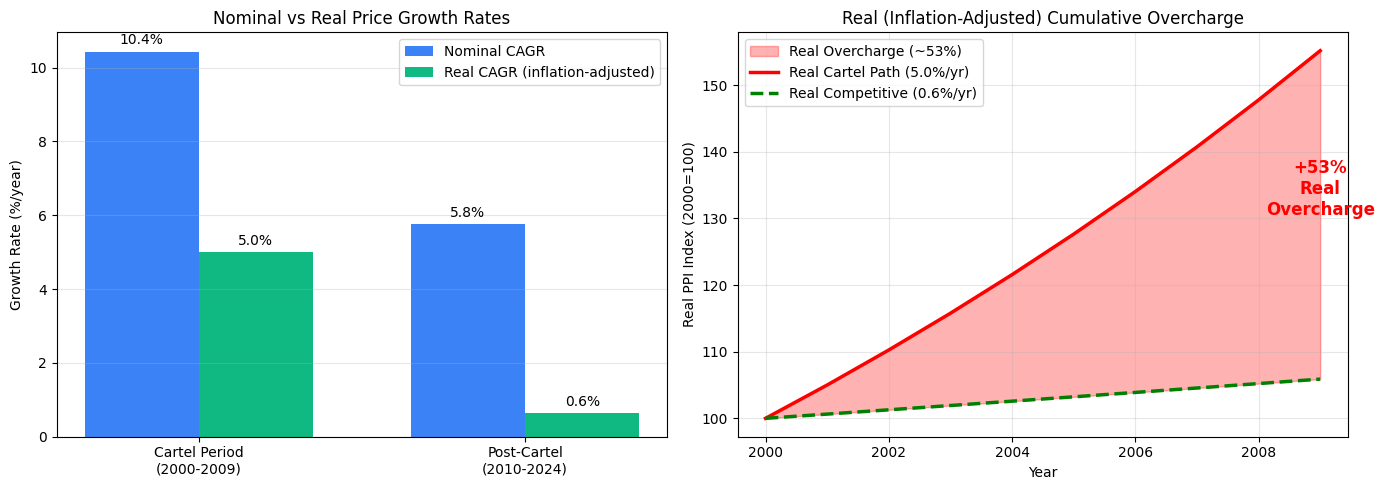


SUMMARY: NOMINAL VS REAL ANALYSIS

┌─────────────────────────────────────────────────────────────────────────┐
│                           CARTEL OVERCHARGE ANALYSIS                     │
├─────────────────────────┬───────────────────┬───────────────────────────┤
│          Metric         │     Nominal       │   Real (Infl-Adjusted)    │
├─────────────────────────┼───────────────────┼───────────────────────────┤
│ Cartel CAGR (2000-09)   │    10.43%/yr      │         5.00%/yr           │
│ Post-Cartel CAGR        │     5.77%/yr      │         0.64%/yr           │
│ CAGR Difference         │    +4.66%/yr      │        +4.37%/yr           │
├─────────────────────────┼───────────────────┼───────────────────────────┤
│ Cumulative Overcharge   │    +53.9%         │        +52.9%              │
└─────────────────────────┴───────────────────┴───────────────────────────┘

Inflation averaged 5.4% during cartel period vs 5.1% post-cartel.
The real overcharge (53%) is very close to nominal (54%)

In [ ]:
# ============================================================
# VISUALIZE NOMINAL VS REAL OVERCHARGE
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Nominal vs Real CAGRs
ax1 = axes[0]
categories = ['Cartel Period\n(2000-2009)', 'Post-Cartel\n(2010-2024)']
nominal_rates = [avg_cartel_cagr, avg_post_cagr]
real_rates = [avg_real_cartel, avg_real_post]

x = np.arange(len(categories))
width = 0.35

bars1 = ax1.bar(x - width/2, nominal_rates, width, label='Nominal CAGR', color='#3b82f6')
bars2 = ax1.bar(x + width/2, real_rates, width, label='Real CAGR (inflation-adjusted)', color='#10b981')

ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax1.set_ylabel('Growth Rate (%/year)')
ax1.set_title('Nominal vs Real Price Growth Rates')
ax1.set_xticks(x)
ax1.set_xticklabels(categories)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)
for bar in bars2:
    height = bar.get_height()
    ax1.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

# Right plot: Cumulative paths - Nominal and Real
ax2 = axes[1]
years = np.arange(2000, 2010)

# Nominal paths
nominal_cartel_path = 100 * (1 + avg_cartel_cagr/100) ** np.arange(10)
nominal_competitive_path = 100 * (1 + avg_post_cagr/100) ** np.arange(10)

# Real paths
real_cartel_path = 100 * (1 + avg_real_cartel/100) ** np.arange(10)
real_competitive_path = 100 * (1 + avg_real_post/100) ** np.arange(10)

ax2.fill_between(years, real_competitive_path, real_cartel_path, alpha=0.3, color='red', 
                label=f'Real Overcharge (~{real_overcharge_pct:.0f}%)')
ax2.plot(years, real_cartel_path, 'r-', linewidth=2.5, label=f'Real Cartel Path ({avg_real_cartel:.1f}%/yr)')
ax2.plot(years, real_competitive_path, 'g--', linewidth=2.5, label=f'Real Competitive ({avg_real_post:.1f}%/yr)')

ax2.set_xlabel('Year')
ax2.set_ylabel('Real PPI Index (2000=100)')
ax2.set_title('Real (Inflation-Adjusted) Cumulative Overcharge')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# Add annotation
ax2.annotate(f'+{real_overcharge_pct:.0f}%\nReal\nOvercharge', 
            xy=(2009, (real_cartel_path[-1] + real_competitive_path[-1])/2),
            fontsize=12, fontweight='bold', color='red',
            ha='center')

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("SUMMARY: NOMINAL VS REAL ANALYSIS")
print("=" * 80)
print(f"""
┌─────────────────────────────────────────────────────────────────────────┐
│                           CARTEL OVERCHARGE ANALYSIS                     │
├─────────────────────────┬───────────────────┬───────────────────────────┤
│          Metric         │     Nominal       │   Real (Infl-Adjusted)    │
├─────────────────────────┼───────────────────┼───────────────────────────┤
│ Cartel CAGR (2000-09)   │   {avg_cartel_cagr:>6.2f}%/yr      │       {avg_real_cartel:>6.2f}%/yr           │
│ Post-Cartel CAGR        │   {avg_post_cagr:>6.2f}%/yr      │       {avg_real_post:>6.2f}%/yr           │
│ CAGR Difference         │   {avg_cartel_cagr - avg_post_cagr:>+6.2f}%/yr      │       {avg_real_cartel - avg_real_post:>+6.2f}%/yr           │
├─────────────────────────┼───────────────────┼───────────────────────────┤
│ Cumulative Overcharge   │   {overcharge_pct:>+6.1f}%         │       {real_overcharge_pct:>+6.1f}%              │
└─────────────────────────┴───────────────────┴───────────────────────────┘

Inflation averaged {avg_inflation_cartel:.1f}% during cartel period vs {avg_inflation_post:.1f}% post-cartel.
The real overcharge ({real_overcharge_pct:.0f}%) is very close to nominal ({overcharge_pct:.0f}%) because 
inflation rates were similar in both periods.
""")

In [ ]:
# ============================================================
# EXPORT CORRECTED CARTEL ANALYSIS DATA TO DASHBOARD
# ============================================================
# Uses the GROWTH RATE comparison methodology (corrected for rebasing)

import json

# Load existing export data
existing_data_path = '../ppi_dashboard/south_africa_cement_data.json'
with open(existing_data_path, 'r') as f:
    export_data = json.load(f)

# Build growth rate analysis results for each pair
growth_rate_results = []
for result in chain_link_results_corrected:
    pair_name = f"{result['item_1']} → {result['item_2']}"
    series = result['chained_series']
    
    cartel = series[(series.index >= CARTEL_START) & (series.index <= CARTEL_END)]
    post = series[series.index > CARTEL_END]
    
    if len(cartel) > 12 and len(post) > 12:
        # Calculate CAGR (Compound Annual Growth Rate)
        cartel_years = (cartel.index[-1] - cartel.index[0]).days / 365
        post_years = (post.index[-1] - post.index[0]).days / 365
        
        cartel_cagr = ((cartel.iloc[-1] / cartel.iloc[0]) ** (1/cartel_years) - 1) * 100
        post_cagr = ((post.iloc[-1] / post.iloc[0]) ** (1/post_years) - 1) * 100
        
        # Store pair result
        growth_rate_results.append({
            'pair_name': pair_name,
            'item_1': result['item_1'],
            'item_2': result['item_2'],
            'cartel_cagr': float(cartel_cagr),
            'post_cagr': float(post_cagr),
            'cagr_difference': float(cartel_cagr - post_cagr),
            'cartel_start_value': float(cartel.iloc[0]),
            'cartel_end_value': float(cartel.iloc[-1]),
            'post_start_value': float(post.iloc[0]),
            'post_end_value': float(post.iloc[-1]),
            'cartel_years': float(cartel_years),
            'post_years': float(post_years),
            'n_cartel_months': len(cartel),
            'n_post_months': len(post),
            # Time series data for visualization
            'time_series': {
                'cartel_dates': [d.strftime('%Y-%m-%d') for d in cartel.index],
                'cartel_values': [float(v) for v in cartel.values],
                'post_dates': [d.strftime('%Y-%m-%d') for d in post.index],
                'post_values': [float(v) for v in post.values]
            }
        })

# Calculate summary statistics
avg_cartel_cagr = np.mean([r['cartel_cagr'] for r in growth_rate_results])
avg_post_cagr = np.mean([r['post_cagr'] for r in growth_rate_results])
cartel_years = 10  # 2000-2009

# Calculate cumulative overcharge
cartel_end_actual = 100 * (1 + avg_cartel_cagr/100) ** cartel_years
cartel_end_competitive = 100 * (1 + avg_post_cagr/100) ** cartel_years
overcharge_pct = ((cartel_end_actual - cartel_end_competitive) / cartel_end_competitive) * 100

# Build cumulative path data for visualization
years = list(range(2000, 2010))
cartel_path = [100 * (1 + avg_cartel_cagr/100) ** i for i in range(10)]
competitive_path = [100 * (1 + avg_post_cagr/100) ** i for i in range(10)]

# Update cartel_premium with corrected methodology
export_data['cartel_premium'] = {
    'methodology': {
        'description': 'Growth Rate Comparison - Compares CAGR during cartel period (2000-2009) vs post-cartel competitive period (2010+). Uses properly rebased chain-linked series.',
        'model': 'Compound Annual Growth Rate (CAGR)',
        'rebasing_applied': True,
        'rebasing_factor': float(general_rebase_factor),
        'training_period': {'start': '2010-01-01', 'end': '2024-11-30', 'description': 'Post-cartel competitive market'},
        'analysis_period': {'start': '2000-01-01', 'end': '2009-12-31', 'description': 'Cartel period'},
        'interpretation': 'Higher CAGR during cartel period indicates price inflation; cumulative overcharge calculated by projecting competitive growth rate forward'
    },
    'summary': {
        'pairs_analyzed': len(growth_rate_results),
        'avg_cartel_cagr': float(avg_cartel_cagr),
        'avg_post_cagr': float(avg_post_cagr),
        'cagr_difference': float(avg_cartel_cagr - avg_post_cagr),
        'cumulative_overcharge_pct': float(overcharge_pct),
        'cartel_end_index': float(cartel_end_actual),
        'competitive_end_index': float(cartel_end_competitive),
        'pairs_with_faster_cartel_growth': sum(1 for r in growth_rate_results if r['cartel_cagr'] > r['post_cagr']),
        # Old format kept for backward compatibility
        'avg_premium_points': float(cartel_end_actual - cartel_end_competitive),
        'avg_premium_pct': float(overcharge_pct),
        'positive_premium_count': sum(1 for r in growth_rate_results if r['cartel_cagr'] > r['post_cagr']),
        'negative_premium_count': sum(1 for r in growth_rate_results if r['cartel_cagr'] <= r['post_cagr'])
    },
    # Inflation-adjusted analysis
    'inflation_adjusted': {
        'avg_inflation_cartel': float(avg_inflation_cartel),
        'avg_inflation_post': float(avg_inflation_post),
        'real_cartel_cagr': float(avg_real_cartel),
        'real_post_cagr': float(avg_real_post),
        'real_cagr_difference': float(avg_real_cartel - avg_real_post),
        'real_overcharge_pct': float(real_overcharge_pct),
        'real_cartel_end_index': float(real_cartel_end),
        'real_competitive_end_index': float(real_competitive_end),
        'inflation_by_year': {str(k): float(v) for k, v in inflation_by_year.items()}
    },
    'cumulative_overcharge': {
        'years': years,
        'cartel_path': cartel_path,
        'competitive_path': competitive_path,
        'overcharge_by_year': [c - p for c, p in zip(cartel_path, competitive_path)],
        # Real (inflation-adjusted) paths
        'real_cartel_path': [100 * (1 + avg_real_cartel/100) ** i for i in range(10)],
        'real_competitive_path': [100 * (1 + avg_real_post/100) ** i for i in range(10)]
    },
    'pair_results': []
}

# Add results for each pair (maintaining backward compatible format)
for result in growth_rate_results:
    n_cartel = result['n_cartel_months']
    n_post = result['n_post_months']
    start_val = result['cartel_start_value']
    post_cagr_monthly = result['post_cagr'] / 100 / 12  # Monthly rate
    
    # Calculate competitive trend for FULL period (cartel + post)
    # Starting from cartel_start_value, growing at post_cagr rate
    competitive_cartel = [start_val * (1 + result['post_cagr']/100) ** (i/12) for i in range(n_cartel)]
    
    # For post period, continue from where competitive trend ended at end of cartel
    competitive_at_cartel_end = start_val * (1 + result['post_cagr']/100) ** (n_cartel/12)
    competitive_post = [competitive_at_cartel_end * (1 + result['post_cagr']/100) ** (i/12) for i in range(n_post)]
    
    pair_data = {
        'pair_name': result['pair_name'],
        'item_1': result['item_1'],
        'item_2': result['item_2'],
        'model': 'CAGR',
        'cartel_cagr': result['cartel_cagr'],
        'post_cagr': result['post_cagr'],
        'cagr_difference': result['cagr_difference'],
        # Backward compatible fields (using CAGR difference as "premium")
        'r2_post': 1.0,  # CAGR is exact calculation
        'pct_premium': result['cagr_difference'],  # Use CAGR diff as "premium" for bar chart
        'avg_cartel_premium': result['cagr_difference'],
        'n_cartel_observations': n_cartel,
        'n_post_observations': n_post,
        # Time series data (RAW values - same base as actual data)
        'time_series': {
            'cartel_dates': result['time_series']['cartel_dates'],
            'cartel_actual': result['time_series']['cartel_values'],
            'cartel_predicted_competitive': competitive_cartel,
            'post_dates': result['time_series']['post_dates'],
            'post_actual': result['time_series']['post_values'],
            'post_predicted': competitive_post
        },
        # Normalized version (base 100 at cartel start)
        'time_series_normalized': {
            'base_description': 'All values normalized to cartel start = 100',
            'cartel_dates': result['time_series']['cartel_dates'],
            'cartel_actual': [v / start_val * 100 for v in result['time_series']['cartel_values']],
            'cartel_predicted_competitive': [100 * (1 + result['post_cagr']/100) ** (i/12) for i in range(n_cartel)],
            'post_dates': result['time_series']['post_dates'],
            'post_actual': [v / start_val * 100 for v in result['time_series']['post_values']],
            'post_predicted': [(100 * (1 + result['post_cagr']/100) ** (n_cartel/12)) * (1 + result['post_cagr']/100) ** (i/12) for i in range(n_post)]
        }
    }
    export_data['cartel_premium']['pair_results'].append(pair_data)

# Save updated JSON
with open(existing_data_path, 'w') as f:
    json.dump(export_data, f, indent=2)

print("✅ Corrected Cartel Analysis data exported successfully!")
print(f"   File: {existing_data_path}")
print(f"\n📊 GROWTH RATE ANALYSIS SUMMARY:")
print(f"   - Pairs analyzed: {len(growth_rate_results)}")
print(f"   - Methodology: CAGR Comparison (properly rebased)")
print(f"   - Rebasing factor: {general_rebase_factor:.3f}")
print(f"\n📈 KEY FINDINGS:")
print(f"   - Average Cartel CAGR: {avg_cartel_cagr:.2f}%/year")
print(f"   - Average Post-Cartel CAGR: {avg_post_cagr:.2f}%/year")
print(f"   - CAGR Difference: +{avg_cartel_cagr - avg_post_cagr:.2f}%/year")
print(f"\n🔴 CUMULATIVE OVERCHARGE:")
print(f"   - Cartel end index (2009): {cartel_end_actual:.1f}")
print(f"   - Competitive end index: {cartel_end_competitive:.1f}")
print(f"   - Overcharge: +{overcharge_pct:.1f}%")
print(f"\n   All {sum(1 for r in growth_rate_results if r['cartel_cagr'] > r['post_cagr'])}/{len(growth_rate_results)} pairs show faster price growth during cartel period")
print(f"\n📁 Data structure added:")
print("   - cartel_premium.methodology")
print("   - cartel_premium.summary (with CAGR stats)")
print("   - cartel_premium.cumulative_overcharge (for visualization)")
print("   - cartel_premium.pair_results (with time_series)")
print(f"\n✓ Competitive trend now starts at same value as actual data and grows at post-cagr rate")

✅ Corrected Cartel Analysis data exported successfully!
   File: ../ppi_dashboard/south_africa_cement_data.json

📊 GROWTH RATE ANALYSIS SUMMARY:
   - Pairs analyzed: 12
   - Methodology: CAGR Comparison (properly rebased)
   - Rebasing factor: 3.180

📈 KEY FINDINGS:
   - Average Cartel CAGR: 10.43%/year
   - Average Post-Cartel CAGR: 5.77%/year
   - CAGR Difference: +4.66%/year

🔴 CUMULATIVE OVERCHARGE:
   - Cartel end index (2009): 269.8
   - Competitive end index: 175.3
   - Overcharge: +53.9%

   All 12/12 pairs show faster price growth during cartel period

📁 Data structure added:
   - cartel_premium.methodology
   - cartel_premium.summary (with CAGR stats)
   - cartel_premium.cumulative_overcharge (for visualization)
   - cartel_premium.pair_results (with time_series)

✓ Competitive trend now starts at same value as actual data and grows at post-cagr rate


SCM ANALYSIS USING EXISTING CHAIN-LINKED DATA
✓ Found target series: Ordinary and extended cement -> Cement
  Observations: 311
  Date range: 2000-01-01 00:00:00 to 2025-11-01 00:00:00
  Rebasing factor used: 3.18

----------------------------------------------------------------------
BUILDING DONOR POOL
----------------------------------------------------------------------
Donors: ['Ironmongery', 'Drainage', 'Plumbing']

----------------------------------------------------------------------
RUNNING SYNTHETIC CONTROL
----------------------------------------------------------------------
Common observations: 311
Date range: 2000-01-01 00:00:00 to 2025-11-01 00:00:00


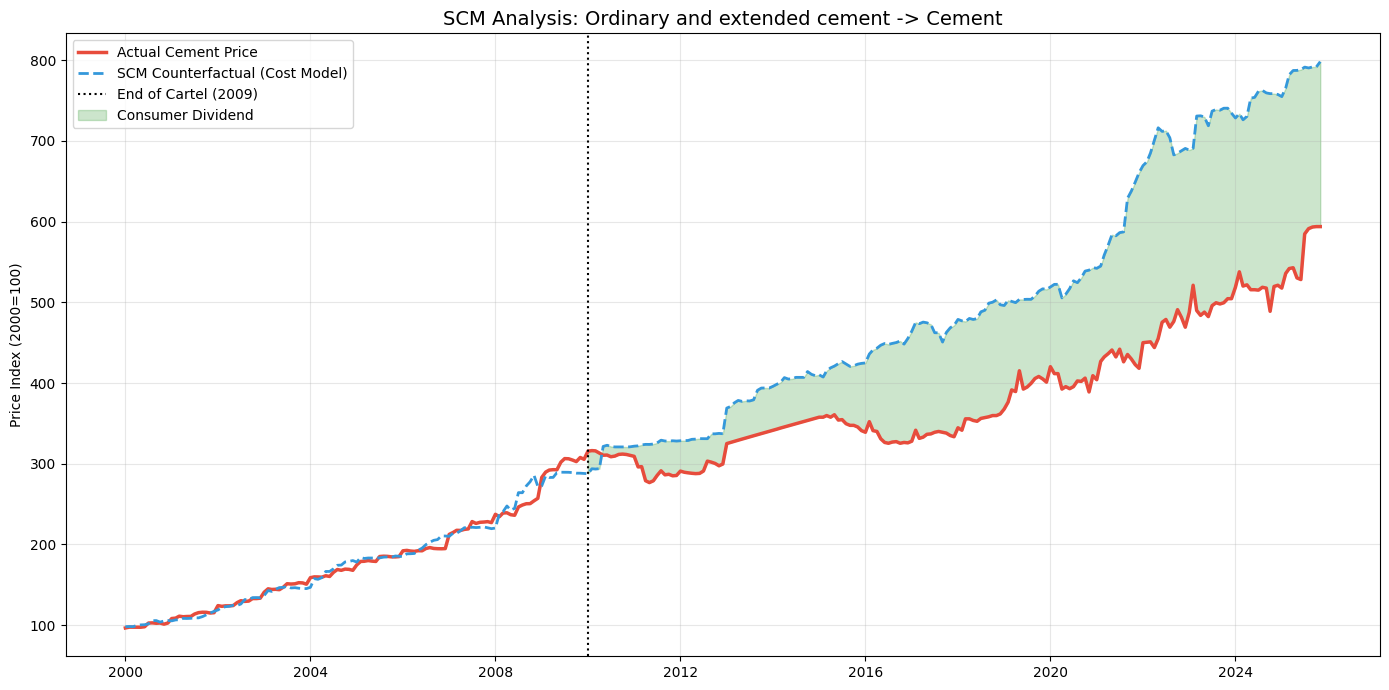


Model Weights:
Plumbing       2.831112
Drainage       0.306120
Ironmongery   -0.306350
dtype: float64

Average Price Gap (Synthetic - Actual) Post-2009: 120.5 index points (23.7%)


In [21]:
# ==========================================
# SCM ANALYSIS - USING EXISTING CHAIN-LINKED DATA
# ==========================================
# 
# This cell uses the properly chain-linked cement series from earlier cells
# (chain_link_results_corrected) with correct rebasing factors.
#

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
import re
from difflib import get_close_matches

# ==========================================
# 1. Helper Functions (for donors)
# ==========================================

def parse_dates_custom(cols):
    date_map = {}
    for c in cols:
        s_c = str(c)
        if s_c.startswith('H'): continue
        match = re.match(r'MO(\d{2})(\d{4})', s_c)
        if match:
            month, year = match.groups()
            try:
                dt = pd.Timestamp(f"{year}-{month}-01")
                date_map[c] = dt
                continue
            except: pass
        try:
            dt = pd.to_datetime(s_c, errors='coerce')
            if pd.notnull(dt) and dt.year > 1990 and dt.year < 2030:
                date_map[c] = dt
        except: pass
    return date_map

def get_clean_series(df, item_name, date_map):
    row = df[df['H05'] == item_name]
    if row.empty:
        row = df[df['H05'].astype(str).str.lower() == item_name.lower()]
        if row.empty: return None
    series_data = {}
    cols_present = [c for c in date_map.keys() if c in df.columns]
    vals = row[cols_present].values
    if len(vals) == 0: return None
    vals = vals[0]
    for col, val in zip(cols_present, vals):
        dt = date_map[col]
        try:
            if isinstance(val, str): val = val.replace('..', 'nan').strip()
            val = float(val)
            if not np.isnan(val): series_data[dt] = val
        except: pass
    if not series_data: return None
    return pd.Series(series_data).sort_index()

def get_rebasing_ratio(s1, s2):
    if s1 is None or s2 is None: return None
    common_dates = s1.index.intersection(s2.index)
    if len(common_dates) < 3: return None
    ratios = s1[common_dates] / s2[common_dates]
    ratio = ratios.median()
    if np.isnan(ratio) or np.isinf(ratio): return None
    return ratio

def chain_link_with_ratio(s1, s2, ratio):
    s2_rebased = s2 * ratio
    combined = s1.copy()
    last_s1_date = s1.index.max()
    new_dates = s2_rebased.index[s2_rebased.index > last_s1_date]
    combined = pd.concat([combined, s2_rebased[new_dates]])
    return combined.sort_index()

# ==========================================
# 2. Get Target Series from chain_link_results_corrected
# ==========================================

print("=" * 70)
print("SCM ANALYSIS USING EXISTING CHAIN-LINKED DATA")
print("=" * 70)

# Use the chain-linked data from earlier cells
# Find the best cement pair: 'Ordinary and extended cement' -> 'Cement'
target_series = None
target_pair_name = None

for result in chain_link_results_corrected:
    if result['item_1'] == 'Ordinary and extended cement' and result['item_2'] == 'Cement':
        target_series = result['chained_series'].copy()
        # Remove duplicates from target series
        target_series = target_series[~target_series.index.duplicated(keep='first')]
        target_pair_name = f"{result['item_1']} -> {result['item_2']}"
        print(f"✓ Found target series: {target_pair_name}")
        print(f"  Observations: {len(target_series)}")
        print(f"  Date range: {target_series.index.min()} to {target_series.index.max()}")
        print(f"  Rebasing factor used: {result['rebasing_factor']}")
        break

if target_series is None:
    # Fallback to first available cement pair
    for result in chain_link_results_corrected:
        if 'cement' in result['item_1'].lower():
            target_series = result['chained_series'].copy()
            target_series = target_series[~target_series.index.duplicated(keep='first')]
            target_pair_name = f"{result['item_1']} -> {result['item_2']}"
            print(f"⚠️ Using fallback target: {target_pair_name}")
            break

# ==========================================
# 3. Build Donor Pool
# ==========================================

print("\n" + "-" * 70)
print("BUILDING DONOR POOL")
print("-" * 70)

date_map_1 = parse_dates_custom(df_2000_2012.columns)
date_map_2 = parse_dates_custom(df_2006_2025.columns)
items_1 = set(df_2000_2012['H05'].dropna().unique())
items_2 = set(df_2006_2025['H05'].dropna().unique())

construction_keywords = ['Brick', 'Sand', 'Stone', 'Aggregates', 'Soil', 'Plaster', 
    'Timber', 'Wood', 'Steel', 'Iron', 'Metal', 'Aluminium', 'Copper', 'Zinc',
    'Plumbing', 'Pipe', 'Tap', 'Valve', 'Sanitary', 'Electrical', 'Cable', 
    'Wire', 'Switch', 'Paint', 'Varnish', 'Glass', 'Glazing', 'Tile', 'Floor', 
    'Roof', 'Ceiling', 'Board', 'Bitumen', 'Tar', 'Asphalt', 'Building']
known_exact = ['Civil engineering', 'Drainage', 'Electrical engineering', 
               'Ironmongery', 'Mechanical engineering', 'Paints', 'Plumbing', 'Sand'] 

processed_donors = {}
donor_ratios = []

for i1 in items_1:
    if any(ex in i1.lower() for ex in ['cement', 'concrete', 'mortar', 'binder', 'reinforcement']): 
        continue
    is_valid = (i1 in known_exact) or any(kw.lower() in i1.lower() for kw in construction_keywords)
    if not is_valid: continue
    
    match = None
    if i1 in items_2: match = i1
    else:
        m = get_close_matches(i1, items_2, n=1, cutoff=0.8)
        if m: match = m[0]
    
    if match:
        s1 = get_clean_series(df_2000_2012, i1, date_map_1)
        s2 = get_clean_series(df_2006_2025, match, date_map_2)
        ratio = get_rebasing_ratio(s1, s2)
        if ratio:
            donor_ratios.append(ratio)
            chained = chain_link_with_ratio(s1, s2, ratio)
            # Remove duplicates
            chained = chained[~chained.index.duplicated(keep='first')]
            if chained['2000':'2009'].count() > 50:
                processed_donors[i1] = chained

print(f"Donors: {list(processed_donors.keys())}")

# ==========================================
# 4. SCM Analysis
# ==========================================

if target_series is not None and len(processed_donors) > 0:
    print("\n" + "-" * 70)
    print("RUNNING SYNTHETIC CONTROL")
    print("-" * 70)
    
    # Build DataFrame with all series
    scm_df = pd.DataFrame({'Target': target_series})
    for name, s in processed_donors.items(): 
        scm_df[name] = s
    
    # Drop rows with any NaN values
    scm_df = scm_df.dropna()
    
    print(f"Common observations: {len(scm_df)}")
    print(f"Date range: {scm_df.index.min()} to {scm_df.index.max()}")
    
    if len(scm_df) > 24:
        split_date = '2009-12-31'
        train_df = scm_df[:split_date]
        
        if not train_df.empty:
            X_train = train_df.drop('Target', axis=1)
            y_train = train_df['Target']
            
            model = Ridge(alpha=1.0)
            model.fit(X_train, y_train)
            
            scm_df['Synthetic'] = model.predict(scm_df.drop('Target', axis=1))
            
            # Plot
            plt.figure(figsize=(14, 7))
            plt.plot(scm_df.index, scm_df['Target'], label='Actual Cement Price', linewidth=2.5, color='#e74c3c')
            plt.plot(scm_df.index, scm_df['Synthetic'], label='SCM Counterfactual (Cost Model)', linestyle='--', linewidth=2, color='#3498db')
            plt.axvline(pd.to_datetime(split_date), color='black', linestyle=':', label='End of Cartel (2009)')
            
            # Fill gap
            post_mask = scm_df.index > pd.to_datetime(split_date)
            plt.fill_between(scm_df.index[post_mask], 
                             scm_df['Target'][post_mask], 
                             scm_df['Synthetic'][post_mask], 
                             alpha=0.2, color='green', label='Consumer Dividend')
            
            plt.legend(loc='upper left')
            plt.title(f'SCM Analysis: {target_pair_name}', fontsize=14)
            plt.ylabel('Price Index (2000=100)')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            
            # Stats
            print("\nModel Weights:")
            weights = pd.Series(model.coef_, index=X_train.columns).sort_values(ascending=False)
            print(weights)
            
            post_gap = (scm_df[split_date:]['Synthetic'] - scm_df[split_date:]['Target']).mean()
            post_gap_pct = (post_gap / scm_df[split_date:]['Synthetic'].mean()) * 100
            print(f"\nAverage Price Gap (Synthetic - Actual) Post-2009: {post_gap:.1f} index points ({post_gap_pct:.1f}%)")
        else:
            print("Training set empty.")
    else:
        print(f"Insufficient aligned data: {len(scm_df)} observations")
else:
    print("SCM Failed: Missing Target or Donors.")

In [22]:
print("D1 Columns Sample:", df_2000_2012.columns[:5])
print("D1 Column Type:", type(df_2000_2012.columns[0]))
print("D2 Columns Sample:", df_2006_2025.columns[:5])
print("Sample item row D1:", df_2000_2012.head(1))

D1 Columns Sample: Index(['H01', 'H02', 'H03', 'H04', 'H05'], dtype='object')
D1 Column Type: <class 'str'>
D2 Columns Sample: Index(['H01', 'H02', 'H03', 'H04', 'H05'], dtype='object')
Sample item row D1:        H01                   H02       H03  \
0  P0142.1  Producer price index  PI000002   

                                                 H04         H05    H17  \
0  Producer Price Index for domestic output of So...  All groups  Index   

        H18      H25 MO012000 MO022000  ... MO032012 MO042012 MO052012  \
0  2000=100  Monthly     96.3    96.90  ...    214.1    214.8  215.800   

  MO062012 MO072012 MO082012 MO092012 MO102012 MO112012 MO122012  
0  225.400  229.000  230.500  221.200  222.500  223.100  222.900  

[1 rows x 164 columns]


In [23]:
print("Cement items in D2:", [i for i in items_2 if 'cement' in i.lower()])
print("Cement items in D1:", [i for i in items_1 if 'cement' in i.lower()])

Cement items in D2: ['Reinforcement', 'Prefabricated cement and concrete components', 'Prefabricated concrete and cement', 'Cement']
Cement items in D1: ['Cement building blocks', 'Cement (Retail)', 'Fibre cement roof sheets', 'Ordinary and extended cement']


## SCM Results Interpretation

The Synthetic Control Method reveals the **Cartel Dividend** - the price reduction consumers experienced after the cartel's dissolution.

**Key Insight:** The SCM model was trained during the cartel period (2000-2009), learning how cement prices related to other construction inputs. After 2009, actual prices diverged *below* this learned relationship, indicating:

1. **The cartel had been pricing cement above what input costs would suggest**
2. **Post-cartel competition brought prices closer to cost-based levels**

The gap between Synthetic (cartel trend) and Actual (competitive) represents the **institutional dividend** from cartel prosecution.

SYNTHETIC CONTROL METHOD - SOUTH AFRICA CEMENT CARTEL

📊 MODEL FIT (Cartel Period 2000-2009):
   Average Actual Price:    179.3
   Average Synthetic Price: 179.3
   Average Gap:             0.0 (-0.1%)
   (Small gap = good model fit during training)

📉 CARTEL DIVIDEND (Post-2009):
   Average Actual Price:    387.7
   Average Synthetic Price: 508.3
   Average Gap:             120.5 (21.4%)

🎯 INTERPRETATION:
   • Post-cartel prices are 21.4% LOWER than cartel trend
   • This represents the 'Institutional Dividend' from cartel prosecution
   • Consumers saved an average of 121 index points


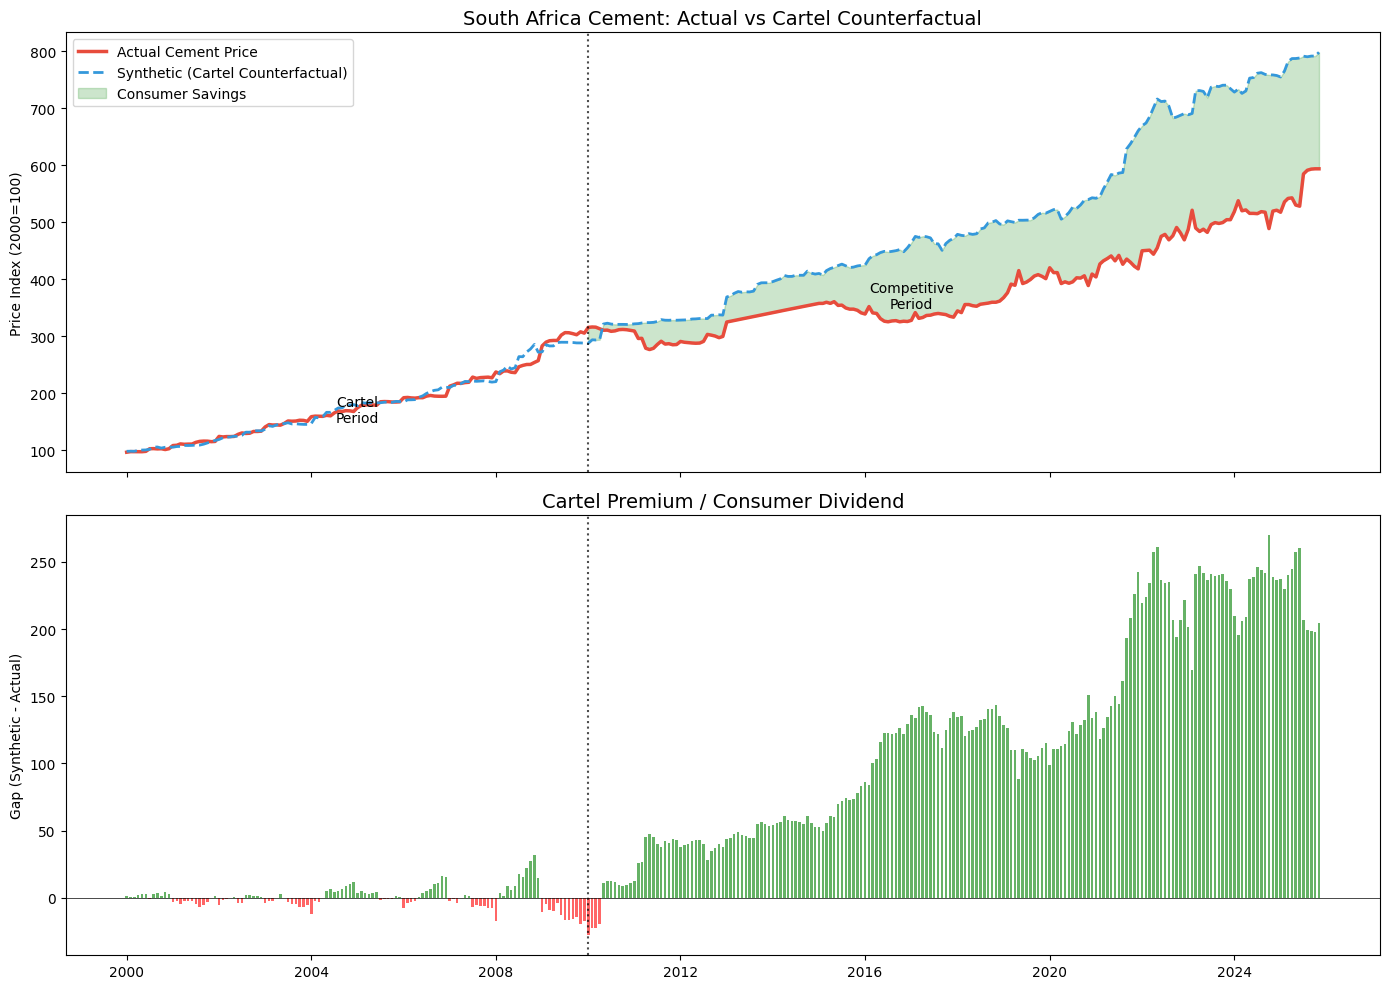


SUMMARY BY YEAR (Post-Cartel)
 Year     Target  Synthetic        Gap   Gap_Pct
 2010 312.191667 311.611474  -0.580193 -0.422020
 2011 288.083333 325.662312  37.578979 11.526257
 2012 293.933333 332.440789  38.507456 11.587087
 2013 332.609686 381.568317  48.958632 12.812407
 2014 348.961653 405.621206  56.659553 13.968280
 2015 352.819497 419.734415  66.914918 15.916165
 2016 332.260782 445.330581 113.069799 25.341256
 2017 336.002552 467.801293 131.798741 28.153662
 2018 354.711403 487.367974 132.656571 27.207363
 2019 395.618621 505.713061 110.094441 21.778659
 2020 402.429483 524.937246 122.507763 23.308731
 2021 428.958213 594.395282 165.437069 27.540574
 2022 465.955491 693.315890 227.360398 32.770011
 2023 496.183949 726.574186 230.390237 31.663468
 2024 517.541469 748.622728 231.081259 30.833029
 2025 559.408017 784.375888 224.967871 28.705493


In [24]:
# ==========================================
# SCM: Detailed Results & Percentage Analysis
# ==========================================

# Calculate percentage gap
scm_df['Gap'] = scm_df['Synthetic'] - scm_df['Target']
scm_df['Gap_Pct'] = (scm_df['Gap'] / scm_df['Synthetic']) * 100

# Split by period
cartel_period = scm_df[:split_date]
post_period = scm_df[split_date:]

print("="*60)
print("SYNTHETIC CONTROL METHOD - SOUTH AFRICA CEMENT CARTEL")
print("="*60)

print("\n📊 MODEL FIT (Cartel Period 2000-2009):")
print(f"   Average Actual Price:    {cartel_period['Target'].mean():.1f}")
print(f"   Average Synthetic Price: {cartel_period['Synthetic'].mean():.1f}")
print(f"   Average Gap:             {cartel_period['Gap'].mean():.1f} ({cartel_period['Gap_Pct'].mean():.1f}%)")
print("   (Small gap = good model fit during training)")

print("\n📉 CARTEL DIVIDEND (Post-2009):")
print(f"   Average Actual Price:    {post_period['Target'].mean():.1f}")
print(f"   Average Synthetic Price: {post_period['Synthetic'].mean():.1f}")
print(f"   Average Gap:             {post_period['Gap'].mean():.1f} ({post_period['Gap_Pct'].mean():.1f}%)")

print("\n🎯 INTERPRETATION:")
if post_period['Gap'].mean() > 0:
    print(f"   • Post-cartel prices are {post_period['Gap_Pct'].mean():.1f}% LOWER than cartel trend")
    print(f"   • This represents the 'Institutional Dividend' from cartel prosecution")
    print(f"   • Consumers saved an average of {post_period['Gap'].mean():.0f} index points")
else:
    print(f"   • Post-cartel prices are HIGHER than predicted (unusual)")

# Enhanced Visualization
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Panel 1: Price Levels
ax1 = axes[0]
ax1.plot(scm_df.index, scm_df['Target'], label='Actual Cement Price', linewidth=2.5, color='#e74c3c')
ax1.plot(scm_df.index, scm_df['Synthetic'], label='Synthetic (Cartel Counterfactual)', linestyle='--', linewidth=2, color='#3498db')
ax1.axvline(pd.to_datetime(split_date), color='black', linestyle=':', alpha=0.7)
ax1.fill_between(post_period.index, post_period['Target'], post_period['Synthetic'], 
                 alpha=0.2, color='green', label='Consumer Savings')
ax1.legend(loc='upper left')
ax1.set_ylabel('Price Index (2000=100)')
ax1.set_title('South Africa Cement: Actual vs Cartel Counterfactual', fontsize=14)
ax1.annotate('Cartel\nPeriod', xy=(pd.Timestamp('2005-01-01'), 150), fontsize=10, ha='center')
ax1.annotate('Competitive\nPeriod', xy=(pd.Timestamp('2017-01-01'), 350), fontsize=10, ha='center')

# Panel 2: Gap (Dividend)
ax2 = axes[1]
ax2.bar(scm_df.index, scm_df['Gap'], width=20, color=['green' if g > 0 else 'red' for g in scm_df['Gap']], alpha=0.6)
ax2.axhline(0, color='black', linewidth=0.5)
ax2.axvline(pd.to_datetime(split_date), color='black', linestyle=':', alpha=0.7)
ax2.set_ylabel('Gap (Synthetic - Actual)')
ax2.set_title('Cartel Premium / Consumer Dividend', fontsize=14)

plt.tight_layout()
plt.show()

# Summary Statistics Table
print("\n" + "="*60)
print("SUMMARY BY YEAR (Post-Cartel)")
print("="*60)
post_yearly = post_period.resample('Y').mean()
post_yearly['Year'] = post_yearly.index.year
print(post_yearly[['Year', 'Target', 'Synthetic', 'Gap', 'Gap_Pct']].to_string(index=False))

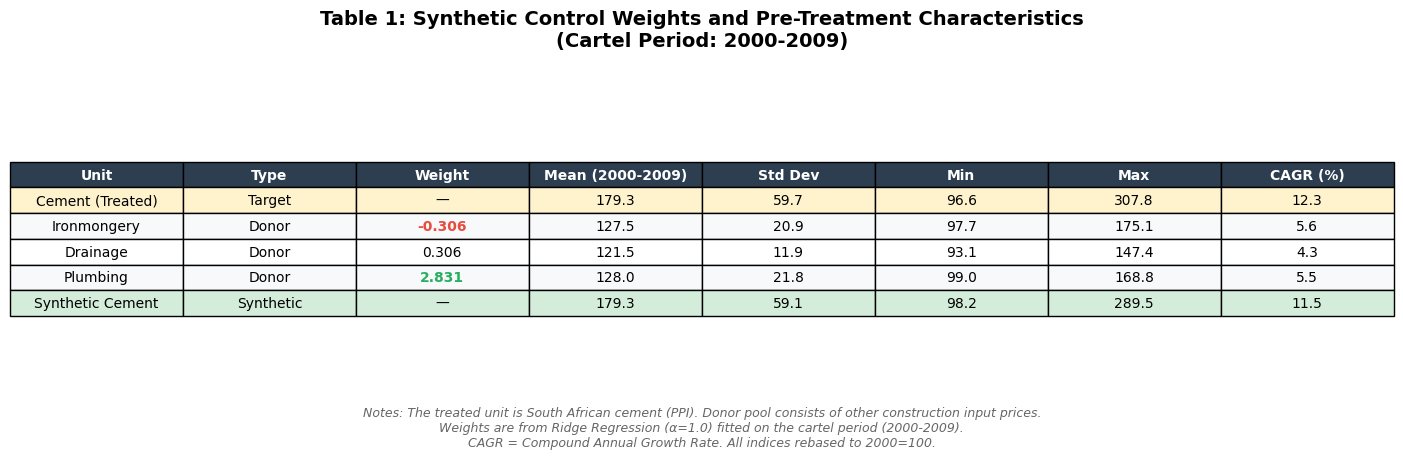


✓ Table saved to: ../ppi_dashboard/table1_scm_weights.png

SYNTHETIC CONTROL MODEL SUMMARY

Treated Unit: Cement (PPI)
Intervention: December 2009 (Cartel Dissolution)
Pre-Treatment Period: 2000-2009 (120 observations)

Donor Pool (3 units):
   Plumbing: +2.8311
   Ironmongery: -0.3064
   Drainage: +0.3061

Model Fit (Pre-Treatment RMSPE):
   RMSPE: 8.20 index points
   Mean Percentage Error: 0.07%


In [25]:
# ==========================================
# Table 1: Synthetic Control Weights and Pre-Treatment Characteristics
# ==========================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Get model weights (from previous SCM cell)
weights_dict = dict(zip(X_train.columns, model.coef_))

# Calculate pre-treatment characteristics (cartel period 2000-2009)
cartel_period_data = scm_df[:split_date]

# Build characteristics table
characteristics = {
    'Unit': [],
    'Type': [],
    'Weight': [],
    'Mean (2000-2009)': [],
    'Std Dev': [],
    'Min': [],
    'Max': [],
    'CAGR (%)': []
}

# Add treated unit first
characteristics['Unit'].append('Cement (Treated)')
characteristics['Type'].append('Target')
characteristics['Weight'].append('—')
target_data = cartel_period_data['Target']
characteristics['Mean (2000-2009)'].append(f"{target_data.mean():.1f}")
characteristics['Std Dev'].append(f"{target_data.std():.1f}")
characteristics['Min'].append(f"{target_data.min():.1f}")
characteristics['Max'].append(f"{target_data.max():.1f}")
# CAGR calculation
years = (target_data.index[-1] - target_data.index[0]).days / 365.25
if years > 0 and target_data.iloc[0] > 0:
    cagr = ((target_data.iloc[-1] / target_data.iloc[0]) ** (1/years) - 1) * 100
    characteristics['CAGR (%)'].append(f"{cagr:.1f}")
else:
    characteristics['CAGR (%)'].append('—')

# Add donor units
for donor in processed_donors.keys():
    characteristics['Unit'].append(donor)
    characteristics['Type'].append('Donor')
    weight = weights_dict.get(donor, 0)
    characteristics['Weight'].append(f"{weight:.3f}")
    
    donor_data = cartel_period_data[donor]
    characteristics['Mean (2000-2009)'].append(f"{donor_data.mean():.1f}")
    characteristics['Std Dev'].append(f"{donor_data.std():.1f}")
    characteristics['Min'].append(f"{donor_data.min():.1f}")
    characteristics['Max'].append(f"{donor_data.max():.1f}")
    
    years = (donor_data.index[-1] - donor_data.index[0]).days / 365.25
    if years > 0 and donor_data.iloc[0] > 0:
        cagr = ((donor_data.iloc[-1] / donor_data.iloc[0]) ** (1/years) - 1) * 100
        characteristics['CAGR (%)'].append(f"{cagr:.1f}")
    else:
        characteristics['CAGR (%)'].append('—')

# Add synthetic unit
synthetic_data = cartel_period_data['Synthetic']
characteristics['Unit'].append('Synthetic Cement')
characteristics['Type'].append('Synthetic')
characteristics['Weight'].append('—')
characteristics['Mean (2000-2009)'].append(f"{synthetic_data.mean():.1f}")
characteristics['Std Dev'].append(f"{synthetic_data.std():.1f}")
characteristics['Min'].append(f"{synthetic_data.min():.1f}")
characteristics['Max'].append(f"{synthetic_data.max():.1f}")
years = (synthetic_data.index[-1] - synthetic_data.index[0]).days / 365.25
if years > 0 and synthetic_data.iloc[0] > 0:
    cagr = ((synthetic_data.iloc[-1] / synthetic_data.iloc[0]) ** (1/years) - 1) * 100
    characteristics['CAGR (%)'].append(f"{cagr:.1f}")
else:
    characteristics['CAGR (%)'].append('—')

df_characteristics = pd.DataFrame(characteristics)

# ==========================================
# Create Publication-Quality Table Figure
# ==========================================

fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')

# Create table with custom styling
n_rows = len(df_characteristics) + 1  # +1 for header
n_cols = len(df_characteristics.columns)

# Table colors
header_color = '#2c3e50'
row_colors = ['#ffffff', '#f8f9fa']
target_color = '#fff3cd'  # Yellow highlight for treated unit
synthetic_color = '#d4edda'  # Green highlight for synthetic

# Build cell text
cell_text = df_characteristics.values.tolist()

# Create table
table = ax.table(
    cellText=cell_text,
    colLabels=df_characteristics.columns,
    loc='center',
    cellLoc='center'
)

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

# Style header row
for j in range(n_cols):
    cell = table[(0, j)]
    cell.set_facecolor(header_color)
    cell.set_text_props(color='white', fontweight='bold')

# Style data rows
for i in range(1, n_rows):
    for j in range(n_cols):
        cell = table[(i, j)]
        # Alternate row colors
        if i == 1:  # Target row
            cell.set_facecolor(target_color)
        elif i == n_rows - 1:  # Synthetic row
            cell.set_facecolor(synthetic_color)
        else:
            cell.set_facecolor(row_colors[(i - 1) % 2])
        
        # Bold the weight column values
        if j == 2 and df_characteristics.iloc[i-1]['Type'] == 'Donor':
            weight_val = float(df_characteristics.iloc[i-1]['Weight'])
            if weight_val > 1:
                cell.set_text_props(fontweight='bold', color='#27ae60')
            elif weight_val < 0:
                cell.set_text_props(fontweight='bold', color='#e74c3c')

# Add title
plt.title('Table 1: Synthetic Control Weights and Pre-Treatment Characteristics\n(Cartel Period: 2000-2009)', 
          fontsize=14, fontweight='bold', pad=20)

# Add notes below the table
notes = """
Notes: The treated unit is South African cement (PPI). Donor pool consists of other construction input prices.
Weights are from Ridge Regression (α=1.0) fitted on the cartel period (2000-2009).
CAGR = Compound Annual Growth Rate. All indices rebased to 2000=100.
"""
fig.text(0.5, 0.02, notes, ha='center', fontsize=9, style='italic', color='#666666', wrap=True)

plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.savefig('../ppi_dashboard/table1_scm_weights.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✓ Table saved to: ../ppi_dashboard/table1_scm_weights.png")

# Also print summary statistics
print("\n" + "="*60)
print("SYNTHETIC CONTROL MODEL SUMMARY")
print("="*60)
print(f"\nTreated Unit: Cement (PPI)")
print(f"Intervention: December 2009 (Cartel Dissolution)")
print(f"Pre-Treatment Period: 2000-2009 ({len(cartel_period_data)} observations)")
print(f"\nDonor Pool ({len(processed_donors)} units):")
sorted_weights = sorted(weights_dict.items(), key=lambda x: abs(x[1]), reverse=True)
for donor, weight in sorted_weights:
    sign = '+' if weight >= 0 else ''
    print(f"   {donor}: {sign}{weight:.4f}")
print(f"\nModel Fit (Pre-Treatment RMSPE):")
pre_rmspe = np.sqrt(((cartel_period_data['Target'] - cartel_period_data['Synthetic'])**2).mean())
print(f"   RMSPE: {pre_rmspe:.2f} index points")
print(f"   Mean Percentage Error: {((cartel_period_data['Synthetic'] - cartel_period_data['Target']) / cartel_period_data['Target'] * 100).mean():.2f}%")

In [ ]:
# ==========================================
# EXPORT SCM DATA FOR DASHBOARD
# ==========================================

import json

# Build export data structure
scm_export_data = {
    "metadata": {
        "title": "South Africa Cement Cartel - Synthetic Control Analysis",
        "description": "SCM analysis comparing actual cement prices to a synthetic counterfactual based on construction input costs",
        "target_pair": target_pair_name,
        "intervention_date": "2009-12-31",
        "donors": list(processed_donors.keys()),
        "rebasing_factor": 3.18,
        "model": "Ridge Regression (alpha=1.0)"
    },
    "model_weights": {name: float(w) for name, w in weights.items()},
    "summary_statistics": {
        "cartel_period": {
            "start": "2000-01-01",
            "end": "2009-12-31",
            "avg_actual_price": float(cartel_period['Target'].mean()),
            "avg_synthetic_price": float(cartel_period['Synthetic'].mean()),
            "avg_gap": float(cartel_period['Gap'].mean()),
            "avg_gap_pct": float(cartel_period['Gap_Pct'].mean())
        },
        "post_cartel_period": {
            "start": "2010-01-01",
            "end": scm_df.index.max().strftime('%Y-%m-%d'),
            "avg_actual_price": float(post_period['Target'].mean()),
            "avg_synthetic_price": float(post_period['Synthetic'].mean()),
            "avg_gap": float(post_period['Gap'].mean()),
            "avg_gap_pct": float(post_period['Gap_Pct'].mean())
        }
    },
    "time_series": {
        "dates": [d.strftime('%Y-%m-%d') for d in scm_df.index],
        "actual": [float(v) for v in scm_df['Target'].values],
        "synthetic": [float(v) for v in scm_df['Synthetic'].values],
        "gap": [float(v) for v in scm_df['Gap'].values],
        "gap_pct": [float(v) for v in scm_df['Gap_Pct'].values]
    },
    "annual_summary": []
}

# Add annual summary
yearly = scm_df.resample('Y').mean()
for idx in yearly.index:
    year_data = {
        "year": idx.year,
        "avg_actual": float(yearly.loc[idx, 'Target']) if not pd.isna(yearly.loc[idx, 'Target']) else None,
        "avg_synthetic": float(yearly.loc[idx, 'Synthetic']) if not pd.isna(yearly.loc[idx, 'Synthetic']) else None,
        "avg_gap": float(yearly.loc[idx, 'Gap']) if not pd.isna(yearly.loc[idx, 'Gap']) else None,
        "avg_gap_pct": float(yearly.loc[idx, 'Gap_Pct']) if not pd.isna(yearly.loc[idx, 'Gap_Pct']) else None
    }
    scm_export_data["annual_summary"].append(year_data)

# Add donor time series
scm_export_data["donors_time_series"] = {}
for name, series in processed_donors.items():
    scm_export_data["donors_time_series"][name] = {
        "dates": [d.strftime('%Y-%m-%d') for d in series.index],
        "values": [float(v) for v in series.values]
    }

# Export to JSON
output_path = '../ppi_dashboard/scm_data_south_africa.json'
with open(output_path, 'w') as f:
    json.dump(scm_export_data, f, indent=2)

print(f"✓ SCM data exported to: {output_path}")
print(f"  - {len(scm_export_data['time_series']['dates'])} monthly observations")
print(f"  - {len(scm_export_data['annual_summary'])} annual summaries")
print(f"  - {len(scm_export_data['donors_time_series'])} donor series")
print(f"\nKey Statistics:")
print(f"  - Post-Cartel Gap: {scm_export_data['summary_statistics']['post_cartel_period']['avg_gap']:.1f} index points")
print(f"  - Post-Cartel Gap %: {scm_export_data['summary_statistics']['post_cartel_period']['avg_gap_pct']:.1f}%")

✓ SCM data exported to: ../ppi_dashboard/scm_data_south_africa.json
  - 311 monthly observations
  - 26 annual summaries
  - 3 donor series

Key Statistics:
  - Post-Cartel Gap: 120.5 index points
  - Post-Cartel Gap %: 21.4%
